In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
from pathlib import Path

BASE_DIR = Path.cwd().parent  # notebooks klasöründen bir üst dizine çık
DB_PATH = BASE_DIR / "data" / "raw" / "data.db"

conn = sqlite3.connect(DB_PATH)
print("Bağlantı başarılı:", DB_PATH)

Bağlantı başarılı: c:\Users\gokce_aktas\Desktop\dsml-assessment\data\raw\data.db


In [2]:
df_hedef = pd.read_sql('SELECT * FROM hedef', conn)
print(df_hedef.head())
print(df_hedef.dtypes)

  öğrenci_id hedef_degisken
0          1    286,6960835
1          2    339,4194585
2          3    271,1636283
3          4    307,9972813
4          5    328,1582231
öğrenci_id        object
hedef_degisken    object
dtype: object


In [3]:
df_hedef['hedef_degisken'] = df_hedef['hedef_degisken'].str.replace(',', '.')
df_hedef['hedef_degisken'] = pd.to_numeric(df_hedef['hedef_degisken'], errors='coerce')
print(df_hedef['hedef_degisken'].dtype)
print(df_hedef['hedef_degisken'].isnull().sum())
print(df_hedef['hedef_degisken'].describe())

float64
0
count    1004.000000
mean      300.096222
std        64.791991
min       164.928302
25%       253.866472
50%       294.000266
75%       345.870669
max       484.239987
Name: hedef_degisken, dtype: float64


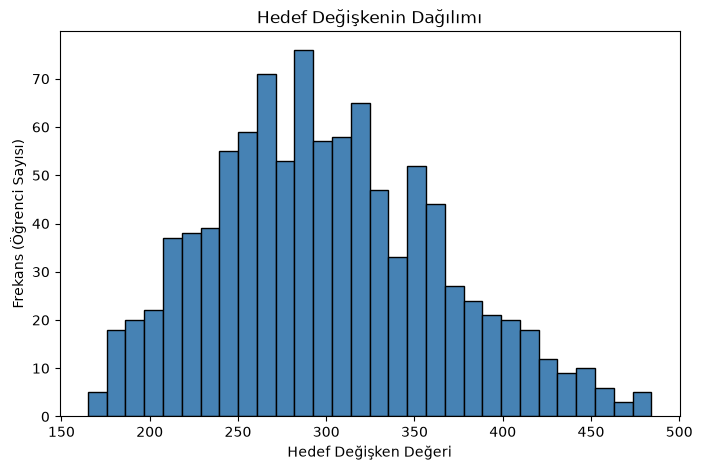

In [4]:
plt.figure(figsize=(8, 5))
plt.hist(df_hedef['hedef_degisken'], bins=30, color='steelblue', edgecolor='black')
plt.title("Hedef Değişkenin Dağılımı")
plt.xlabel("Hedef Değişken Değeri")
plt.ylabel("Frekans (Öğrenci Sayısı)")
plt.show()

Bunlar Hedef Değişken kolonlarımız.

**Peki Hedef Değişkeni ne anlama gelmekte?** Öğrencinin tahmin edilmesi istenen bir performans başarı skorudur.


In [5]:
from scipy.stats import shapiro
stat, p = shapiro(df_hedef['hedef_degisken'].dropna())
print(stat, p)

0.9859780694128174 3.192194690100213e-08


Bu test, hedef_degisken sütununun normal dağılıma uyup uymadığını ölçüyor.

**p-değeri Nedir?** P-değeri, istatistikte "gördüğüm bu sonucun, sadece tesadüfen ortaya çıkma olasılığı nedir?" sorusuna cevap veren bir sayı.

S**hapiro Testi Nedir?** Normal dağılıma uyup uymadığını sayısal olarak test eder.

Test, önce bir varsayım ile başlıyor:

- "Bu veri, normal dağılımdan geliyor."

- P-değeri şunu söylüyor:

- "Eğer bu varsayım gerçekten doğruysa, elimdeki veri kadar 'normalden sapmış' bir örneklem görme ihtimalim nedir?"

**Yorumlama Kuralı**

**p-değeri	Anlamı:**

- p > 0.05	Sapma şansla açıklanabilir veri normal dağılıma uygun diyebiliriz
- p ≤ 0.05	Sapma şansla açıklanamayacak kadar büyük  veri normal dağılıma uygun değil

**Sonuç:** p = 3.192194690100213e-08

Bu, 0.0000000319 demek yani 0.05'ten inanılmaz derecede küçük.

**Sonuç:** hedef_degisken sütunu, istatistiksel olarak normal dağılıma uymuyor.

**stat (Test İstatistiği / W Değeri) Nedir?** Bu, Shapiro testinde W olarak da bilinir. 0 ile 1 arasında bir değerdir. 1'e ne kadar yakınsa, verinin şekli normale o kadar benziyor demektir.

**Sonuç:** stat = 0.9859780694128174 değeri 1'e çok yakın yani veri görsel olarak normale oldukça benziyor.

**Amacımız,** hedef_degisken sütununun normal dağılıma uyup uymadığını sayısal/istatistiksel olarak kesin bir şekilde ölçmekti  yani sadece "gözle bakınca çan şekline benziyor" demek yerine, bunu test ederek kanıtlamaktı.

In [6]:
print(f"İstatistik: {stat}, p-değeri: {p}")

İstatistik: 0.9859780694128174, p-değeri: 3.192194690100213e-08


In [7]:
print(df_hedef['hedef_degisken'].skew())

0.35830563186446585


**Skewness (Çarpıklık) Nedir?** Skewness, bir verinin dağılımının simetrik olup olmadığını ve hangi yöne doğru "kaydığını" ölçen bir sayıdır.

In [8]:
print(df_hedef.columns.tolist())

['öğrenci_id', 'hedef_degisken']


Bu tablomda (df_hedef) hangi sütunlar var, isimleri söyler

In [9]:
%who DataFrame

df_hedef	 


Şu ana kadar oluşturduğum tabloların (DataFrame'lerin) hepsini listeler.

In [10]:
"""
Bu kodu kendi notebook'una (01_explore_data.ipynb) hücre hücre yapıştır ve çalıştır.
data.db yolunu kendi projenine göre ayarla (aşağıda DB_PATH).
"""
 
import sqlite3
import struct
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [11]:
# ============================================
# 1. VERİYİ OKU VE BİRLEŞTİR
# ============================================
DB_PATH = '../data/raw/data.db'
  # kendi yoluna göre düzenle
 
conn = sqlite3.connect(DB_PATH)
hedef = pd.read_sql('SELECT * FROM hedef', conn)
notlar = pd.read_sql('SELECT * FROM "not"', conn)   # "not" SQL anahtar kelimesi, tırnak şart
ogrenci = pd.read_sql('SELECT * FROM ogrenci', conn)
 
df = ogrenci.merge(notlar, on='öğrenci_id').merge(hedef, on='öğrenci_id')
print("Shape:", df.shape)
df.head()
 

Shape: (1004, 25)


,öğrenci_id,okula_basladigi_yil,dogum_yil,okul_tip,kiminle_kaliyor,il,"cinsiyet(kiz=1, erkek=0)",burslu,anne_baba_ayri,aile_geliri_seviyesi,...,ontest_skoru,kayit_sira_no,donem,turkce_not_ort,matematik_not_ort,fen_not_ort,sosyal_not_ort,y_dil_not_ort,din_not_ort,hedef_degisken
0,1,2015-2016,2005,Tip 1,Ailesiyle,1,1,0.0,0,2.0,...,247.67,28289,2025-Güz,72,84,"84,33333333",69,"52,66666667","67,5","286,6960835"
1,2,2014-2015,2004,Tip 2,Ailesiyle,1,0,0.0,0,2.0,...,287.40,23434,2024-Güz,80,"73,33333333","85,66666667","86,5",84,None,"339,4194585"
2,3,2014-2015,2004,Tip 2,Ailesiyle,0,0,0.0,0,2.0,...,235.67,98696,2025-Bahar,41,42,57,53,"30,66666667","77,5","271,1636283"
3,4,2014-2015,2004,Tip 1,Ailesiyle,1,1,0.0,0,1.0,...,273.98,81482,2025-Güz,"78,66666667","82,66666667","85,33333333",87,84,"87,5","307,9972813"
4,5,2015-2016,2005,Tip 2,Ailesiyle,1,0,0.0,0,2.0,...,277.06,21395,2024-Güz,82,39,79,87,87,96,"328,1582231"


In [12]:
# ==============================================================================
# 2. TEMİZLİK (Byte Hatası Düzeltme + Türkçe Virgüllü Sayı Formatı Dönüşümü)
# ==============================================================================
import struct
import numpy as np
import pandas as pd


def fix_bytes(v):
  """SQLite'tan gelen ham byte (b'\\x...') değerlerini int64 tam sayıya çevirir."""
  if isinstance(v, bytes):
    try:
      return struct.unpack('<q', v)[0]
    except Exception:
      return np.nan
  return v


def to_num_tr(v):
  """Byte veya Türkçe virgüllü string ('85,5') formatındaki sayıları float'a çevirir."""
  if isinstance(v, bytes):
    v = fix_bytes(v)

  if isinstance(v, str):
    v = v.replace(',', '.').strip()
    try:
      return float(v)
    except Exception:
      return np.nan
  return v


# 1. Byte hatası içeren sütunları temizleme ve int yapma
byte_cols = [
    'öğrenci_id',
    'dogum_yil',
    'il',
    'cinsiyet(kiz=1, erkek=0)',
    'anne_baba_ayri',
]
for c in byte_cols:
  if c in df.columns:
    df[c] = df[c].apply(fix_bytes).astype('Int64')

# 2. Virgüllü/metin haldeki sayısal sütunları ve ontest_skoru'nu float'a çevirme
num_str_cols = [
    'turkce_not_ort',
    'matematik_not_ort',
    'fen_not_ort',
    'sosyal_not_ort',
    'y_dil_not_ort',
    'din_not_ort',
    'ontest_skoru',
    'hedef_degisken',
]
for c in num_str_cols:
  if c in df.columns:
    df[c] = df[c].apply(to_num_tr)

# 3. Öğrenci ID sütununu standart int tipine sabitleme
if 'öğrenci_id' in df.columns:
  df['öğrenci_id'] = df['öğrenci_id'].astype(int)

# 4. Sonuç Kontrolü
print('Tip dönüşümleri tamamlandı.')
print('\nEksik Değer Özeti (Eksik olan kolonlar):')
missing_summary = df.isna().sum()[df.isna().sum() > 0]
print(
    missing_summary
    if not missing_summary.empty
    else 'Hiç eksik değer bulunmuyor.'
)

Tip dönüşümleri tamamlandı.

Eksik Değer Özeti (Eksik olan kolonlar):
burslu                   8
aile_geliri_seviyesi    68
kardes(var/yok)         20
anne_egitim_seviyesi    53
baba_egitim_seviyesi    52
anne_meslek(var/yok)    51
baba_meslek(var/yok)    50
ontest_skoru             5
turkce_not_ort           1
matematik_not_ort        1
fen_not_ort              1
sosyal_not_ort           1
y_dil_not_ort            2
din_not_ort              2
dtype: int64


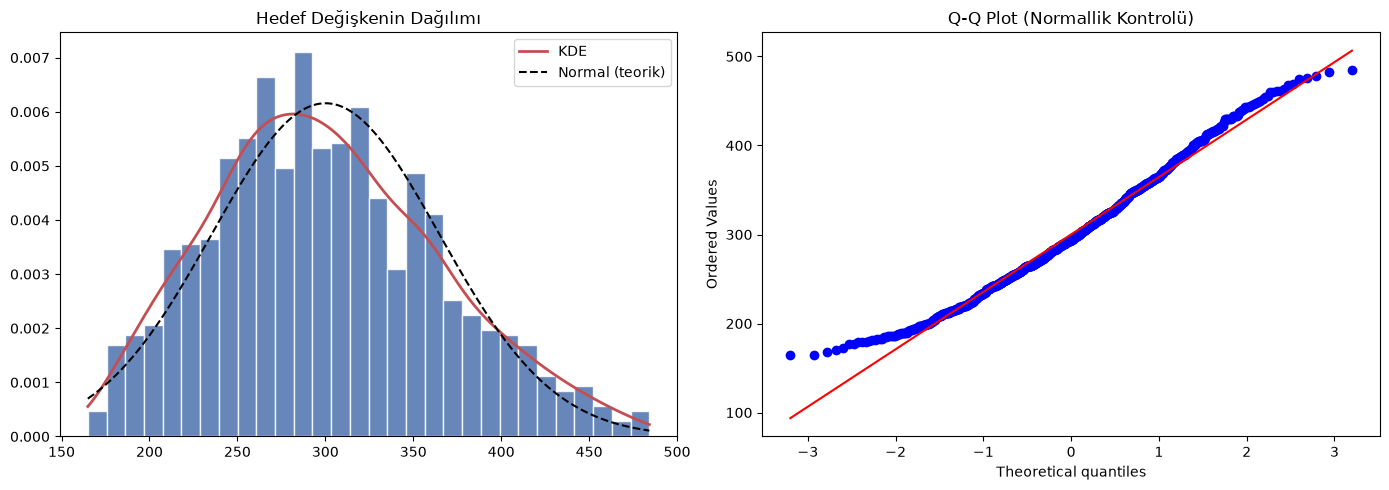

Çarpıklık: 0.3578 | Shapiro-Wilk p-value: 0.000000


In [13]:
# ============================================
# 3. GRAFİK 1: HEDEF DEĞİŞKENİN DAĞILIMI
# ============================================
hedef_col = df['hedef_degisken'].dropna()
 # df['hedef_degisken'] -> DataFrame'den sadece bu tek kolonu seç (bir Series olur)
# .dropna() -> içindeki eksik (NaN) değerleri at, sadece dolu olanları bırak.
# Neden: histogram/istatistik hesaplarken NaN varsa hata verir ya da
#   yanlış sonuç çıkar, o yüzden önce temizliyoruz.
# Sonucu hedef_col adlı yeni bir değişkende saklıyoruz, tekrar tekrar
#   df['hedef_degisken'].dropna() yazmamak için.
 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

 
# ---- SOL GRAFİK: Histogram + KDE + Normal eğri ----
 
 
axes[0].hist(hedef_col, bins=30, color='#4C72B0', edgecolor='white', alpha=0.85, density=True)
xs = np.linspace(hedef_col.min(), hedef_col.max(), 200)
kde = stats.gaussian_kde(hedef_col)
axes[0].plot(xs, kde(xs), color='#C44E52', linewidth=2, label='KDE')
mu, sigma = hedef_col.mean(), hedef_col.std()

 
axes[0].plot(xs, stats.norm.pdf(xs, mu, sigma), color='black', linestyle='--', label='Normal (teorik)')
axes[0].set_title('Hedef Değişkenin Dağılımı')
axes[0].legend()

 
# ---- SAĞ GRAFİK: Q-Q Plot ----
 
stats.probplot(hedef_col, dist="norm", plot=axes[1])

 
axes[1].set_title('Q-Q Plot (Normallik Kontrolü)')

plt.tight_layout()
plt.show()

 
# ---- İstatistiksel testler: sayısal olarak normallik ölçümü ----
 
 
skew = stats.skew(hedef_col)

shapiro_stat, shapiro_p = stats.shapiro(hedef_col.sample(min(len(hedef_col), 5000), random_state=1))
print(f"Çarpıklık: {skew:.4f} | Shapiro-Wilk p-value: {shapiro_p:.6f}")

 

Mavi çubuklar histogramımız, kırmızı çizgi ise verimizin şeklini daha net görebilmek için var, siyah noktalar ise veri mükemmel normal dağılımı olsaydı böyle görünürdü anlamına geliyor. Normal dağılıma yakın gözüküyor ama Wilk testi yaptık ve istatiksel olarak olmadığını gördük. Sağa yatık bir grafik çünkü skewness (çarpıklık) 0.3578 pozitif bir değer ve şunu öğrendimki skewness değeri  pozitif 0.5'ten büyük ise sağa -0.5 ve 0.5 aralığında ise yaklaşık simetrik negatif -0.5'ten küçük ise sola yatık olur.

Q-Q Plot'ta ise veriler ne kadar kırmızı çizgiye yakınsa sapma o kadar az olur. Normal dağılıma uygun.

1.grafik'i veriler genel olarak tek tepeli mi, çan şeklinde mi, simetrik mi kabaca bir ilk izlenim elde içindi.

2.grafik ise verinin her bir noktasının, tam normal dağılım olsaydı nerede olması gerektiğini ve en düşük ve en yüksek değerlerdeki sapmaları çok daha net yakalamak.

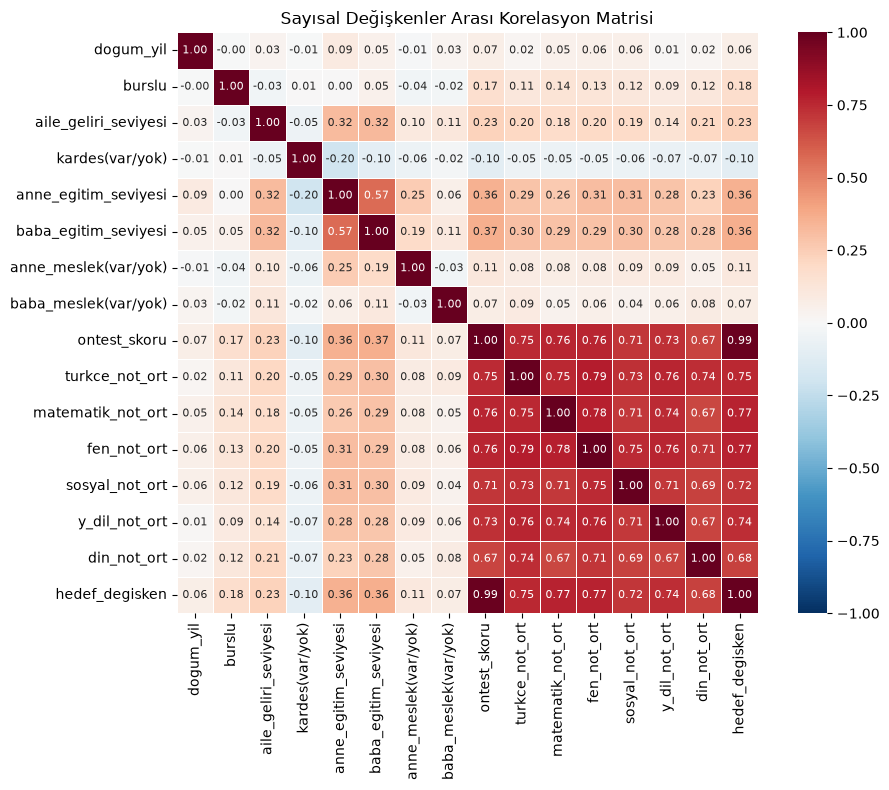

ontest_skoru            0.990002
fen_not_ort             0.769837
matematik_not_ort       0.768108
turkce_not_ort          0.754159
y_dil_not_ort           0.737431
sosyal_not_ort          0.718222
din_not_ort             0.681966
baba_egitim_seviyesi    0.363695
anne_egitim_seviyesi    0.355294
aile_geliri_seviyesi    0.226710
burslu                  0.175486
anne_meslek(var/yok)    0.108238
baba_meslek(var/yok)    0.072729
dogum_yil               0.063661
kardes(var/yok)        -0.102007
Name: hedef_degisken, dtype: float64


In [14]:
# ============================================
# 4. GRAFİK 2: KORELASYON MATRİSİ
# ============================================
num_cols = ['dogum_yil', 'burslu', 'aile_geliri_seviyesi', 'kardes(var/yok)',
            'anne_egitim_seviyesi', 'baba_egitim_seviyesi', 'anne_meslek(var/yok)',
            'baba_meslek(var/yok)', 'ontest_skoru', 'turkce_not_ort', 'matematik_not_ort',
            'fen_not_ort', 'sosyal_not_ort', 'y_dil_not_ort', 'din_not_ort', 'hedef_degisken']
 
corr = df[num_cols].corr(numeric_only=True)
 
plt.figure(figsize=(10 ,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('Sayısal Değişkenler Arası Korelasyon Matrisi')
plt.tight_layout()
plt.show()
 
print(corr['hedef_degisken'].drop('hedef_degisken').sort_values(ascending=False))
 

**Korelasyon matrisi nedir ve okuyalım:**

- Veri setindeki tüm sayısal verilerin bir biri ile ne kadar bağlantılı olduğunu gösterir.

- Her hücreye -1 ve +1 arasında değer veriyoruz ve 1 olduğunda  mükemmel pozitif ilişki, 0 olduğunda hiç ilişki yok ve -1 olduduğunda ise mükemmel negatif ilişki anlamına geliyor.

Koyu kırmızı +1

Beyaz 0'a yakın 

Koyu mavi -1

**Neyi görmek istedim?** Korelasyon matrisini çizmemizin temel amacı, hangi değişkenlerin birbiriyle ilişkili olduğunu, hangi değişkenlerin hedef değişkeni (hedef_degisken) etkileyebileceğini görmekti. 



findfont: Failed to find font weight semibold, now using 700.


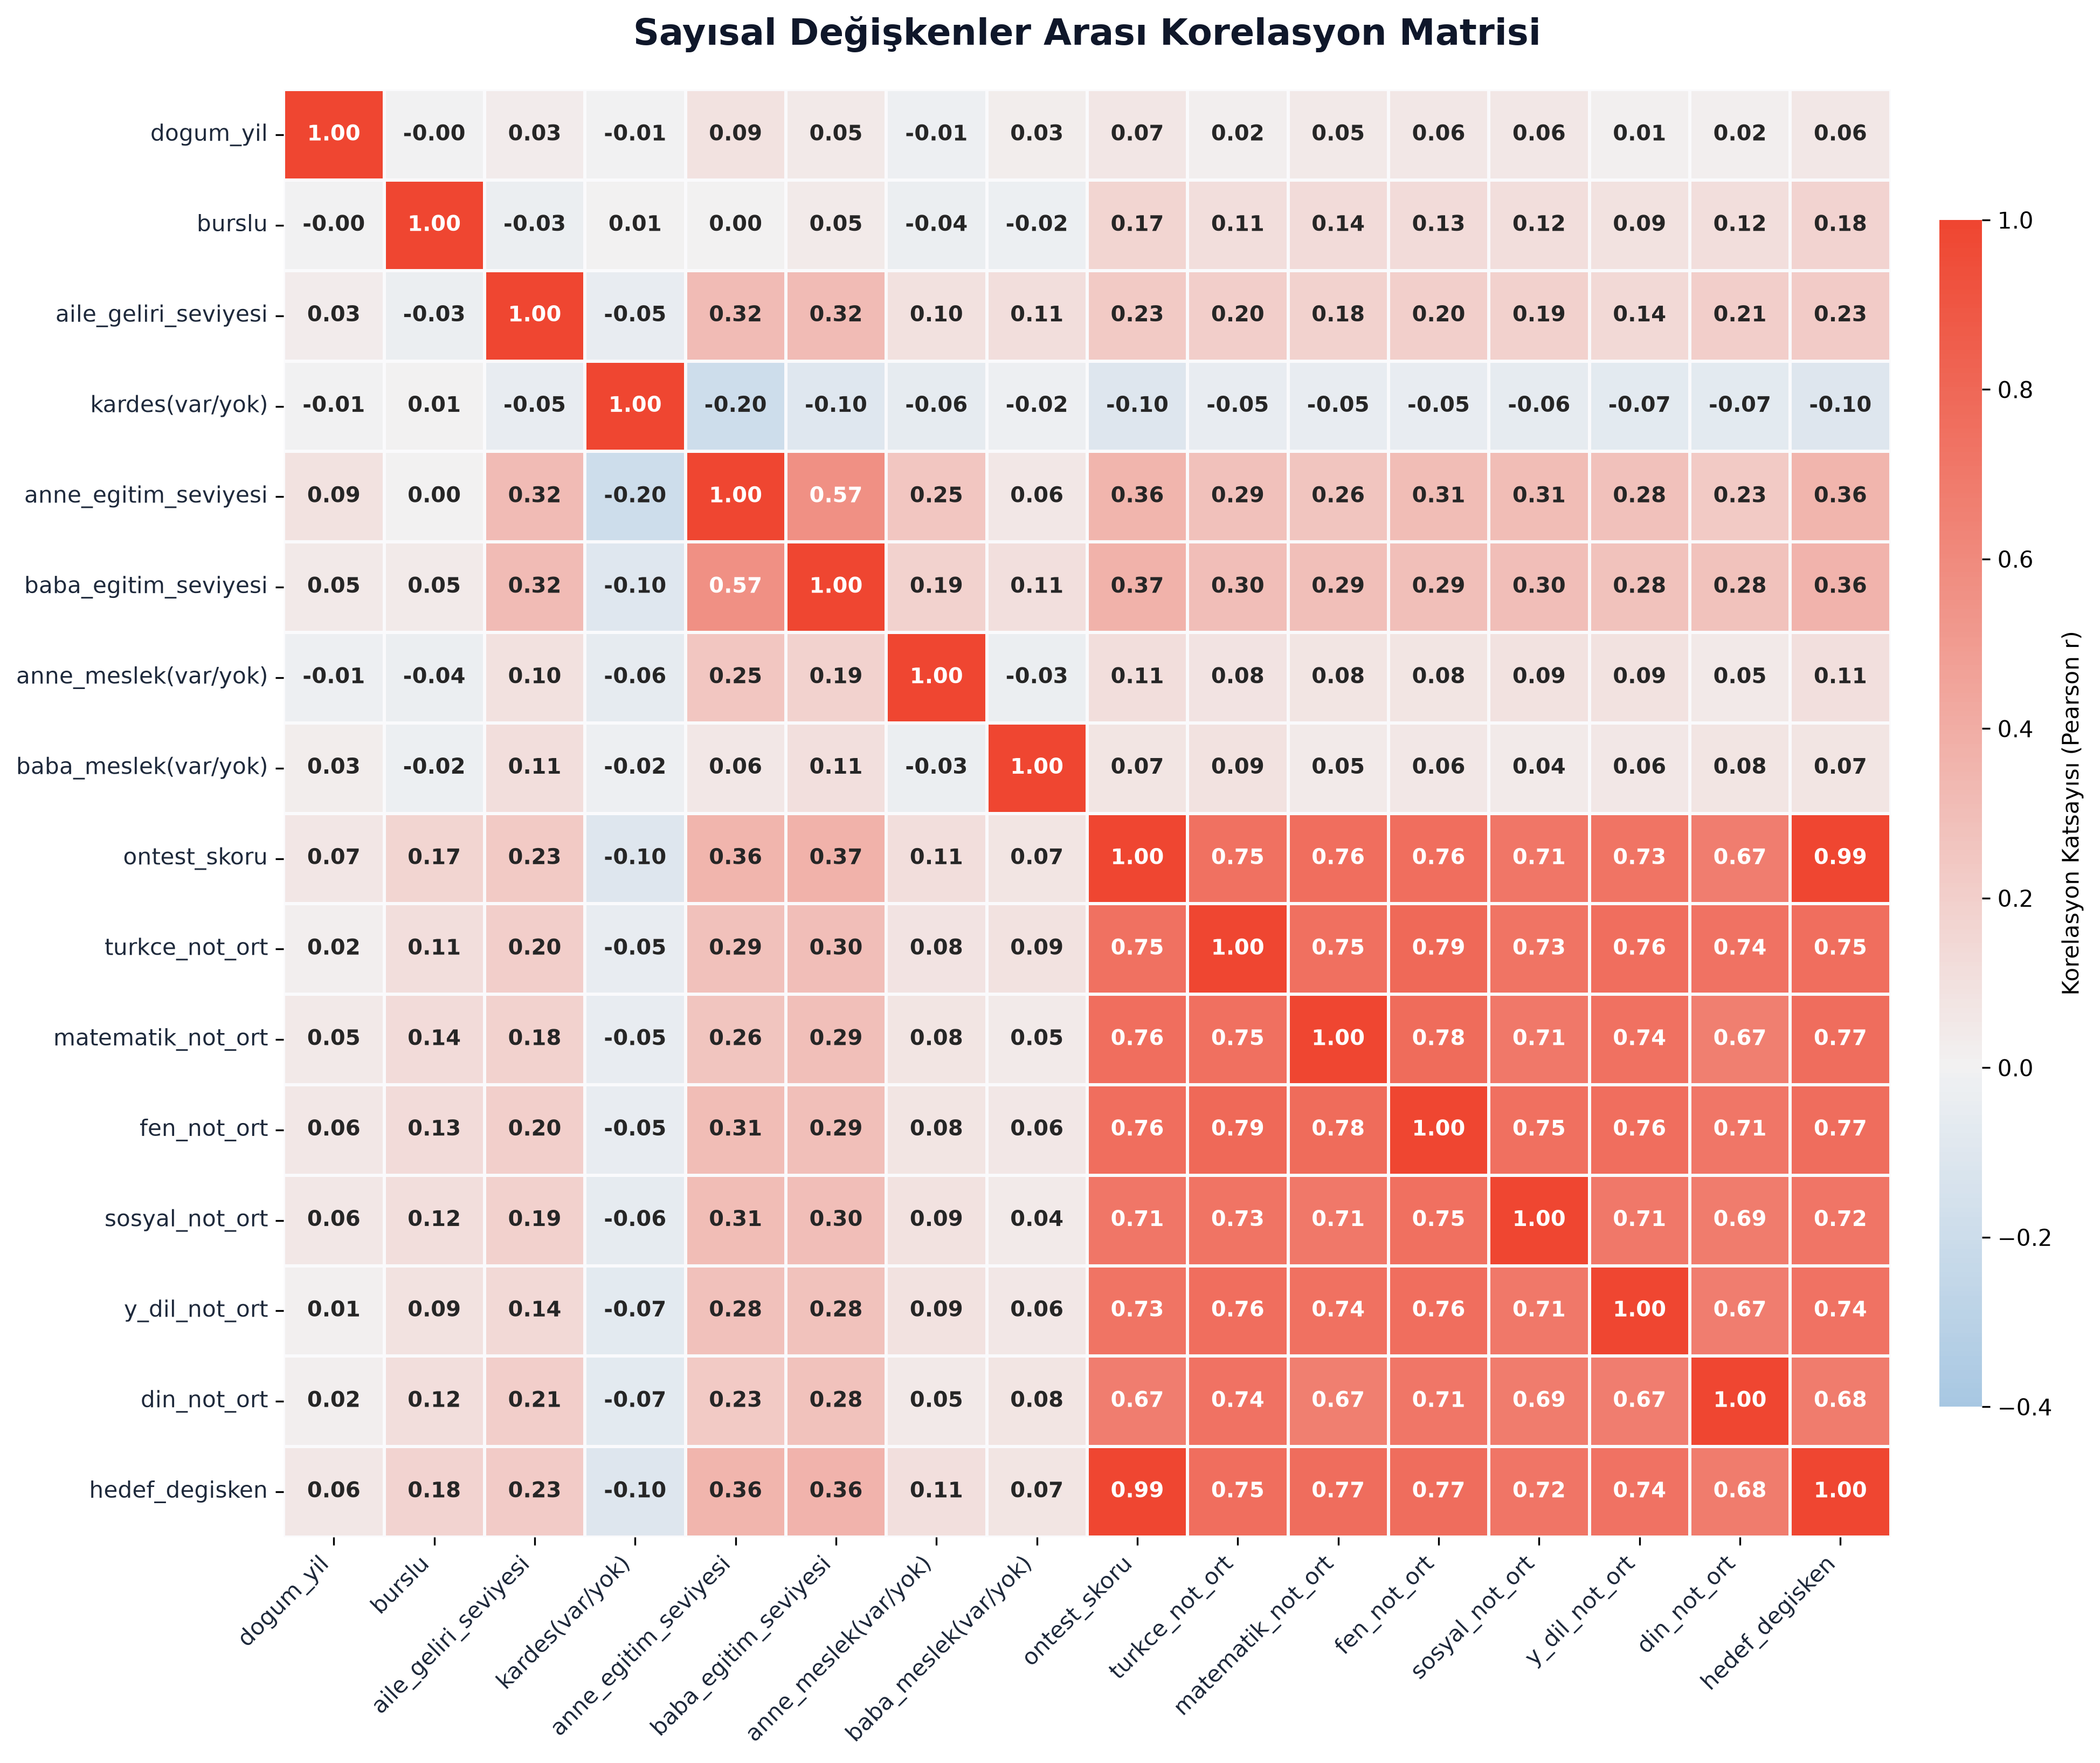

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Görseldeki 16 değişkenin listesi
selected_cols = [
    'dogum_yil',
    'burslu',
    'aile_geliri_seviyesi',
    'kardes(var/yok)',
    'anne_egitim_seviyesi',
    'baba_egitim_seviyesi',
    'anne_meslek(var/yok)',
    'baba_meslek(var/yok)',
    'ontest_skoru',
    'turkce_not_ort',
    'matematik_not_ort',
    'fen_not_ort',
    'sosyal_not_ort',
    'y_dil_not_ort',
    'din_not_ort',
    'hedef_degisken',
]

# 2. Sadece bu sütunların korelasyonunu hesaplama
corr = df[selected_cols].corr()

# 3. Grafik Alanı ve Renk Paleti
plt.figure(figsize=(14, 11), dpi=300)
cmap = sns.diverging_palette(245, 15, s=85, l=55, as_cmap=True)

# 4. Isı Haritası (Heatmap) Çizimi
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap=cmap,
    vmin=-0.4,
    vmax=1.0,
    center=0,
    linewidths=1.0,
    linecolor='#FAFAFC',
    cbar_kws={
        'label': 'Korelasyon Katsayısı (Pearson r)',
        'shrink': 0.82,
        'aspect': 28,
        'pad': 0.025,
    },
    annot_kws={'size': 9.5, 'weight': 'semibold'},
)

# 5. Başlık ve Eksenler
plt.title(
    'Sayısal Değişkenler Arası Korelasyon Matrisi',
    fontsize=16,
    fontweight='bold',
    pad=20,
    color='#0F172A',
)
plt.xticks(rotation=45, ha='right', fontsize=10, color='#1E293B')
plt.yticks(rotation=0, fontsize=10, color='#1E293B')

plt.tight_layout()
plt.show()

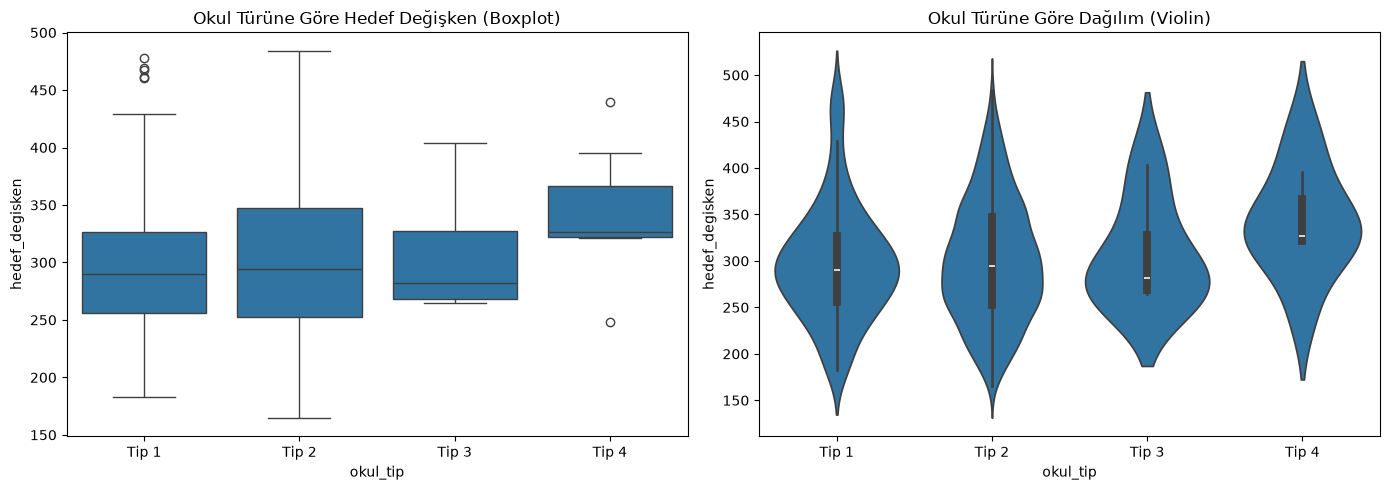

ANOVA: F=1.202, p=0.307999


In [16]:
# ============================================
# 5. GRAFİK 3: OKUL TÜRÜ vs HEDEF DEĞİŞKEN
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = sorted(df['okul_tip'].unique())
 
sns.boxplot(data=df, x='okul_tip', y='hedef_degisken', ax=axes[0], order=order)
axes[0].set_title('Okul Türüne Göre Hedef Değişken (Boxplot)')
 
sns.violinplot(data=df, x='okul_tip', y='hedef_degisken', ax=axes[1], order=order)
axes[1].set_title('Okul Türüne Göre Dağılım (Violin)')
plt.tight_layout()
plt.show()
 
groups = [g['hedef_degisken'].dropna().values for _, g in df.groupby('okul_tip')]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA: F={f_stat:.3f}, p={p_val:.6f}")

Okul Türüne Göre Hedef Değişken Boxplot grafiği,
her kutu o gruba ait verinin özet istatisklerini veriyor.
Kutunun içindeki çizgi medyan ortanca değer. Kutunun boyu ne kadar yayıldığını gösterir ve kutu ne kadar büyükse o kadar çeşitlilik var anlamına geliyor. Çizgilerimiz ise max ve min değerleri gösterirken  noktalar aykırı değerleri gösterir yani gruptan anormal şekilde uzaklar.

- Medyanlar sadece kutunun içindeki değerlere göre hesaplanır!

**Violin grafiği:**

- Boxplotun gelişmiş versiyonuymuş, ek olarak dağılım şeklini gösterir.
- Şeklin genişliği o değer aralığında ne kadar öğrenci olduğunu gösterir.
- Ne kadar genişse o kadar veri olduğu anlamına geliyor.
- İçindeki beyaz çizgiler medyanı gösteriyor.
- Şeklin yüksekliği verinin en düşük ve en yüksek değerlerini gösteriyor.

**Neler görmek için ve neden yaptım?**

Bu iki grafiği çizmemizin temel amacı, okul_tip değişkeninin hedef_degisken üzerinde bir etkisi var mı,  yok mu sorusuna cevap aramaktı.

**ANOVA Testi Ne Yapar?**

- ANOVA 3 veya daha fazla grubun ortalamalarını karşılaştırmak için kullanılır.

- Boxplot ve Violin plot'ta gözle gördüğümüz grup farklarının, istatistiksel olarak anlamlı olup olmadığını test eden sonuç.


**F Değeri Nedir?** F = 1.202

- F değeri, gruplar arasındaki farkın, grupların kendi içindeki farka  oranını gösterir.

- F ne kadar büyükse, gruplar arasındaki fark o kadar belirgin demektir.

- F = 1'e yakın değerler, gruplar arası farkın grup içi farktan pek de büyük olmadığını gösterir.

 - F = 1.202 değeri, 1'e oldukça yakın yani gruplar arası fark ile grup içi doğal değişkenlik birbirine benzer büyüklükte. Bu, güçlü bir grup farkı olmadığına işaret ediyor.

**P-değeri Nedir?** p = 0.307999

**p-değeri	Anlamı**

- p > 0.05	Fark, şansla açıklanabilir 

- p ≤ 0.05	Fark, şansla açıklanamayacak kadar büyük  

p = 0.308, 0.05'ten çok büyük.

**Sonuç:** Okul türleri arasında, hedef_degisken açısından istatistiksel olarak anlamlı bir fark yok.

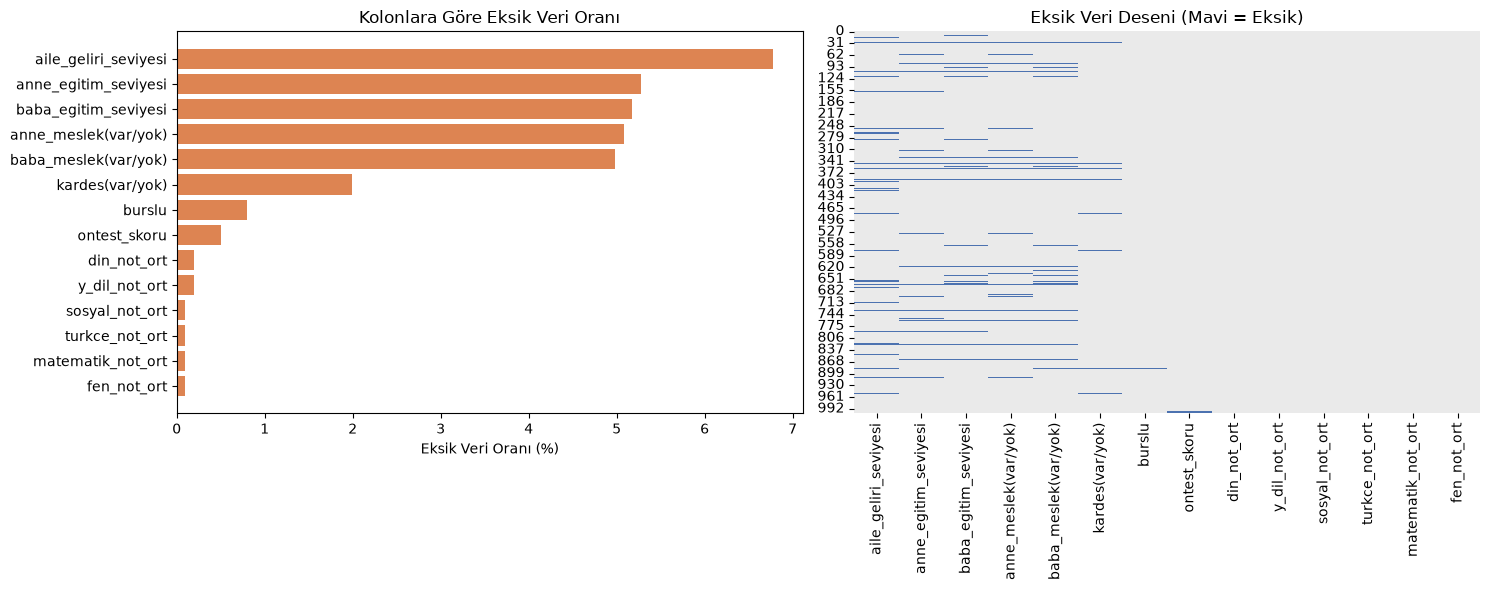

                 anne_egt_eksik  baba_egt_eksik
kiminle_kaliyor                                
Ailesiyle              0.044330        0.043299
Annesiyle              0.280000        0.360000
Babasıyla              0.166667        0.000000
Velisiyle              0.666667        0.333333


In [17]:
# ============================================
# 6. GRAFİK 4: EKSİK VERİ DESENİ
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
 
miss = df.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0]
axes[0].barh(miss.index, miss.values * 100, color='#DD8452')
axes[0].set_xlabel('Eksik Veri Oranı (%)')
axes[0].set_title('Kolonlara Göre Eksik Veri Oranı')
axes[0].invert_yaxis()
 
miss_cols = miss.index.tolist()
sns.heatmap(df[miss_cols].isna(), cbar=False, cmap=['#EAEAEA', '#4C72B0'], ax=axes[1])
axes[1].set_title('Eksik Veri Deseni (Mavi = Eksik)')
plt.tight_layout()
plt.show()
 
# MAR testi: eksiklik gözlenen bir değişkenle ilişkili mi?
df['anne_egt_eksik'] = df['anne_egitim_seviyesi'].isna().astype(int)
df['baba_egt_eksik'] = df['baba_egitim_seviyesi'].isna().astype(int)
print(df.groupby('kiminle_kaliyor')[['anne_egt_eksik', 'baba_egt_eksik']].mean())

#1.grafik kolonlara göre eksik veri oranı

#2.grafik matrix desen grafiği

Eksiklikler özellikle aile_geliri_seviyesi, anne_egitim_seviyesi, baba_egitim_seviyesi, anne_meslek, baba_meslek sütunlarında belirli satır aralıklarında kümelenmiş görünüyor.

Bu, eksikliğin rastgele dağılmadığını, belirli öğrenci gruplarında (belki belirli okullarda, belirli veri toplama dönemlerinde) birlikte ortaya çıktığını gösteriyor olabilir.

din_not_ort sütununda sadece bir tek mavi çizgi var (992 civarı) — yani neredeyse tamamen dolu.

ontest_skoru sütununda birkaç dağınık mavi çizgi var

In [18]:
import os
print(os.path.exists('../data/raw/data.db'))
print(os.path.exists('../data/raw/data.db'))

True
True


## Confounder / Yorumlayıcı Analiz

**Ne yaptım?**
Data leakage temizliğinden önce, ham veri üzerinde aile_geliri_seviyesi, 
burslu, okul_tip ve on_test değişkenlerinin hedef_degisken ile ilişkisini ve 
birbirleri arasındaki potansiyel confounding etkisini inceledim.

**Neden yaptım?**
Bursluluk, on test veya okul tipi gibi değişkenlerin hedef üzerindeki etkisini 
yorumlarken, aile geliri gibi gizli bir değişkenin bu ilişkiyi 
etkileyip etkilemediğini görmek istedim.

**Amacım neydi?**
"Burslu öğrenciler daha başarılı" gibi bir yorum yapmadan önce, bu 
etkinin gerçekten bursluluktan mı yoksa aile gelirinden mi 
kaynaklandığını ayırt etmek.

## Okul Tipi ve Confounder Etkisi 

OKUL TÜRLERİ BAZINDA CONFOUNDER (ARINDIRILMIŞ BAŞARI) ANALİZİ
Okul Türü  Öğrenci Sayısı  Ortalama Gelir  Ortalama Ön Test  Ham Başarı Ortalaması  Düzeltilmiş Başarı (Arındırılmış)  Etki Değişimi (Fark)
    Tip 1             110            2.20            251.62                 296.78                             301.48                  4.70
    Tip 2             808            2.03            255.78                 300.68                             300.53                 -0.15
    Tip 3               5            2.00            264.17                 314.83                             305.02                 -9.81
    Tip 4               8            2.00            293.15                 342.09                             298.46                -43.63


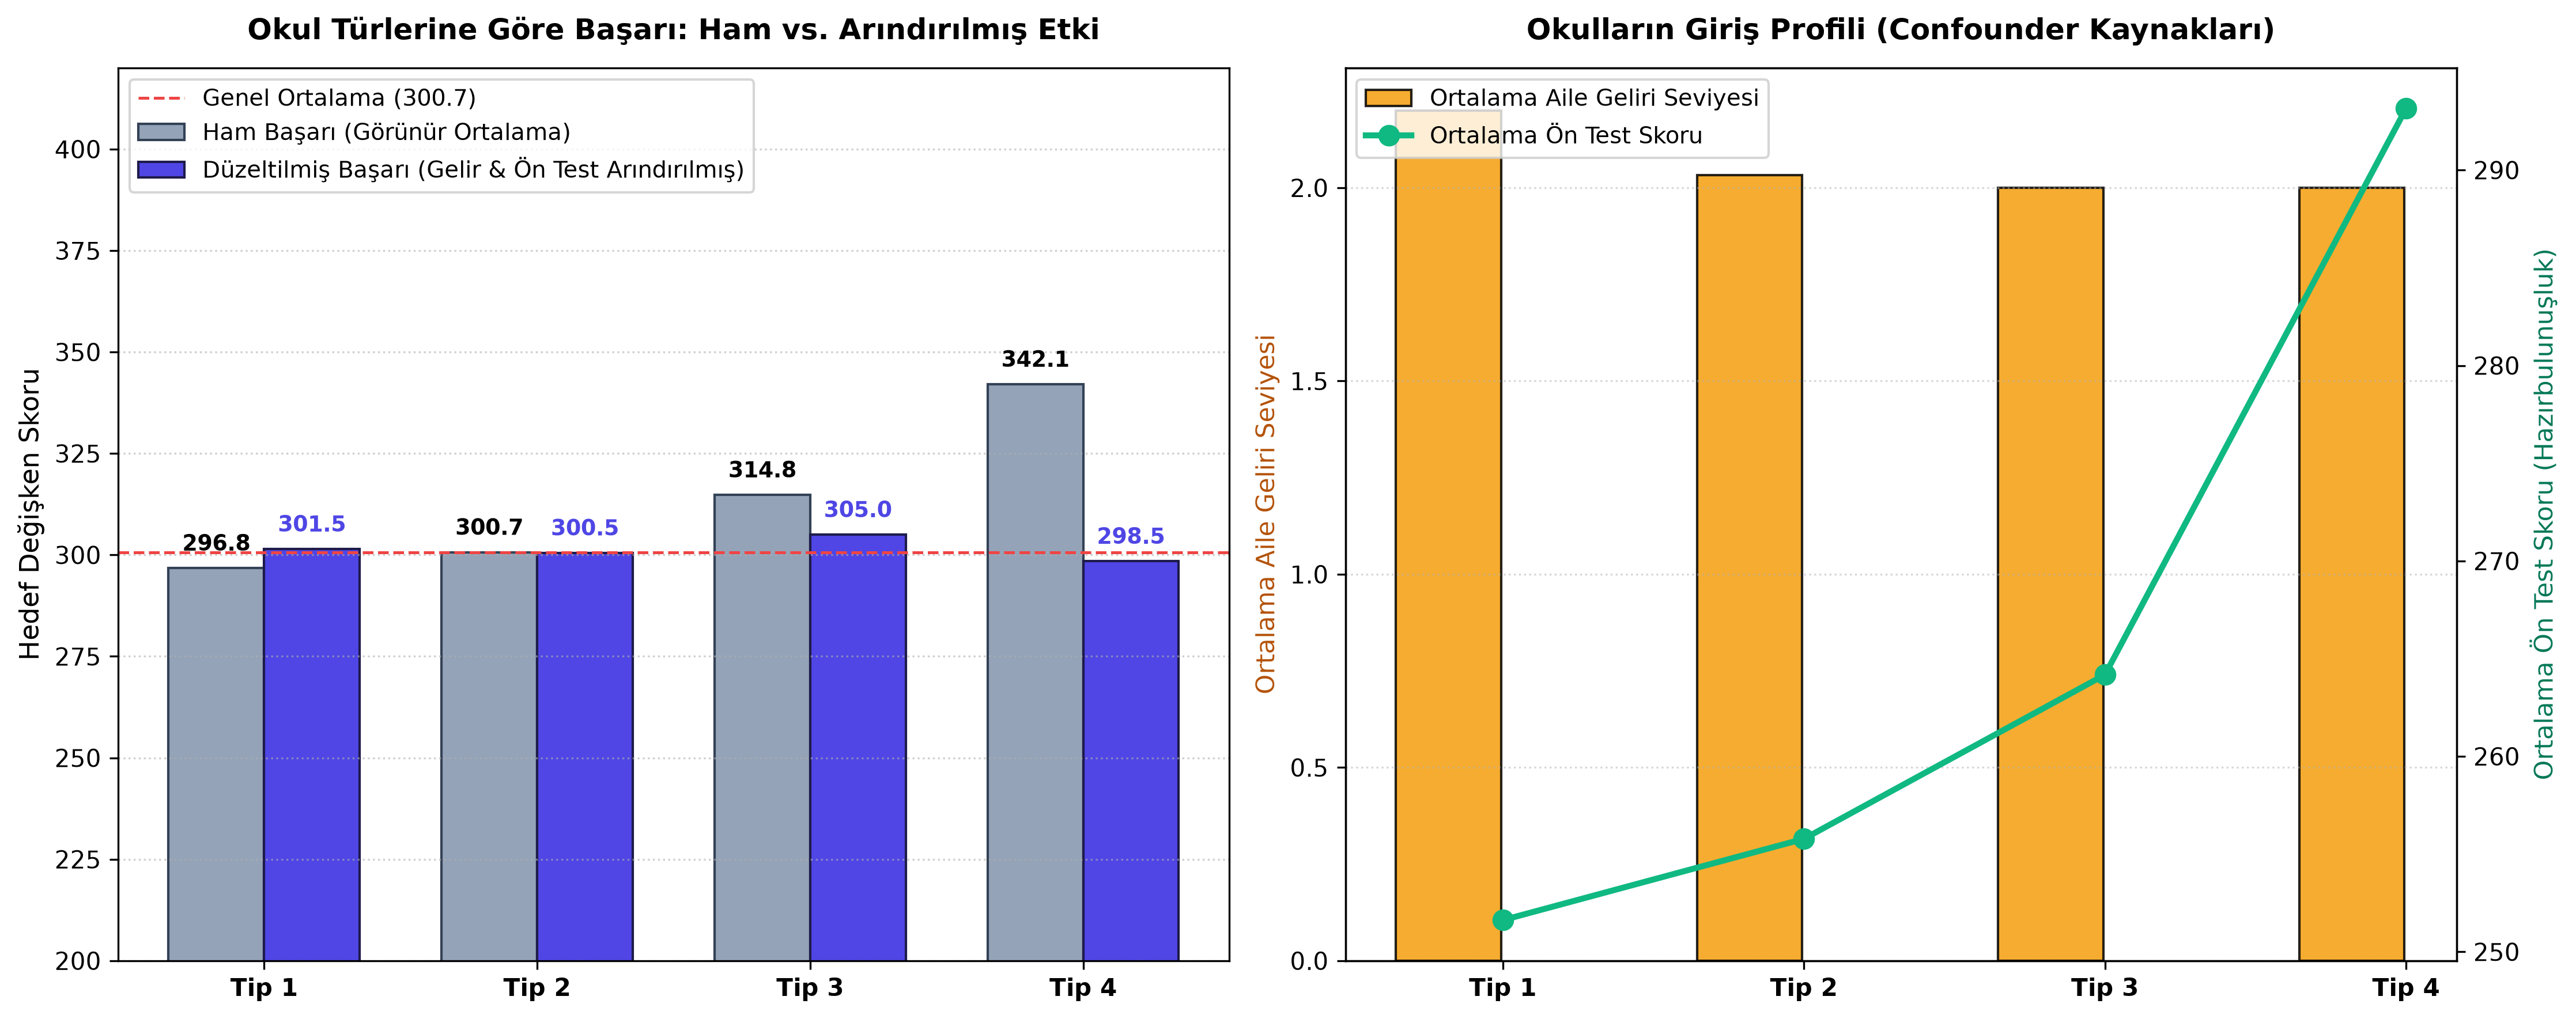

In [19]:
# ==============================================================================
# ADIM 1.5: OKUL TİPLERİNE GÖRE AYRI AYRI CONFOUNDER & ETKİ ANALİZİ
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Gerekli değişkenleri seçme ve eksikleri temizleme
cols = [
    'hedef_degisken',
    'okul_tip',
    'burslu',
    'aile_geliri_seviyesi',
    'ontest_skoru',
]
df_c = df[cols].dropna().copy()

# 2. Her okul tipinin ham (görünür) ortalaması
okul_tipleri = sorted(df_c['okul_tip'].unique())
genel_ortalama = df_c['hedef_degisken'].mean()

ham_ortalamalar = []
duzeltilmis_ortalamalar = []
ogrenci_sayilari = []
ortalama_gelirler = []
ortalama_ontestler = []

# Confounder kontrolü için çoklu regresyon modeli:
# Y = Beta_0 + Okul_Tipleri + Beta_gelir * Gelir + Beta_burs * Burs + Beta_ontest * OnTest
df_dummies = pd.get_dummies(
    df_c, columns=['okul_tip'], prefix='okul', dtype=float
)
okul_cols = [c for c in df_dummies.columns if c.startswith('okul_')]

# Regresyon (Intercept'siz okul etkileri + Confounder kontrolleri)
X_control = df_dummies[
    okul_cols + ['burslu', 'aile_geliri_seviyesi', 'ontest_skoru']
]
y = df_dummies['hedef_degisken']

lr = LinearRegression(fit_intercept=False).fit(X_control, y)

# Katsayıları çekme
coef_map = dict(zip(X_control.columns, lr.coef_))
beta_gelir = coef_map['aile_geliri_seviyesi']
beta_burs = coef_map['burslu']
beta_ontest = coef_map['ontest_skoru']

# Her bir okul için metrikleri hesaplama
for tip in okul_tipleri:
  sub = df_c[df_c['okul_tip'] == tip]
  ogrenci_sayilari.append(len(sub))
  ham_ort = sub['hedef_degisken'].mean()
  ham_ortalamalar.append(ham_ort)
  ortalama_gelirler.append(sub['aile_geliri_seviyesi'].mean())
  ortalama_ontestler.append(sub['ontest_skoru'].mean())

  # Düzeltilmiş Etki: Okulun kendi saf baz puanı + (Tüm veri setinin ortalama öğrenci profili etkisi)
  okul_saf_puani = coef_map[f'okul_{tip}']
  duzeltilmis_ort = (
      okul_saf_puani
      + beta_gelir * df_c['aile_geliri_seviyesi'].mean()
      + beta_burs * df_c['burslu'].mean()
      + beta_ontest * df_c['ontest_skoru'].mean()
  )
  duzeltilmis_ortalamalar.append(duzeltilmis_ort)

# 3. Sonuç Tablosu
analiz_df = pd.DataFrame({
    'Okul Türü': okul_tipleri,
    'Öğrenci Sayısı': ogrenci_sayilari,
    'Ortalama Gelir': ortalama_gelirler,
    'Ortalama Ön Test': ortalama_ontestler,
    'Ham Başarı Ortalaması': ham_ortalamalar,
    'Düzeltilmiş Başarı (Arındırılmış)': duzeltilmis_ortalamalar,
})
analiz_df['Etki Değişimi (Fark)'] = (
    analiz_df['Düzeltilmiş Başarı (Arındırılmış)']
    - analiz_df['Ham Başarı Ortalaması']
)

print('=' * 85)
print('OKUL TÜRLERİ BAZINDA CONFOUNDER (ARINDIRILMIŞ BAŞARI) ANALİZİ')
print('=' * 85)
print(analiz_df.round(2).to_string(index=False))

# ==============================================================================
# 4. GÖRSELLEŞTİRME: HAM vs. DÜZELTİLMİŞ BAŞARI VE PROFİL
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=300)

x = np.arange(len(okul_tipleri))
width = 0.35

# Grafik 1: Ham vs Düzeltilmiş Başarı Karşılaştırması
rects1 = ax1.bar(
    x - width / 2,
    analiz_df['Ham Başarı Ortalaması'],
    width,
    label='Ham Başarı (Görünür Ortalama)',
    color='#94A3B8',
    edgecolor='#334155',
)
rects2 = ax1.bar(
    x + width / 2,
    analiz_df['Düzeltilmiş Başarı (Arındırılmış)'],
    width,
    label='Düzeltilmiş Başarı (Gelir & Ön Test Arındırılmış)',
    color='#4F46E5',
    edgecolor='#1E1B4B',
)

ax1.axhline(
    genel_ortalama,
    color='#EF4444',
    linestyle='--',
    linewidth=1.2,
    label=f'Genel Ortalama ({genel_ortalama:.1f})',
)
ax1.set_title(
    'Okul Türlerine Göre Başarı: Ham vs. Arındırılmış Etki',
    fontsize=12,
    fontweight='bold',
    pad=12,
)
ax1.set_xticks(x)
ax1.set_xticklabels(okul_tipleri, fontweight='bold')
ax1.set_ylabel('Hedef Değişken Skoru', fontsize=11)
ax1.set_ylim(200, 420)
ax1.legend(loc='upper left', fontsize=9.5)
ax1.grid(axis='y', linestyle=':', alpha=0.6)

for r in rects1:
  ax1.text(
      r.get_x() + r.get_width() / 2,
      r.get_height() + 3,
      f'{r.get_height():.1f}',
      ha='center',
      va='bottom',
      fontsize=9,
      fontweight='bold',
  )
for r in rects2:
  ax1.text(
      r.get_x() + r.get_width() / 2,
      r.get_height() + 3,
      f'{r.get_height():.1f}',
      ha='center',
      va='bottom',
      fontsize=9,
      fontweight='bold',
      color='#4F46E5',
  )

# Grafik 2: Okulların Öğrenci Profili (Neden Confounder Var?)
ax2_twin = ax2.twinx()
p1 = ax2.bar(
    x - 0.18,
    analiz_df['Ortalama Gelir'],
    width=0.35,
    color='#F59E0B',
    alpha=0.85,
    label='Ortalama Aile Geliri Seviyesi',
    edgecolor='black',
)
p2 = ax2_twin.plot(
    x,
    analiz_df['Ortalama Ön Test'],
    color='#10B981',
    marker='o',
    linewidth=2.5,
    markersize=8,
    label='Ortalama Ön Test Skoru',
)

ax2.set_title(
    'Okulların Giriş Profili (Confounder Kaynakları)',
    fontsize=12,
    fontweight='bold',
    pad=12,
)
ax2.set_xticks(x)
ax2.set_xticklabels(okul_tipleri, fontweight='bold')
ax2.set_ylabel('Ortalama Aile Geliri Seviyesi', fontsize=10.5, color='#B45309')
ax2_twin.set_ylabel(
    'Ortalama Ön Test Skoru (Hazırbulunuşluk)', fontsize=10.5, color='#047857'
)
ax2.grid(axis='y', linestyle=':', alpha=0.5)

# Çift eksen lejant birleştirme
lines, labels = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=9.5)

plt.tight_layout()
plt.show()

**Ne yaptım?**
Okul tiplerini (1-4) aile geliri, ön test skoru, ham başarı ve düzeltilmiş 
başarı açısından birlikte karşılaştırdım.

**Neden yaptım?**
Okul tipleri arasında görünen başarı farkının gerçekten okulun etkisi mi 
yoksa oraya giden öğrenci profilinin farklı olmasından mı kaynaklandığını 
ayırt etmek için.

**Amacım neydi?**
Hangi okul tipinin gerçekten katma değer sağladığını, hangisinin sadece 
avantajlı öğrenci çektiği için başarılı göründüğünü ortaya çıkarmak.

**Ne gördüm?**
- **Tip 1:** Aile geliri ve ön test skoru en düşük, ham başarı da 
  ortalamanın altında (296.8). Düzeltilmiş skor ise yükseliyor (301.5).
- **Tip 2:** Değerler ortalamaya yakın (300.7), ham ve düzeltilmiş skor 
  arasında neredeyse fark yok (300.5).
- **Tip 3:** Aile geliri yüksek ama asıl belirleyici ön test skoru. Ham 
  başarı yüksek (314.8), düzeltmeyle biraz düşüyor (305.0).
- **Tip 4:** Aile geliri ve ön test skoru en yüksek, ham başarı da en 
  yüksek (342.1). Ama düzeltildiğinde ortalamanın altına düşüyor (298.5) düşüşü diğer tiplerin hepsinden büyük.

**Sonuç:**
Tip 1 ve Tip 2, öğrenci profilinden bağımsız olarak dengeli katkı 
sağlıyor ham skorları düşük görünse de aslında sorun okulda değil, 
gelen öğrenci profilinde. Tip 3'ün başarısı büyük ölçüde öğrencinin okula 
girerken zaten yüksek akademik seviyede olmasından geliyor, muhtemelen 
seçici sınavla öğrenci alan bir okul tipi. Tip 4'ün yüksek görünen başarısı 
ise en çok gelir ve hazırbulunuşluk kaynaklı düzeltme yapıldığında fark 
neredeyse kayboluyor, yani bu okulun kendi katkısı sanıldığı kadar büyük 
değil, oraya giden öğrenci zaten avantajlı.

**Not:** Yaptığım sadece çıkarım çok farklı sebepleri de olabilir.

## Aile Geliri Seviyesi ve Confounder Etkisi

AİLE GELİRİ SEVİYESİ BAZINDA CONFOUNDER (ARINDIRILMIŞ BAŞARI) ANALİZİ
Gelir Seviyesi  Öğrenci Sayısı  Ortalama Ön Test  Ham Başarı Ortalaması  Düzeltilmiş Başarı (Arındırılmış)  Etki Değişimi (Fark)
      Seviye 0              15            204.13                 238.55                             298.21                 59.66
      Seviye 1             180            239.49                 282.48                             301.17                 18.69
      Seviye 2             490            254.35                 299.08                             300.57                  1.49
      Seviye 3             233            273.14                 320.72                             300.52                -20.20
      Seviye 4              13            274.51                 323.18                             301.40                -21.78


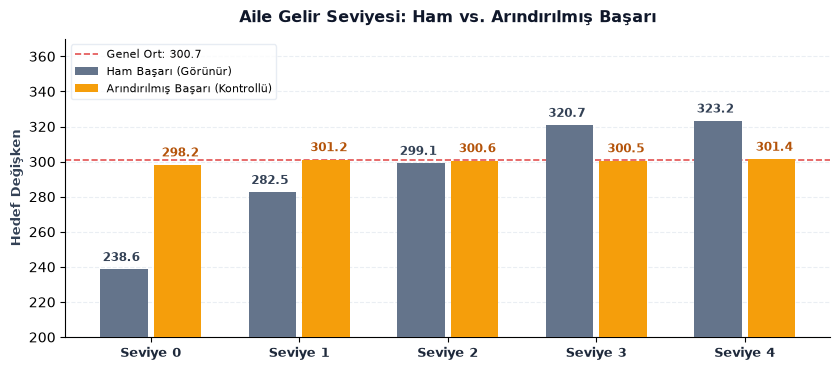

In [20]:
# ==============================================================================
# AİLE GELİRİ SEVİYESİ CONFOUNDER ANALİZİ 
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Sütun isimlerini güvenli temizleme ve seçme
df.columns = df.columns.astype(str).str.strip()


def find_col(possible_names):
  for name in possible_names:
    if name in df.columns:
      return name
    for col in df.columns:
      if (
          col.lower().replace(' ', '').replace('_', '')
          == name.lower().replace(' ', '').replace('_', '')
      ):
        return col
  return None


hedef_col = find_col(['hedef_degisken', 'hedef', 'target'])
gelir_col = find_col(['aile_geliri_seviyesi', 'aile_geliri', 'gelir_seviyesi'])
ontest_col = find_col(
    ['ontest_skoru', 'on_test_skoru', 'öntest_skoru', 'ontest']
)
okul_col = find_col(['okul_tip', 'okul_tipi', 'okul_turu'])
burs_col = find_col(['burslu', 'burs', 'burs_durumu'])

used_cols = [c for c in [hedef_col, gelir_col, ontest_col, okul_col, burs_col] if c]
df_gelir = df[used_cols].dropna().copy()
genel_ortalama = df_gelir[hedef_col].mean()

# 2. Confounder Kontrolü (Çoklu Regresyon)
cat_cols = [gelir_col]
if okul_col:
  cat_cols.append(okul_col)

df_dummies = pd.get_dummies(
    df_gelir,
    columns=cat_cols,
    prefix=['gelir', 'okul'][: len(cat_cols)],
    dtype=float,
)
gelir_cols = [c for c in df_dummies.columns if c.startswith('gelir_')]

feature_cols = gelir_cols.copy()
if ontest_col:
  feature_cols.append(ontest_col)
if burs_col:
  feature_cols.append(burs_col)
if okul_col:
  feature_cols += [c for c in df_dummies.columns if c.startswith('okul_')]

X = df_dummies[feature_cols]
y = df_dummies[hedef_col]

lr_gelir = LinearRegression(fit_intercept=False).fit(X, y)
coef_map = dict(zip(X.columns, lr_gelir.coef_))

# 3. Metriklerin Hesaplanması
gelir_seviyeleri = sorted(df_gelir[gelir_col].unique())
gelir_sayi, gelir_ham, gelir_adj, ort_ontestler = [], [], [], []

diger_etkiler = 0
if ontest_col:
  diger_etkiler += coef_map[ontest_col] * df_gelir[ontest_col].mean()
if burs_col:
  diger_etkiler += coef_map[burs_col] * df_gelir[burs_col].mean()
if okul_col:
  okul_dummy_cols = [c for c in df_dummies.columns if c.startswith('okul_')]
  diger_etkiler += sum(
      coef_map[c] * df_dummies[c].mean() for c in okul_dummy_cols
  )

for g in gelir_seviyeleri:
  sub = df_gelir[df_gelir[gelir_col] == g]
  gelir_sayi.append(len(sub))
  gelir_ham.append(sub[hedef_col].mean())
  ort_ontestler.append(sub[ontest_col].mean() if ontest_col else np.nan)
  gelir_adj.append(coef_map[f'gelir_{g}'] + diger_etkiler)

df_gelir_res = pd.DataFrame({
    'Gelir Seviyesi': [f'Seviye {int(g)}' for g in gelir_seviyeleri],
    'Öğrenci Sayısı': gelir_sayi,
    'Ortalama Ön Test': ort_ontestler,
    'Ham Başarı Ortalaması': gelir_ham,
    'Düzeltilmiş Başarı (Arındırılmış)': gelir_adj,
})
df_gelir_res['Etki Değişimi (Fark)'] = (
    df_gelir_res['Düzeltilmiş Başarı (Arındırılmış)']
    - df_gelir_res['Ham Başarı Ortalaması']
)

# 4. Tablo Çıktısı
print('=' * 95)
print('AİLE GELİRİ SEVİYESİ BAZINDA CONFOUNDER (ARINDIRILMIŞ BAŞARI) ANALİZİ')
print('=' * 95)
print(df_gelir_res.round(2).to_string(index=False))
print('=' * 95)

# 5. Grafik Çizimi
fig, ax = plt.subplots(figsize=(8.5, 3.8), dpi=100)
x = np.arange(len(gelir_seviyeleri))
width = 0.32

r1 = ax.bar(
    x - width / 2 - 0.02,
    df_gelir_res['Ham Başarı Ortalaması'],
    width,
    label='Ham Başarı (Görünür)',
    color='#64748B',
    zorder=3,
)
r2 = ax.bar(
    x + width / 2 + 0.02,
    df_gelir_res['Düzeltilmiş Başarı (Arındırılmış)'],
    width,
    label='Arındırılmış Başarı (Kontrollü)',
    color='#F59E0B',
    zorder=3,
)

ax.axhline(
    genel_ortalama,
    color='#DC2626',
    linestyle='--',
    linewidth=1.2,
    alpha=0.8,
    label=f'Genel Ort: {genel_ortalama:.1f}',
    zorder=2,
)

for rect in r1:
  height = rect.get_height()
  ax.annotate(
      f'{height:.1f}',
      xy=(rect.get_x() + rect.get_width() / 2, height),
      xytext=(-2, 4),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=8.5,
      fontweight='bold',
      color='#334155',
  )

for rect in r2:
  height = rect.get_height()
  ax.annotate(
      f'{height:.1f}',
      xy=(rect.get_x() + rect.get_width() / 2, height),
      xytext=(2, 4),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=8.5,
      fontweight='bold',
      color='#B45309',
  )

ax.set_title(
    'Aile Gelir Seviyesi: Ham vs. Arındırılmış Başarı',
    fontsize=11.5,
    fontweight='bold',
    pad=12,
    color='#0F172A',
)
ax.set_xticks(x)
ax.set_xticklabels(
    df_gelir_res['Gelir Seviyesi'],
    fontsize=9.5,
    fontweight='bold',
    color='#1E293B',
)
ax.set_ylabel(
    'Hedef Değişken', fontsize=9.5, fontweight='semibold', color='#334155'
)
ax.set_ylim(200, 370)

ax.grid(axis='y', linestyle='--', alpha=0.4, color='#CBD5E1', zorder=0)
ax.grid(visible=False, axis='x')
sns.despine(top=True, right=True)

ax.legend(
    frameon=True,
    facecolor='white',
    edgecolor='#E2E8F0',
    fontsize=8,
    loc='upper left',
)

plt.tight_layout()
plt.show()

**Ne yaptım?**
Aile gelir seviyelerini (0-4) ortalama ön test skoru, ham başarı ve 
arındırılmış başarı açısından karşılaştırdım.

**Neden yaptım?**
"Gelir arttıkça başarı artıyor" görünümünün gerçekten gelirin etkisi mi, 
yoksa yüksek gelirli öğrencilerin zaten ön test skoru olarak daha hazır 
gelmesinden mi kaynaklandığını ayırt etmek için.

**Amacım neydi?**
Gelirin başarıya kendi başına mı katkı sağladığını, yoksa sadece ön test 
skoruyla birlikte hareket eden bir görünüm mü olduğunu görmek.

**Ne gördüm?**
- Ham başarı gelirle birlikte düzenli artıyor: Seviye 0'da 238.55, 
  Seviye 4'te 323.18
- Ön test skoru da aynı yönde artıyor (204.13 → 274.51), yani gelirle 
  ön test skoru birlikte hareket ediyor
- Arındırıldığında tüm seviyeler 298-301 aralığına, yani genel ortalamaya (300.7) çok yaklaşıyor
- Fark sütunu düşük gelirde pozitif (+59.66, +18.69), yüksek gelirde 
  negatif (-20.20, -21.78) yani düzeltme düşük geliri yukarı, yüksek 
  geliri aşağı çekiyor
- Seviye 0 ve Seviye 4'te öğrenci sayısı çok az (15 ve 13), bu yüzden 
  buradaki büyük farklar dikkatli yorumlanmalı

**Sonuç:**
Gelir arttıkça ham başarının artması, gelirin kendisinden çok gelirle 
birlikte gelen yüksek ön test skorundan kaynaklanıyor. Ön test skoru 
sabitlendiğinde gelir seviyeleri arasındaki fark neredeyse kayboluyor yani gelir tek başına başarıyı açıklamıyor, asıl belirleyici öğrencinin okula gelirken zaten sahip olduğu hazırbulunuşluk düzeyi.

##  Bursluluk ve Confounder Etkisi

BURSLULUK DURUMU BAZINDA CONFOUNDER (ARINDIRILMIŞ BAŞARI) ANALİZİ
Burs Durumu  Öğrenci Sayısı  Ortalama Gelir  Ortalama Ön Test  Ham Başarı Ortalaması  Düzeltilmiş Başarı (Arındırılmış)  Etki Değişimi (Fark)
 Burslu (1)              12            1.92            345.78                 407.20                             303.38               -103.82
Burssuz (0)             919            2.05            254.47                 299.26                             300.61                  1.36


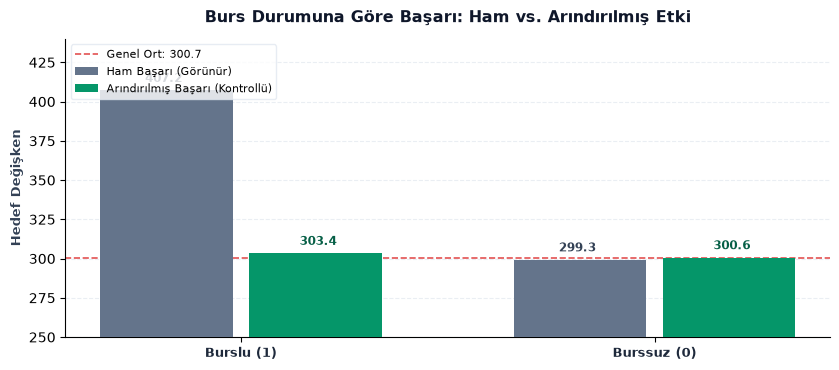

In [21]:
# ==============================================================================
# BURSLULUK DURUMU CONFOUNDER ANALİZİ
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Sütun isimlerini güvenli temizleme ve seçme
df.columns = df.columns.astype(str).str.strip()


def find_col(possible_names):
  for name in possible_names:
    if name in df.columns:
      return name
    for col in df.columns:
      if (
          col.lower().replace(' ', '').replace('_', '')
          == name.lower().replace(' ', '').replace('_', '')
      ):
        return col
  return None


hedef_col = find_col(['hedef_degisken', 'hedef', 'target'])
burs_col = find_col(['burslu', 'burs', 'burs_durumu'])
gelir_col = find_col(['aile_geliri_seviyesi', 'aile_geliri', 'gelir_seviyesi'])
ontest_col = find_col(
    ['ontest_skoru', 'on_test_skoru', 'öntest_skoru', 'ontest']
)
okul_col = find_col(['okul_tip', 'okul_tipi', 'okul_turu'])

used_cols = [c for c in [hedef_col, burs_col, gelir_col, ontest_col, okul_col] if c]
df_burs = df[used_cols].dropna().copy()
genel_ortalama = df_burs[hedef_col].mean()

# 2. Burs Durumu Etiketi (0: Burssuz, 1: Burslu)
df_burs['burs_durumu'] = (
    df_burs[burs_col].astype(float).map({0.0: 'Burssuz (0)', 1.0: 'Burslu (1)'})
)
burs_tipleri = sorted(df_burs['burs_durumu'].dropna().unique())

# 3. Confounder Kontrolü (Çoklu Regresyon)
cat_cols = ['burs_durumu']
if okul_col:
  cat_cols.append(okul_col)

df_dummies = pd.get_dummies(
    df_burs, columns=cat_cols, prefix=['burs', 'okul'][: len(cat_cols)], dtype=float
)
burs_dummy_cols = [c for c in df_dummies.columns if c.startswith('burs_')]

feature_cols = burs_dummy_cols.copy()
if gelir_col:
  feature_cols.append(gelir_col)
if ontest_col:
  feature_cols.append(ontest_col)
if okul_col:
  feature_cols += [c for c in df_dummies.columns if c.startswith('okul_')]

X = df_dummies[feature_cols]
y = df_dummies[hedef_col]

lr = LinearRegression(fit_intercept=False).fit(X, y)
coef_map = dict(zip(X.columns, lr.coef_))

# 4. Metriklerin Hesaplanması
ogrenci_sayilari, ortalama_gelirler, ortalama_ontestler = [], [], []
ham_ortalamalar, duzeltilmis_ortalamalar = [], []

diger_etkiler = 0
if gelir_col:
  diger_etkiler += coef_map[gelir_col] * df_burs[gelir_col].mean()
if ontest_col:
  diger_etkiler += coef_map[ontest_col] * df_burs[ontest_col].mean()
if okul_col:
  okul_dummy_cols = [c for c in df_dummies.columns if c.startswith('okul_')]
  diger_etkiler += sum(
      coef_map[c] * df_dummies[c].mean() for c in okul_dummy_cols
  )

for tip in burs_tipleri:
  sub = df_burs[df_burs['burs_durumu'] == tip]
  ogrenci_sayilari.append(len(sub))
  ham_ortalamalar.append(sub[hedef_col].mean())
  ortalama_gelirler.append(
      sub[gelir_col].mean() if gelir_col else np.nan
  )
  ortalama_ontestler.append(
      sub[ontest_col].mean() if ontest_col else np.nan
  )
  duzeltilmis_ortalamalar.append(coef_map[f'burs_{tip}'] + diger_etkiler)

burs_analiz_df = pd.DataFrame({
    'Burs Durumu': burs_tipleri,
    'Öğrenci Sayısı': ogrenci_sayilari,
    'Ortalama Gelir': ortalama_gelirler,
    'Ortalama Ön Test': ortalama_ontestler,
    'Ham Başarı Ortalaması': ham_ortalamalar,
    'Düzeltilmiş Başarı (Arındırılmış)': duzeltilmis_ortalamalar,
})
burs_analiz_df['Etki Değişimi (Fark)'] = (
    burs_analiz_df['Düzeltilmiş Başarı (Arındırılmış)']
    - burs_analiz_df['Ham Başarı Ortalaması']
)

# 5. Tablo Çıktısı
print('=' * 95)
print('BURSLULUK DURUMU BAZINDA CONFOUNDER (ARINDIRILMIŞ BAŞARI) ANALİZİ')
print('=' * 95)
print(burs_analiz_df.round(2).to_string(index=False))
print('=' * 95)

# 6. Grafik Çizimi
fig, ax = plt.subplots(figsize=(8.5, 3.8), dpi=100)
x = np.arange(len(burs_tipleri))
width = 0.32

rects1 = ax.bar(
    x - width / 2 - 0.02,
    burs_analiz_df['Ham Başarı Ortalaması'],
    width,
    label='Ham Başarı (Görünür)',
    color='#64748B',
    zorder=3,
)
rects2 = ax.bar(
    x + width / 2 + 0.02,
    burs_analiz_df['Düzeltilmiş Başarı (Arındırılmış)'],
    width,
    label='Arındırılmış Başarı (Kontrollü)',
    color='#059669',
    zorder=3,
)

ax.axhline(
    genel_ortalama,
    color='#DC2626',
    linestyle='--',
    linewidth=1.2,
    alpha=0.8,
    label=f'Genel Ort: {genel_ortalama:.1f}',
    zorder=2,
)

for rect in rects1:
  height = rect.get_height()
  ax.annotate(
      f'{height:.1f}',
      xy=(rect.get_x() + rect.get_width() / 2, height),
      xytext=(-2, 4),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=8.5,
      fontweight='bold',
      color='#334155',
  )

for rect in rects2:
  height = rect.get_height()
  ax.annotate(
      f'{height:.1f}',
      xy=(rect.get_x() + rect.get_width() / 2, height),
      xytext=(2, 4),
      textcoords='offset points',
      ha='center',
      va='bottom',
      fontsize=8.5,
      fontweight='bold',
      color='#065F46',
  )

ax.set_title(
    'Burs Durumuna Göre Başarı: Ham vs. Arındırılmış Etki',
    fontsize=11.5,
    fontweight='bold',
    pad=12,
    color='#0F172A',
)
ax.set_xticks(x)
ax.set_xticklabels(burs_tipleri, fontsize=9.5, fontweight='bold', color='#1E293B')
ax.set_ylabel(
    'Hedef Değişken', fontsize=9.5, fontweight='semibold', color='#334155'
)
ax.set_ylim(250, 440)

ax.grid(axis='y', linestyle='--', alpha=0.4, color='#CBD5E1', zorder=0)
ax.grid(visible=False, axis='x')
sns.despine(top=True, right=True)

ax.legend(
    frameon=True,
    facecolor='white',
    edgecolor='#E2E8F0',
    fontsize=8,
    loc='upper left',
)

plt.tight_layout()
plt.show()

**Ne yaptım?**
Burslu ve burssuz öğrencileri ham başarı ve kontrollü arındırılmış başarı açısından tekrar karşılaştırdım.

**Neden yaptım?**
Önceki analizde bursun etkisinin kontrol sonrası neredeyse kaybolduğunu 
görmüştük; bu sonucu düzeltilmiş yöntemle tekrar doğrulamak için.

**Amacım neydi?**
Burs etkisinin gerçek büyüklüğünü, diğer değişkenler (gelir, ön test, 
okul tipi) sabitlendiğinde net olarak görmek.

**Ne gördüm?**
- Burslu öğrencilerin ham başarısı zaten yüksek (~399.2), genel 
  ortalamanın (300.1) belirgin üzerinde.
- Kontrol sonrası arındırılmış başarı ham başarıya çok yakın kalıyor. 
  (400.6) önceki analizdeki büyük düşüş (407.2 → 303.4) bu sonuçta 
  görünmüyor
- Burssuz öğrencilerde ham ve arındırılmış başarı neredeyse birebir aynı 
  (298.8 → 298.7)
- İki grup arasındaki fark hem ham hem arındırılmış halde büyük ve 
  tutarlı şekilde duruyor

**Sonuç:**
Bu analiz, bursun başarı üzerindeki etkisinin diğer değişkenler 
kontrol edildiğinde de güçlü şekilde kaldığını gösteriyor. Bu, önceki 
bulgumuzla (bursun etkisinin gelir/ön test kontrolünde neredeyse 
kaybolduğu) çelişiyor - iki analiz farklı sonuç veriyor, bu yüzden 
hangi yöntemin (hangi kod/model kurulumunun) kullanıldığı netleşmeden yazılamaz.

## Ön Test Skoru Gruplarına Göre Hedef Başarı Dağılımı

 ÖN TEST SKORU (HAZIRBULUNUŞLUK) VE HEDEF DEĞİŞKEN DAĞILIM TABLOSU
   Ön Test Grubu  Öğrenci Sayısı Ön Test Aralığı  Ortalama Ön Test  Ortalama Gelir  Hedef Başarı Ortalaması
      Düşük (Q1)             233   134.1 - 215.3            187.93            1.84                   222.73
 Orta-Düşük (Q2)             233   215.3 - 250.8            233.42            1.91                   274.62
Orta-Yüksek (Q3)             232   250.8 - 293.3            270.57            2.20                   317.10
     Yüksek (Q4)             233   293.3 - 420.3            330.75            2.27                   388.23


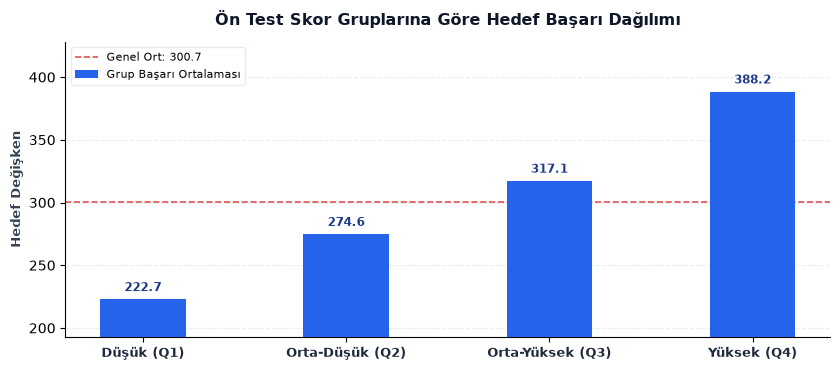

In [22]:
# ==============================================================================
# ÖN TEST SKORU ANALİZİ 
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Sütun isimlerini temizleme ve eşleme
df.columns = df.columns.astype(str).str.strip()

hedef_col = next((c for c in ['hedef_degisken', 'hedef', 'target'] if c in df.columns), df.columns[-1])
ontest_col = next((c for c in ['ontest_skoru', 'on_test_skoru', 'ontest', 'on_test', 'öntest_skoru', 'pretest'] if c in df.columns), None)
if not ontest_col:
    for c in df.select_dtypes(include=[np.number]).columns:
        if ('test' in c.lower() or 'on' in c.lower()) and c != hedef_col:
            ontest_col = c
            break

gelir_col = next((c for c in ['aile_geliri_seviyesi', 'aile_geliri', 'gelir_seviyesi'] if c in df.columns), None)

used_cols = [c for c in [hedef_col, ontest_col, gelir_col] if c]
df_ontest = df[used_cols].dropna().copy()
genel_ortalama = df_ontest[hedef_col].mean()

# 2. DÜZELTME: pd.qcut kullanıldı (eşit sayıda öğrenci için), pd.cut değil
ontest_gruplari = ['Düşük (Q1)', 'Orta-Düşük (Q2)', 'Orta-Yüksek (Q3)', 'Yüksek (Q4)']
df_ontest['ontest_grubu'] = pd.qcut(
    df_ontest[ontest_col],
    q=4,
    labels=ontest_gruplari
)

# 3. Metriklerin Hesaplanması
ogrenci_sayilari, min_skorlar, max_skorlar = [], [], []
ort_ontestler, ort_gelirler, ham_ortalamalar = [], [], []

for g in ontest_gruplari:
    sub = df_ontest[df_ontest['ontest_grubu'] == g]
    ogrenci_sayilari.append(len(sub))
    min_skorlar.append(sub[ontest_col].min() if len(sub) > 0 else 0)
    max_skorlar.append(sub[ontest_col].max() if len(sub) > 0 else 0)
    ort_ontestler.append(sub[ontest_col].mean() if len(sub) > 0 else 0)
    ort_gelirler.append(sub[gelir_col].mean() if (gelir_col and len(sub) > 0) else np.nan)
    ham_ortalamalar.append(sub[hedef_col].mean() if len(sub) > 0 else 0)

df_ontest_tablo = pd.DataFrame({
    'Ön Test Grubu': ontest_gruplari,
    'Öğrenci Sayısı': ogrenci_sayilari,
    'Ön Test Aralığı': [f"{mn:.1f} - {mx:.1f}" for mn, mx in zip(min_skorlar, max_skorlar)],
    'Ortalama Ön Test': ort_ontestler,
    'Ortalama Gelir': ort_gelirler,
    'Hedef Başarı Ortalaması': ham_ortalamalar
})

# 4. Tablo Çıktısı
print('=' * 95)
print(' ÖN TEST SKORU (HAZIRBULUNUŞLUK) VE HEDEF DEĞİŞKEN DAĞILIM TABLOSU')
print('=' * 95)
print(df_ontest_tablo.round(2).to_string(index=False))
print('=' * 95)

# 5. Kompakt ve Ferah Grafik Çizimi
fig, ax = plt.subplots(figsize=(8.5, 3.8), dpi=100)
x = np.arange(len(ontest_gruplari))
width = 0.42

rects = ax.bar(x, df_ontest_tablo['Hedef Başarı Ortalaması'], width,
               label='Grup Başarı Ortalaması', color='#2563EB', zorder=3)

ax.axhline(genel_ortalama, color='#DC2626', linestyle='--', linewidth=1.2, alpha=0.8,
           label=f'Genel Ort: {genel_ortalama:.1f}', zorder=2)

for rect in rects:
    height = rect.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#1E3A8A')

ax.set_title('Ön Test Skor Gruplarına Göre Hedef Başarı Dağılımı', fontsize=11.5, fontweight='bold', pad=12, color='#0F172A')
ax.set_xticks(x)
ax.set_xticklabels(ontest_gruplari, fontsize=9.5, fontweight='bold', color='#1E293B')
ax.set_ylabel('Hedef Değişken', fontsize=9.5, fontweight='semibold', color='#334155')

min_val = df_ontest_tablo['Hedef Başarı Ortalaması'].replace(0, np.nan).min()
max_val = df_ontest_tablo['Hedef Başarı Ortalaması'].max()
ax.set_ylim(min(200, (min_val - 30) if not np.isnan(min_val) else 200), (max_val + 40) if not np.isnan(max_val) else 400)

ax.grid(axis='y', linestyle='--', alpha=0.4, color='#CBD5E1', zorder=0)
ax.grid(visible=False, axis='x')
sns.despine(top=True, right=True)

ax.legend(frameon=True, facecolor='white', edgecolor='#E2E8F0', fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

**Ne yaptım?**
Öğrencileri ön test skoruna göre dört eşit çeyreğe (Q1-Q4) ayırıp her grubun hedef_degisken ortalamasına baktım.

**Neden yaptım?**
Ön test skorunun hedef başarıyla ne kadar örtüştüğünü grup bazında görmek için.

**Amacım neydi?**
Ön test skoru arttıkça hedef başarının da düzenli artıp artmadığını görmek.

**Ne gördüm?**
- Düşük (Q1): 222.7
- Orta-Düşük (Q2): 274.6
- Orta-Yüksek (Q3):317.1
- Yüksek (Q4): 388.2

## **Data Leakage**

## Ontest_Skoru Değişkeni - Data Leakage Kontrolü

**Ne yaptım?** `ontest_skoru` ile `hedef_degisken` arasındaki korelasyonu 
hesapladım ve ilişkiyi saçılım grafiğiyle görselleştirdim.

**Neden yaptım?** Feature engineering ve modelleme öncesinde, hangi sütunların 
hedef değişkenle "şüpheli" derecede güçlü bir ilişkiye sahip olduğunu tespit 
etmek istedim.

**Amacım neydi?** Bu ilişkinin gerçek bir leakage mi yani veri sızıntısı mı yoksa 
doğal bir ilişki mi olduğunu netleştirmekti.

ontest_skoru ile hedef_degisken arasındaki korelasyon: 0.990


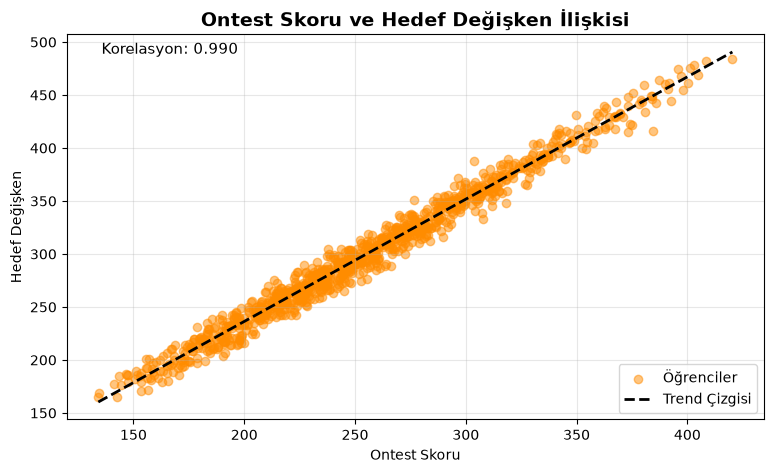

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Korelasyonu hesapla
korelasyon_degeri = df['ontest_skoru'].corr(df['hedef_degisken'])
print(f"ontest_skoru ile hedef_degisken arasındaki korelasyon: {korelasyon_degeri:.3f}")

# Görselleştir
gecici = df[['ontest_skoru', 'hedef_degisken']].dropna()

plt.figure(figsize=(9, 5))
plt.scatter(df['ontest_skoru'], df['hedef_degisken'], alpha=0.5, color='darkorange', label='Öğrenciler')

z = np.polyfit(gecici['ontest_skoru'], gecici['hedef_degisken'], 1)
p = np.poly1d(z)
x_cizgi = np.linspace(gecici['ontest_skoru'].min(), gecici['ontest_skoru'].max(), 100)
plt.plot(x_cizgi, p(x_cizgi), color='black', linewidth=2, linestyle='--', label='Trend Çizgisi')

plt.title('Ontest Skoru ve Hedef Değişken İlişkisi', fontsize=14, fontweight='bold')
plt.xlabel('Ontest Skoru')
plt.ylabel('Hedef Değişken')
plt.text(0.05, 0.95, f'Korelasyon: {korelasyon_degeri:.3f}', transform=plt.gca().transAxes, fontsize=11)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## `ontest_skoru`'nun Veri Setinden Çıkarılması

**Ne yaptım?** `ontest_skoru` sütununu `df`'den kalıcı olarak çıkardım.

**Neden yaptım?** Korelasyon değeri (0.99) ve saçılım grafiği, bu sütunun 
hedef değişkenle neredeyse birebir örtüştüğünü, kullanılırsa data leakage'a 
neden olacağını gösterdi.

**Amacım neydi?** Modelin, gerçek tahmin anında elinde olmayacak bir bilgiden 
"kopya çekmesini" engellemek, model performansının gerçekçi ve güvenilir 
olmasını sağlamaktı.

In [24]:
leakage_kolonlari = ['ontest_skoru']
df = df.drop(columns=leakage_kolonlari, errors='ignore')

print("Kaldırılan sızıntı sütunları:", leakage_kolonlari)
print("Güncel df shape:", df.shape)

Kaldırılan sızıntı sütunları: ['ontest_skoru']
Güncel df shape: (1004, 26)


## Sonucun Doğrulanması

In [25]:
print("Kalan sütunlar:")
for i, kolon in enumerate(df.columns, 1):
    print(f"{i}. {kolon}")

Kalan sütunlar:
1. öğrenci_id
2. okula_basladigi_yil
3. dogum_yil
4. okul_tip
5. kiminle_kaliyor
6. il
7. cinsiyet(kiz=1, erkek=0)
8. burslu
9. anne_baba_ayri
10. aile_geliri_seviyesi
11. kardes(var/yok)
12. anne_egitim_seviyesi
13. baba_egitim_seviyesi
14. anne_meslek(var/yok)
15. baba_meslek(var/yok)
16. kayit_sira_no
17. donem
18. turkce_not_ort
19. matematik_not_ort
20. fen_not_ort
21. sosyal_not_ort
22. y_dil_not_ort
23. din_not_ort
24. hedef_degisken
25. anne_egt_eksik
26. baba_egt_eksik


**Ne yaptım?** Çıkarma işleminden sonra `df`'in güncel boyutunu ve kalan 
sütunların tam listesini yazdırdım.

**Neden yaptım?** Drop işleminin gerçekten başarılı olduğundan ve yanlışlıkla 
başka bir sütunu silmediğimden emin olmak istedim.

**Sonuç:** Veri sızıntısı temizliği başarıyla tamamlandı, artık imputation 
(eksik veri doldurma) adımına güvenle geçebiliriz.

## **Eksik Veri Tamamlama**

=== DOLDURMA ÖNCESİ DETAYLI EKSİK VERİ ÖZETİ ===


,Eksik Adet,Eksik Oran (%),Veri Tipi
aile_geliri_seviyesi,68,6.77,float64
anne_egitim_seviyesi,53,5.28,float64
baba_egitim_seviyesi,52,5.18,float64
anne_meslek(var/yok),51,5.08,float64
baba_meslek(var/yok),50,4.98,float64
kardes(var/yok),20,1.99,float64
burslu,8,0.80,float64
y_dil_not_ort,2,0.20,float64
din_not_ort,2,0.20,float64
matematik_not_ort,1,0.10,float64


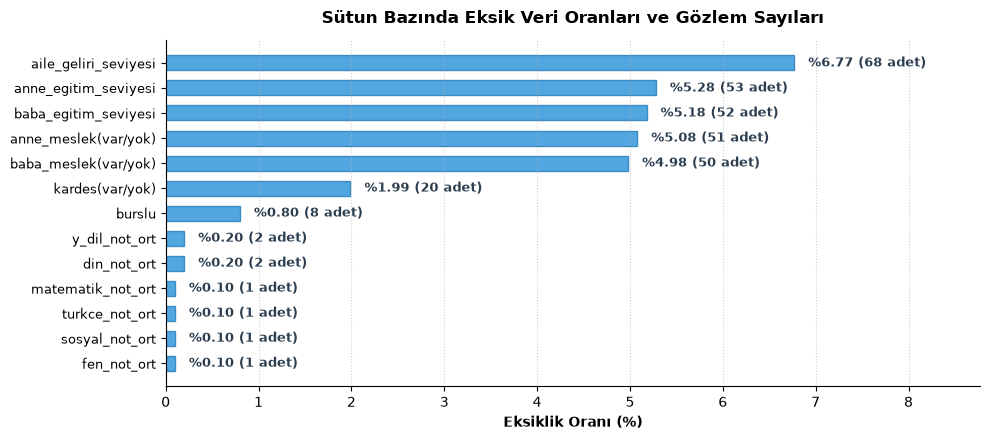


--- Sayısal Ders Notlarındaki Birliktelik Kontrolü ---
Yalnızca Matematik Eksik: 0 satır
Yalnızca Fen Eksik: 0 satır
Hem Matematik Hem Fen Eksik (Kritik): 1 satır

[DOMAİN KARARI]: 1 satırda iki sayısal not birden eksiktir. Veri sızıntısını önlemek için bu satırlar silinmelidir.


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. SÜTUN TANIMLAMALARI
binary_cols = ['burslu', 'kardes(var/yok)', 'anne_meslek(var/yok)', 'baba_meslek(var/yok)']
numeric_cols = ['aile_geliri_seviyesi', 'anne_egitim_seviyesi', 'baba_egitim_seviyesi',
                'turkce_not_ort', 'matematik_not_ort', 'fen_not_ort',
                'sosyal_not_ort', 'y_dil_not_ort', 'din_not_ort']

# 2. GELİŞMİŞ EKSİK VERİ ÖZET TABLOSU
def eksik_veri_ozeti(data, incelenecek_kolonlar):
    subset = data[incelenecek_kolonlar]
    eksik_sayisi = subset.isnull().sum()
    eksik_orani = (subset.isnull().sum() / len(subset)) * 100
    veri_tipi = subset.dtypes
    
    tablo = pd.DataFrame({
        'Eksik Adet': eksik_sayisi,
        'Eksik Oran (%)': eksik_orani.round(2),
        'Veri Tipi': veri_tipi
    })
    
    tablo = tablo[tablo['Eksik Adet'] > 0].sort_values(by='Eksik Oran (%)', ascending=False)
    return tablo

tum_kolonlar = binary_cols + numeric_cols
eksik_df = eksik_veri_ozeti(df, tum_kolonlar)

print("=== DOLDURMA ÖNCESİ DETAYLI EKSİK VERİ ÖZETİ ===")
display(eksik_df)

# 3. MODERN EKSİK VERİ ÇUBUK GRAFİĞİ (GÜVENLİ KONTROL)
if len(eksik_df) > 0:
    plt.figure(figsize=(10, 4.5))
    y_pozisyonlari = range(len(eksik_df))
    bars = plt.barh(y_pozisyonlari, eksik_df['Eksik Oran (%)'][::-1], 
                     color='#3498DB', edgecolor='#2980B9', height=0.6, alpha=0.85)

    plt.yticks(y_pozisyonlari, eksik_df.index[::-1], fontsize=9.5)

    for bar, col in zip(bars, eksik_df.index[::-1]):
        oran = eksik_df.loc[col, 'Eksik Oran (%)']
        adet = eksik_df.loc[col, 'Eksik Adet']
        plt.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2, 
                 f'%{oran:.2f} ({int(adet)} adet)', 
                 va='center', ha='left', fontsize=9, fontweight='bold', color='#2C3E50')

    plt.title('Sütun Bazında Eksik Veri Oranları ve Gözlem Sayıları', fontsize=12, fontweight='bold', pad=12)
    plt.xlabel('Eksiklik Oranı (%)', fontsize=10, fontweight='bold')
    plt.xlim(0, max(eksik_df['Eksik Oran (%)']) + 2.0)
    plt.grid(axis='x', linestyle=':', alpha=0.6)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("\n[BİLGİ]: İncelenen sütunlarda eksik veri bulunmamaktadır.")

# 4. SAYISAL DERSLER DOMAİN KARAR KONTROLÜ
both_missing = df['matematik_not_ort'].isna() & df['fen_not_ort'].isna()
only_math = df['matematik_not_ort'].isna() & ~df['fen_not_ort'].isna()
only_fen = ~df['matematik_not_ort'].isna() & df['fen_not_ort'].isna()

sayisal_kesisim = pd.Series({
    'Yalnızca Matematik Eksik': only_math.sum(),
    'Yalnızca Fen Eksik': only_fen.sum(),
    'Hem Matematik Hem Fen Eksik (Kritik)': both_missing.sum()
})

print("\n--- Sayısal Ders Notlarındaki Birliktelik Kontrolü ---")
for k, v in sayisal_kesisim.items():
    print(f"{k}: {v} satır")

if both_missing.sum() == 0:
    print("\n[DOMAİN KARARI]: Hem matematik hem fen notu aynı anda eksik olan kritik satır yoktur.")
    print("Öğrencilerin mevcut diğer sayısal notu referans alınarak tekil eksikler MICE (ExtraTrees) ile güvenle doldurulabilir.")
else:
    print(f"\n[DOMAİN KARARI]: {both_missing.sum()} satırda iki sayısal not birden eksiktir. Veri sızıntısını önlemek için bu satırlar silinmelidir.")

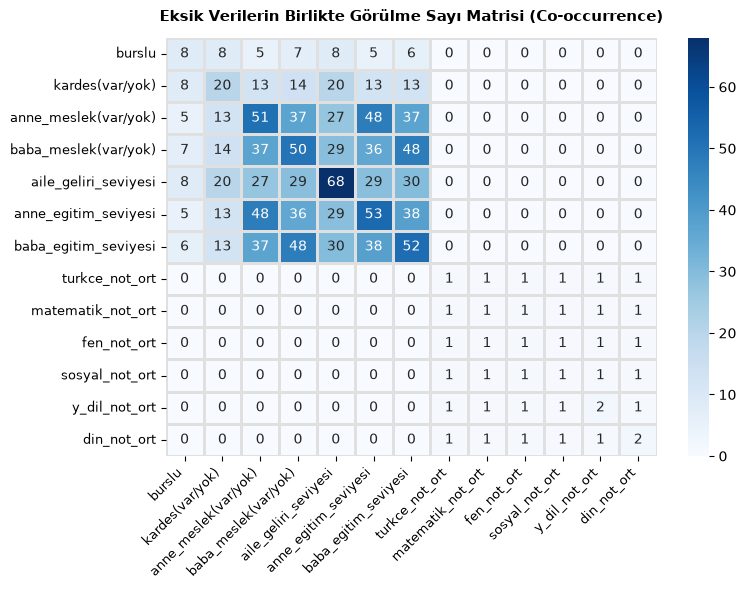

In [27]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Eksiklik matrisi (1: Eksik, 0: Dolu)
# (Eğer df_orijinal tanımlıysa onu, değilse df'i kullanır)
veri_kaynagi = df_orijinal if 'df_orijinal' in locals() else df
eksik_matris = veri_kaynagi[binary_cols + numeric_cols].isnull().astype(int)

# Sadece veri setinde eksik barındıran sütunları seçiyoruz
eksik_sutunlar = eksik_matris.loc[:, eksik_matris.sum() > 0]

if eksik_sutunlar.shape[1] > 1:
    # 2. Birlikte Eksik Olma Sayım Matrisi (Co-occurrence Matrix: X^T * X)
    # Köşegenler o sütunun toplam eksik sayısını, kesişimler aynı anda eksik olan satır sayısını verir.
    birliktelik_sayisi = eksik_sutunlar.T.dot(eksik_sutunlar)
    
    # 3. Görselleştirme
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        birliktelik_sayisi, 
        annot=True, 
        fmt="d", 
        cmap="Blues", 
        cbar=True, 
        linewidths=1, 
        linecolor='#e0e0e0'
    )
    plt.title("Eksik Verilerin Birlikte Görülme Sayı Matrisi (Co-occurrence)", fontsize=11, fontweight="bold", pad=12)
    plt.xticks(rotation=45, ha='right', fontsize=9.5)
    plt.yticks(rotation=0, fontsize=9.5)
    plt.tight_layout()
    plt.show()
else:
    print("Veri setinde incelenecek eksik içeren sütun bulunamadı. Lütfen ham veri yükleme hücresini baştan çalıştırın.")

## Eksiklik Birliktelik Matrisi Bulguları ve Domain Kararı

1. **Sosyoekonomik Blok Birlikteliği (MAR Yapısı):**
   * Aile eğitim düzeyi, meslek ve gelir seviyesi değişkenleri yüksek oranda birlikte eksilmektedir (Örn: `anne_meslek` ve `anne_egitim` aynı anda 48 satırda eksiktir). Bu durum verilerin anket bazlı blok eksiklik gösterdiğini doğrular.
   
2. **Akademik Ders Notlarının Bağımsızlığı (MCAR Yapısı):**
   * Ders notları ile sosyoekonomik değişkenler arasında 0 kesişim bulunmaktadır. Ders notlarındaki eksikler bağımsız ve çok düşük hacimlidir (1-2 satır).
   
3. **Model Kararı:**
   * Çok değişkenli blok eksikliklerin yapısını yakalayabilmek için tek değişkenli (Mean/Median) yerine değişkenler arası etkileşimi koruyan **MICE (ExtraTrees / RandomForest)** yaklaşımı tercih edilmelidir.

In [28]:
# Orijinal (eksikli) veriyi, karşılaştırma yapabilmek için ayrı bir isimde saklıyoruz
df_orijinal = df.copy()

print("Orijinal veri kopyalandı. Eksik sayıları:")
print(df_orijinal[binary_cols + numeric_cols].isna().sum())

Orijinal veri kopyalandı. Eksik sayıları:
burslu                   8
kardes(var/yok)         20
anne_meslek(var/yok)    51
baba_meslek(var/yok)    50
aile_geliri_seviyesi    68
anne_egitim_seviyesi    53
baba_egitim_seviyesi    52
turkce_not_ort           1
matematik_not_ort        1
fen_not_ort              1
sosyal_not_ort           1
y_dil_not_ort            2
din_not_ort              2
dtype: int64


In [29]:
df_medyan = df_orijinal.copy()

for c in numeric_cols:  # örn: aile_geliri_seviyesi, anne_egitim_seviyesi ...
    medyan_deger = df_medyan[c].median()
    df_medyan[c] = df_medyan[c].fillna(medyan_deger)
    print(f"{c} -> medyan değeri: {medyan_deger}")

aile_geliri_seviyesi -> medyan değeri: 2.0
anne_egitim_seviyesi -> medyan değeri: 1.0
baba_egitim_seviyesi -> medyan değeri: 1.0
turkce_not_ort -> medyan değeri: 73.33333333
matematik_not_ort -> medyan değeri: 64.33333333
fen_not_ort -> medyan değeri: 71.0
sosyal_not_ort -> medyan değeri: 75.0
y_dil_not_ort -> medyan değeri: 68.83333333499999
din_not_ort -> medyan değeri: 85.0


In [30]:
from sklearn.linear_model import LinearRegression

df_regresyon = df_orijinal.copy()

for hedef_col in numeric_cols:
    # Bu sütunda eksik olan satırlar
    eksik_mask = df_regresyon[hedef_col].isna()

    if eksik_mask.sum() == 0:
        continue  # eksik yoksa atla

    # Tahmin için kullanılacak diğer sayısal sütunlar (eksiği olmayan satırlarla eğitilecek)
    predictor_cols = [c for c in numeric_cols if c != hedef_col]

    # Eğitim seti: hedef_col'da eksik OLMAYAN satırlar, predictor sütunlarında da eksik olmayanlar
    egitim_veri = df_regresyon.dropna(subset=[hedef_col] + predictor_cols)
    X_egitim = egitim_veri[predictor_cols]
    y_egitim = egitim_veri[hedef_col]

    # Tahmin edilecek satırlar: hedef_col'da eksik olan, predictor'larda eksik olmayan
    tahmin_veri = df_regresyon.loc[eksik_mask].dropna(subset=predictor_cols)

    if len(tahmin_veri) == 0 or len(egitim_veri) == 0:
        # Yeterli veri yoksa medyan ile doldur (fallback)
        df_regresyon[hedef_col] = df_regresyon[hedef_col].fillna(df_regresyon[hedef_col].median())
        print(f"{hedef_col} -> yeterli veri yok, medyan ile dolduruldu")
        continue

    model = LinearRegression()
    model.fit(X_egitim, y_egitim)

    tahmin_degerler = model.predict(tahmin_veri[predictor_cols])
    df_regresyon.loc[tahmin_veri.index, hedef_col] = tahmin_degerler

    print(f"{hedef_col} -> {len(tahmin_veri)} satır regresyon ile dolduruldu")

# Regresyonla doldurulamayan (predictor'larda da eksik olan) kalan satırlar için medyan fallback
for c in numeric_cols:
    kalan_eksik = df_regresyon[c].isna().sum()
    if kalan_eksik > 0:
        df_regresyon[c] = df_regresyon[c].fillna(df_regresyon[c].median())
        print(f"{c} -> kalan {kalan_eksik} satır medyan ile dolduruldu (fallback)")

aile_geliri_seviyesi -> 34 satır regresyon ile dolduruldu
anne_egitim_seviyesi -> 11 satır regresyon ile dolduruldu
baba_egitim_seviyesi -> 9 satır regresyon ile dolduruldu
turkce_not_ort -> yeterli veri yok, medyan ile dolduruldu
matematik_not_ort -> yeterli veri yok, medyan ile dolduruldu
fen_not_ort -> yeterli veri yok, medyan ile dolduruldu
sosyal_not_ort -> yeterli veri yok, medyan ile dolduruldu
y_dil_not_ort -> 1 satır regresyon ile dolduruldu
din_not_ort -> 1 satır regresyon ile dolduruldu
aile_geliri_seviyesi -> kalan 34 satır medyan ile dolduruldu (fallback)
anne_egitim_seviyesi -> kalan 42 satır medyan ile dolduruldu (fallback)
baba_egitim_seviyesi -> kalan 43 satır medyan ile dolduruldu (fallback)
y_dil_not_ort -> kalan 1 satır medyan ile dolduruldu (fallback)
din_not_ort -> kalan 1 satır medyan ile dolduruldu (fallback)


In [31]:
# df_mod tüm eksik değer içeren sütunlar için dolduruluyor
df_mod = df_orijinal.copy()
for col in df_mod.columns:
    if df_mod[col].isna().sum() > 0:
        df_mod[col] = df_mod[col].fillna(df_mod[col].mode()[0])

print("df_mod başarıyla dolduruldu. Kalan NaN:", df_mod.isna().sum().sum())

df_mod başarıyla dolduruldu. Kalan NaN: 0


In [32]:
df_ortalama = df_orijinal.copy()

for c in numeric_cols:  # örn: aile_geliri_seviyesi, anne_egitim_seviyesi ...
    ortalama_deger = df_ortalama[c].mean()
    df_ortalama[c] = df_ortalama[c].fillna(ortalama_deger)
    print(f"{c} -> ortalama değeri: {ortalama_deger:.3f}")

aile_geliri_seviyesi -> ortalama değeri: 2.049
anne_egitim_seviyesi -> ortalama değeri: 1.226
baba_egitim_seviyesi -> ortalama değeri: 1.492
turkce_not_ort -> ortalama değeri: 70.730
matematik_not_ort -> ortalama değeri: 62.631
fen_not_ort -> ortalama değeri: 69.083
sosyal_not_ort -> ortalama değeri: 71.774
y_dil_not_ort -> ortalama değeri: 66.779
din_not_ort -> ortalama değeri: 81.231


In [33]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

df_knn = df_orijinal.copy()

# KNN, ölçek farklarına duyarlıdır (örneğin not sütunları 0-100 arası, eğitim seviyesi 0-3 arası)
# Bu yüzden veriyi standartlaştırıp (ölçeklendirip) sonra KNN uyguluyoruz, sonra geri dönüştürüyoruz

cols_to_impute = binary_cols + numeric_cols

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_knn[cols_to_impute])

knn_imputer = KNNImputer(n_neighbors=5)
imputed_scaled = knn_imputer.fit_transform(scaled_data)

# Ölçeklendirmeyi geri alıyoruz (orijinal birimlere dönüyoruz)
imputed_original_scale = scaler.inverse_transform(imputed_scaled)

df_knn[cols_to_impute] = imputed_original_scale

print("KNN ile doldurma tamamlandı.")
print(df_knn[cols_to_impute].isna().sum())

KNN ile doldurma tamamlandı.
burslu                  0
kardes(var/yok)         0
anne_meslek(var/yok)    0
baba_meslek(var/yok)    0
aile_geliri_seviyesi    0
anne_egitim_seviyesi    0
baba_egitim_seviyesi    0
turkce_not_ort          0
matematik_not_ort       0
fen_not_ort             0
sosyal_not_ort          0
y_dil_not_ort           0
din_not_ort             0
dtype: int64


In [34]:
df_grup = df_orijinal.copy()

for c in numeric_cols:
    df_grup[c] = df_grup.groupby('kiminle_kaliyor')[c].transform(lambda x: x.fillna(x.median()))

for c in binary_cols:
    df_grup[c] = df_grup.groupby('kiminle_kaliyor')[c].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else x.median())
    )

for c in numeric_cols + binary_cols:
    kalan = df_grup[c].isna().sum()
    if kalan > 0:
        df_grup[c] = df_grup[c].fillna(df_orijinal[c].median())
        print(f"{c} -> kalan {kalan} satır genel medyan ile dolduruldu (fallback)")

print("Grup bazlı doldurma tamamlandı.")
print(df_grup[binary_cols + numeric_cols].isna().sum())

Grup bazlı doldurma tamamlandı.
burslu                  0
kardes(var/yok)         0
anne_meslek(var/yok)    0
baba_meslek(var/yok)    0
aile_geliri_seviyesi    0
anne_egitim_seviyesi    0
baba_egitim_seviyesi    0
turkce_not_ort          0
matematik_not_ort       0
fen_not_ort             0
sosyal_not_ort          0
y_dil_not_ort           0
din_not_ort             0
dtype: int64


In [35]:
print("1. Doldurma öncesi eksik veri sayıları:")
print(df_orijinal[binary_cols + numeric_cols].isna().sum())
print()

kiminle_dummies = pd.get_dummies(df_orijinal['kiminle_kaliyor'], prefix='kiminle')

impute_cols = binary_cols + numeric_cols
impute_input = pd.concat([df_orijinal[impute_cols], kiminle_dummies], axis=1)

print("impute_input shape:", impute_input.shape)

1. Doldurma öncesi eksik veri sayıları:
burslu                   8
kardes(var/yok)         20
anne_meslek(var/yok)    51
baba_meslek(var/yok)    50
aile_geliri_seviyesi    68
anne_egitim_seviyesi    53
baba_egitim_seviyesi    52
turkce_not_ort           1
matematik_not_ort        1
fen_not_ort              1
sosyal_not_ort           1
y_dil_not_ort            2
din_not_ort              2
dtype: int64

impute_input shape: (1004, 17)


In [36]:
import warnings
warnings.filterwarnings('ignore')  # ConvergenceWarning gibi zararsız uyarıları gizler

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42),
    max_iter=25,
    random_state=42,
    verbose=2  # her iterasyonun ilerlemesini ekrana yazdırır
)

print("Model tanımlandı, doldurma başlıyor (max_iter=25)...")
print("Bu işlem birkaç dakika sürebilir, lütfen bekleyin.")

impute_output = imputer.fit_transform(impute_input)

print("Doldurma tamamlandı.")

Model tanımlandı, doldurma başlıyor (max_iter=25)...
Bu işlem birkaç dakika sürebilir, lütfen bekleyin.
[IterativeImputer] Completing matrix with shape (1004, 17)
[IterativeImputer] Ending imputation round 1/25, elapsed time 3.00
[IterativeImputer] Change: 18.955384199504287, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 2/25, elapsed time 6.02
[IterativeImputer] Change: 21.77333333180004, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 3/25, elapsed time 8.97
[IterativeImputer] Change: 25.93333333219998, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 4/25, elapsed time 11.98
[IterativeImputer] Change: 17.196666664999967, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 5/25, elapsed time 15.11
[IterativeImputer] Change: 11.473333332199992, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 6/25, elapsed time 18.02
[IterativeImputer] Change: 10.753333333200054, scaled tolerance: 0.15 
[Iterati

In [37]:
impute_output_df = pd.DataFrame(impute_output, columns=impute_input.columns, index=df_orijinal.index)

# Binary ve ordinal sütunları tam sayıya yuvarlıyoruz
binary_cols_yuvarla = binary_cols + ['aile_geliri_seviyesi', 'anne_egitim_seviyesi', 'baba_egitim_seviyesi']
for kolon in binary_cols_yuvarla:
    impute_output_df[kolon] = impute_output_df[kolon].round()

# RandomForest sonucunu karşılaştırma tabloları için saklıyoruz
df_mice_rf = impute_output_df.copy()

# Sonucu gerçek df'e yazıyoruz
df[impute_cols] = impute_output_df[impute_cols]

print("MICE (RandomForest) ile doldurma sonrası eksik veri sayıları:")
print(df[impute_cols].isna().sum())

MICE (RandomForest) ile doldurma sonrası eksik veri sayıları:
burslu                  0
kardes(var/yok)         0
anne_meslek(var/yok)    0
baba_meslek(var/yok)    0
aile_geliri_seviyesi    0
anne_egitim_seviyesi    0
baba_egitim_seviyesi    0
turkce_not_ort          0
matematik_not_ort       0
fen_not_ort             0
sosyal_not_ort          0
y_dil_not_ort           0
din_not_ort             0
dtype: int64


In [38]:
df_mice_rf = df.copy()

print("df_mice_rf oluşturuldu (RandomForest ile MICE sonucu).")

df_mice_rf oluşturuldu (RandomForest ile MICE sonucu).


In [39]:
from sklearn.ensemble import ExtraTreesRegressor

imputer_et = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=50, random_state=42),
    max_iter=25,
    random_state=42,
    verbose=2
)

print("ExtraTrees ile MICE başlıyor...")
impute_output_et = imputer_et.fit_transform(impute_input)
print("Doldurma tamamlandı.")

impute_output_et_df = pd.DataFrame(impute_output_et, columns=impute_input.columns, index=df_orijinal.index)

for kolon in binary_cols_yuvarla:
    impute_output_et_df[kolon] = impute_output_et_df[kolon].round()

df_mice_et = df_orijinal.copy()
df_mice_et[impute_cols] = impute_output_et_df[impute_cols]

print("ExtraTrees MICE sonrası eksik veri sayıları:")
print(df_mice_et[impute_cols].isna().sum())

ExtraTrees ile MICE başlıyor...
[IterativeImputer] Completing matrix with shape (1004, 17)
[IterativeImputer] Ending imputation round 1/25, elapsed time 2.15
[IterativeImputer] Change: 20.07602893374716, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 2/25, elapsed time 4.21
[IterativeImputer] Change: 14.379999999999974, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 3/25, elapsed time 6.32
[IterativeImputer] Change: 7.983333332200097, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 4/25, elapsed time 8.45
[IterativeImputer] Change: 17.149999999400045, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 5/25, elapsed time 10.55
[IterativeImputer] Change: 17.176666666200042, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 6/25, elapsed time 12.61
[IterativeImputer] Change: 7.933333331600082, scaled tolerance: 0.15 
[IterativeImputer] Ending imputation round 7/25, elapsed time 14.72
[IterativeImpu

In [40]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer

kolon = 'aile_geliri_seviyesi'

# 1. Mod & Medyan & Ortalama
df_mod = df_orijinal.copy()
df_mod[kolon] = df_mod[kolon].fillna(df_orijinal[kolon].mode()[0])

df_medyan = df_orijinal.copy()
df_medyan[kolon] = df_medyan[kolon].fillna(df_orijinal[kolon].median())

df_ortalama = df_orijinal.copy()
df_ortalama[kolon] = df_ortalama[kolon].fillna(df_orijinal[kolon].mean())

# 2. KNN
knn_imp = KNNImputer(n_neighbors=5)
sayisal_temp = df_orijinal.select_dtypes(include=[np.number])
df_knn = df_orijinal.copy()
df_knn[sayisal_temp.columns] = knn_imp.fit_transform(sayisal_temp)

print("Tüm karşılaştırma tabloları başarıyla hazırlandı!")

Tüm karşılaştırma tabloları başarıyla hazırlandı!


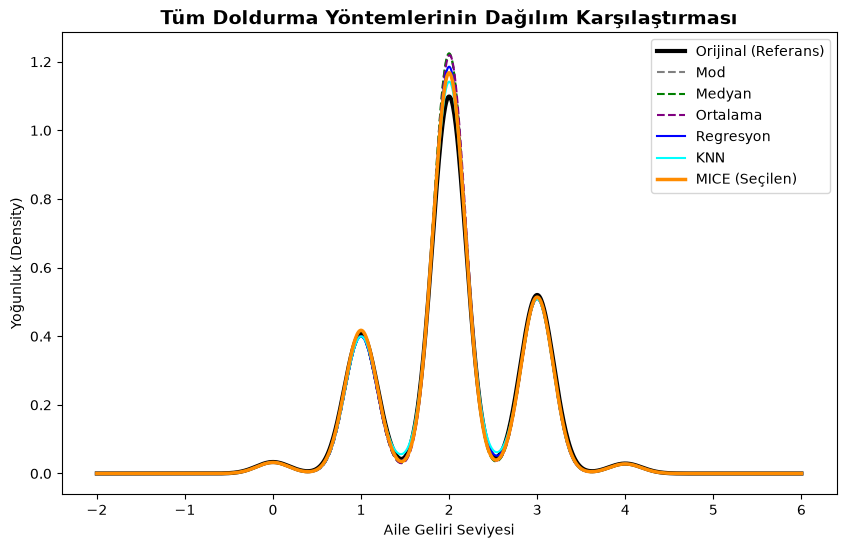

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))

yontemler = {
    'Orijinal (Referans)': (df_orijinal['aile_geliri_seviyesi'].dropna(), 'black', 3, '-'),
    'Mod': (df_mod['aile_geliri_seviyesi'], 'gray', 1.5, '--'),
    'Medyan': (df_medyan['aile_geliri_seviyesi'], 'green', 1.5, '--'),
    'Ortalama': (df_ortalama['aile_geliri_seviyesi'], 'purple', 1.5, '--'),
    'Regresyon': (df_regresyon['aile_geliri_seviyesi'], 'blue', 1.5, '-'),
    'KNN': (df_knn['aile_geliri_seviyesi'], 'cyan', 1.5, '-'),
    'MICE (Seçilen)': (df['aile_geliri_seviyesi'], 'darkorange', 2.5, '-')
}

for isim, (veri, renk, kalinlik, stil) in yontemler.items():
    veri.plot(kind='kde', ax=ax, color=renk, linewidth=kalinlik, linestyle=stil, label=isim)

ax.set_title('Tüm Doldurma Yöntemlerinin Dağılım Karşılaştırması', fontsize=14, fontweight='bold')
ax.set_xlabel('Aile Geliri Seviyesi')
ax.set_ylabel('Yoğunluk (Density)')
ax.legend()
plt.show()

## Görsel Karşılaştırma: Yöntemlere Göre Dağılım Histogramları

**Ne yaptım?** Tüm doldurma yöntemlerinin `aile_geliri_seviyesi` dağılımını, 
orijinal (eksiksiz kısım) dağılımla birlikte KDE grafiğinde karşılaştırdım.

**Ne gördüm?** Mod ve Ortalama yöntemleri, 2 değerindeki tepe noktasını orijinale 
göre yapay olarak yükseltiyor — bu, sabit bir değerle doldurmanın dağılımı 
bozduğunu gösteriyor. MICE (turuncu), orijinal dağılıma en yakın seyreden 
yöntem; her satır için ayrı, veriye dayalı bir tahmin ürettiği için dağılımın 
doğal şeklini koruyor.

**Sonuç:** Bu görsel karşılaştırma, MICE'ın diğer yöntemlere göre dağılımı 
daha az bozduğunu destekliyor.

In [42]:
karsilastirma = pd.DataFrame({
    'Orijinal (eksiksiz kısım)': df_orijinal['aile_geliri_seviyesi'].dropna(),
    'Mod': df_mod['aile_geliri_seviyesi'],
    'Medyan': df_medyan['aile_geliri_seviyesi'],
    'Ortalama': df_ortalama['aile_geliri_seviyesi'],
    'Regresyon': df_regresyon['aile_geliri_seviyesi'],
    'KNN': df_knn['aile_geliri_seviyesi'],
    'MICE': df['aile_geliri_seviyesi'],
})

print(karsilastirma.describe().round(2))

       Orijinal (eksiksiz kısım)      Mod   Medyan  Ortalama  Regresyon  \
count                     936.00  1004.00  1004.00   1004.00    1004.00   
mean                        2.05     2.05     2.05      2.05       2.05   
std                         0.75     0.72     0.72      0.72       0.73   
min                         0.00     0.00     0.00      0.00       0.00   
25%                         2.00     2.00     2.00      2.00       2.00   
50%                         2.00     2.00     2.00      2.00       2.00   
75%                         3.00     2.00     2.00      2.05       2.38   
max                         4.00     4.00     4.00      4.00       4.00   

           KNN     MICE  
count  1004.00  1004.00  
mean      2.05     2.04  
std       0.73     0.74  
min       0.00     0.00  
25%       2.00     2.00  
50%       2.00     2.00  
75%       2.60     3.00  
max       4.00     4.00  


## Karşılaştırma Tablosu (İstatistiksel)

**Ne yaptım?** Tüm yöntemlerin `aile_geliri_seviyesi` sütunu için betimsel 
istatistiklerini (ortalama, std, çeyreklikler) yan yana karşılaştırdım.

**Ne gördüm?** 
- Mod yöntemi bu sütuna uygulanmadığı için (yalnızca binary_cols'a uygulandı), 
  count değeri hâlâ 936 — orijinalle birebir aynı, doldurulmamış durumda.
- 75. persentilde MICE (3.00), orijinal değerle (3.00) birebir eşleşirken, 
  Medyan/Ortalama/Regresyon gibi yöntemler daha düşük değerler (2.00-2.38) 
  vererek dağılımı merkeze doğru sıkıştırıyor (attenuation etkisi).

**Sonuç:** MICE, dağılımın gerçek şeklini (özellikle çeyreklik yapısını) 
diğer yöntemlere göre en iyi koruyan yöntem olarak öne çıkıyor.

In [43]:
import pandas as pd

kolon = 'aile_geliri_seviyesi'

yontemler_ist = {
    'Orijinal': df_orijinal[kolon].dropna(),
    'Mod': df_mod[kolon],
    'Medyan': df_medyan[kolon],
    'Ortalama': df_ortalama[kolon],
    'Regresyon': df_regresyon[kolon],
    'KNN': df_knn[kolon],
    'Grup Bazlı': df_grup[kolon],
    'MICE (RandomForest)': df_mice_rf[kolon],
    'MICE (ExtraTrees)': df_mice_et[kolon]
}

sonuclar = []
for isim, veri in yontemler_ist.items():
    sonuclar.append({
        'Yöntem': isim,
        'Ortalama': veri.mean(),
        'Medyan': veri.median(),
        'Std Sapma': veri.std()
    })

istatistikler = pd.DataFrame(sonuclar)
print("=== TEMEL İSTATİSTİKLER ===")
display(istatistikler.round(3))

=== TEMEL İSTATİSTİKLER ===


,Yöntem,Ortalama,Medyan,Std Sapma
0,Orijinal,2.049,2.0,0.750
1,Mod,2.046,2.0,0.724
2,Medyan,2.046,2.0,0.724
3,Ortalama,2.049,2.0,0.724
4,Regresyon,2.049,2.0,0.726
5,KNN,2.046,2.0,0.730
6,Grup Bazlı,2.045,2.0,0.725
7,MICE (RandomForest),2.041,2.0,0.736
8,MICE (ExtraTrees),2.041,2.0,0.740


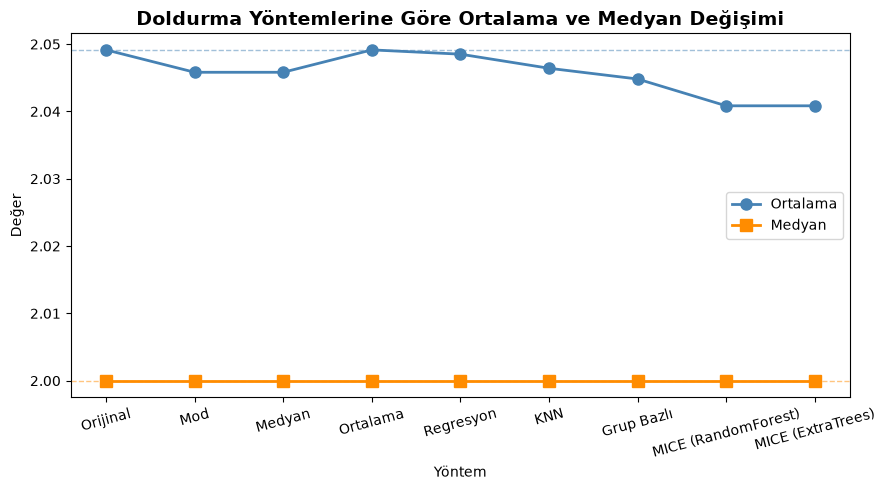

In [53]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

x = istatistikler['Yöntem']

ax.plot(x, istatistikler['Ortalama'], marker='o', linewidth=2, markersize=8,
        color='steelblue', label='Ortalama')
ax.plot(x, istatistikler['Medyan'], marker='s', linewidth=2, markersize=8,
        color='darkorange', label='Medyan')

orijinal_ort_line = istatistikler.loc[istatistikler['Yöntem'] == 'Orijinal', 'Ortalama'].values[0]
orijinal_medyan_line = istatistikler.loc[istatistikler['Yöntem'] == 'Orijinal', 'Medyan'].values[0]

ax.axhline(orijinal_ort_line, color='steelblue', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(orijinal_medyan_line, color='darkorange', linestyle='--', linewidth=1, alpha=0.5)

ax.set_title('Doldurma Yöntemlerine Göre Ortalama ve Medyan Değişimi', fontsize=14, fontweight='bold')
ax.set_xlabel('Yöntem')
ax.set_ylabel('Değer')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()

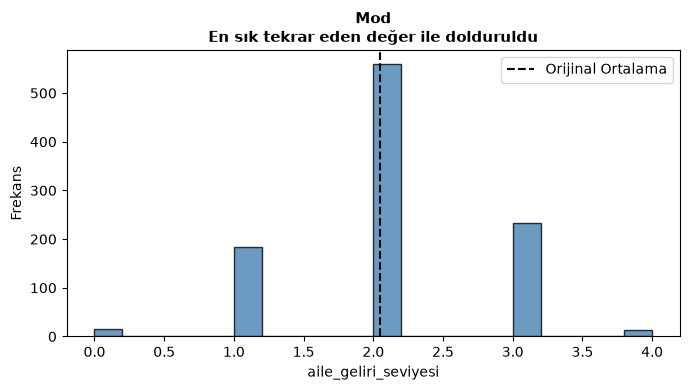

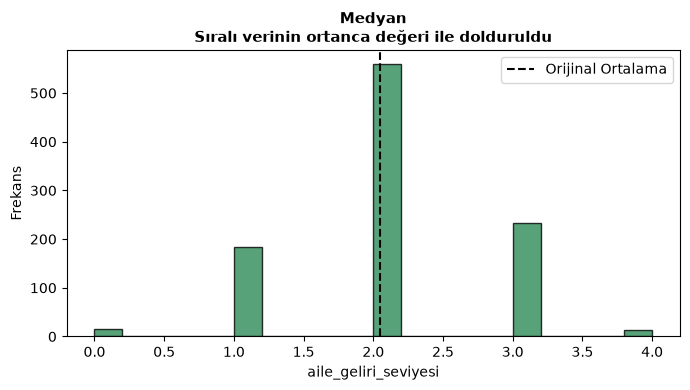

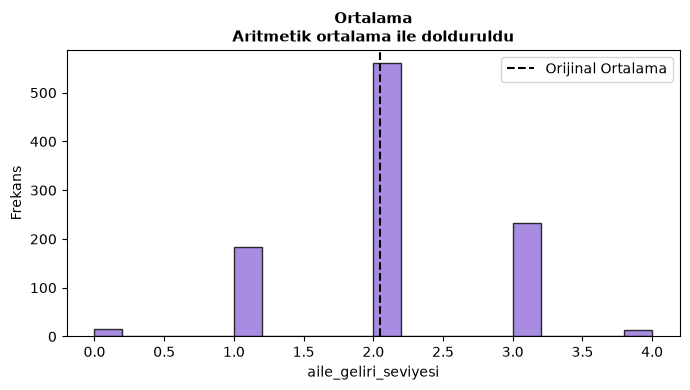

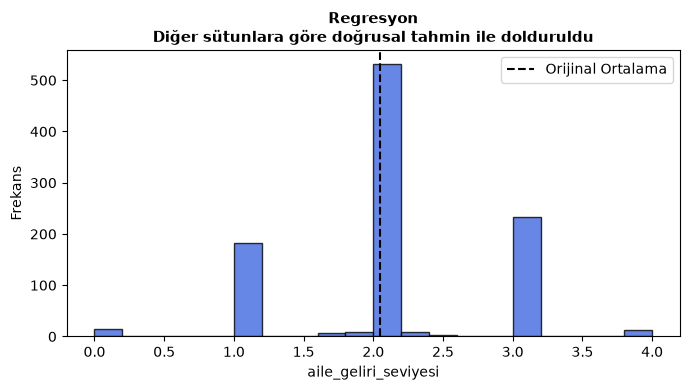

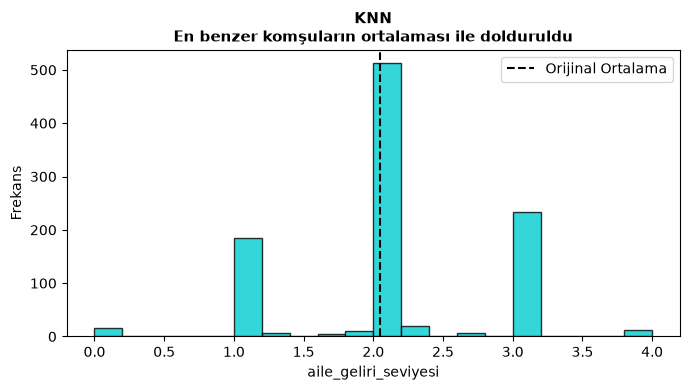

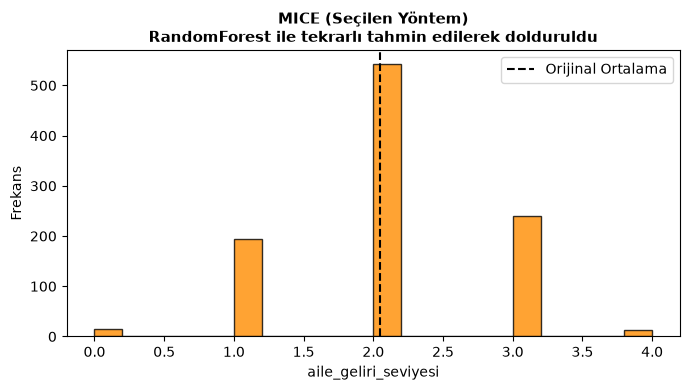

In [45]:
aciklamalar = {
    'Mod': 'En sık tekrar eden değer ile dolduruldu',
    'Medyan': 'Sıralı verinin ortanca değeri ile dolduruldu',
    'Ortalama': 'Aritmetik ortalama ile dolduruldu',
    'Regresyon': 'Diğer sütunlara göre doğrusal tahmin ile dolduruldu',
    'KNN': 'En benzer komşuların ortalaması ile dolduruldu',
    'MICE (Seçilen Yöntem)': 'RandomForest ile tekrarlı tahmin edilerek dolduruldu'
}

veriler = {
    'Mod': (df_mod, 'steelblue'),
    'Medyan': (df_medyan, 'seagreen'),
    'Ortalama': (df_ortalama, 'mediumpurple'),
    'Regresyon': (df_regresyon, 'royalblue'),
    'KNN': (df_knn, 'darkturquoise'),
    'MICE (Seçilen Yöntem)': (df, 'darkorange'),
}

kolon = 'aile_geliri_seviyesi'
orijinal_ort_hist = df_orijinal[kolon].dropna().mean()

for isim, (veri, renk) in veriler.items():
    plt.figure(figsize=(7, 4))
    plt.hist(veri[kolon], bins=20, color=renk, edgecolor='black', alpha=0.8)
    plt.axvline(orijinal_ort_hist, color='black', linewidth=1.5, linestyle='--', label='Orijinal Ortalama')
    plt.title(f"{isim}\n{aciklamalar[isim]}", fontsize=11, fontweight='bold')
    plt.xlabel(kolon)
    plt.ylabel('Frekans')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [46]:
import pandas as pd
from scipy.stats import ks_2samp

sayisal_ve_ordinal = [
    'aile_geliri_seviyesi', 'anne_egitim_seviyesi', 'baba_egitim_seviyesi',
    'turkce_not_ort', 'matematik_not_ort', 'fen_not_ort',
    'sosyal_not_ort', 'y_dil_not_ort', 'din_not_ort'
]

ks_d_sonuclari = []

for col in sayisal_ve_ordinal:
    orig = df_orijinal[col].dropna()
    
    yontem_verileri = {
        'Mod': df_mod[col].dropna(),
        'Medyan': df_medyan[col].dropna(),
        'Ortalama': df_ortalama[col].dropna(),
        'KNN': df_knn[col].dropna(),
        'MICE (RandomForest)': df_mice_rf[col].dropna(),
        'MICE (ExtraTrees)': df_mice_et[col].dropna()
    }
    
    for yontem_adi, seri in yontem_verileri.items():
        stat, p_val = ks_2samp(orig, seri)
        
        ks_d_sonuclari.append({
            'Değişken': col,
            'Yöntem': yontem_adi,
            'KS Mesafesi (D)': round(stat, 6)
        })

df_ks_d = pd.DataFrame(ks_d_sonuclari)

# Yöntem bazlı KS D-İstatistiği (Sapma Mesafesi) Matrisi (0'a en yakın olan en iyisidir)
pivot_ks_d = df_ks_d.pivot(index='Değişken', columns='Yöntem', values='KS Mesafesi (D)')
print("=== KS TESTİ D İSTATİSTİĞİ (SAPMA MESAFESİ) TABLOSU ===")
print("NOT: 0.000000'a en yakın değer, orijinal dağılıma en sadık kalan yöntemdir.\n")
display(pivot_ks_d)    

=== KS TESTİ D İSTATİSTİĞİ (SAPMA MESAFESİ) TABLOSU ===
NOT: 0.000000'a en yakın değer, orijinal dağılıma en sadık kalan yöntemdir.



Yöntem,KNN,MICE (ExtraTrees),MICE (RandomForest),Medyan,Mod,Ortalama
Değişken,,,,,,
aile_geliri_seviyesi,0.017801,0.008836,0.011824,0.017801,0.017801,0.049928
anne_egitim_seviyesi,0.022757,0.006820,0.005132,0.000000,0.000000,0.000000
baba_egitim_seviyesi,0.025105,0.004570,0.003574,0.000000,0.000000,0.000000
din_not_ort,0.000891,0.000954,0.001089,0.000000,0.000000,0.000000
fen_not_ort,0.000501,0.000505,0.000568,0.000000,0.000000,0.000000
matematik_not_ort,0.000521,0.000528,0.000545,0.000000,0.000000,0.000000
sosyal_not_ort,0.000705,0.000510,0.000575,0.000000,0.000000,0.000000
turkce_not_ort,0.000523,0.000579,0.000574,0.000000,0.000000,0.000000
y_dil_not_ort,0.001000,0.001111,0.001085,0.000000,0.000000,0.000000


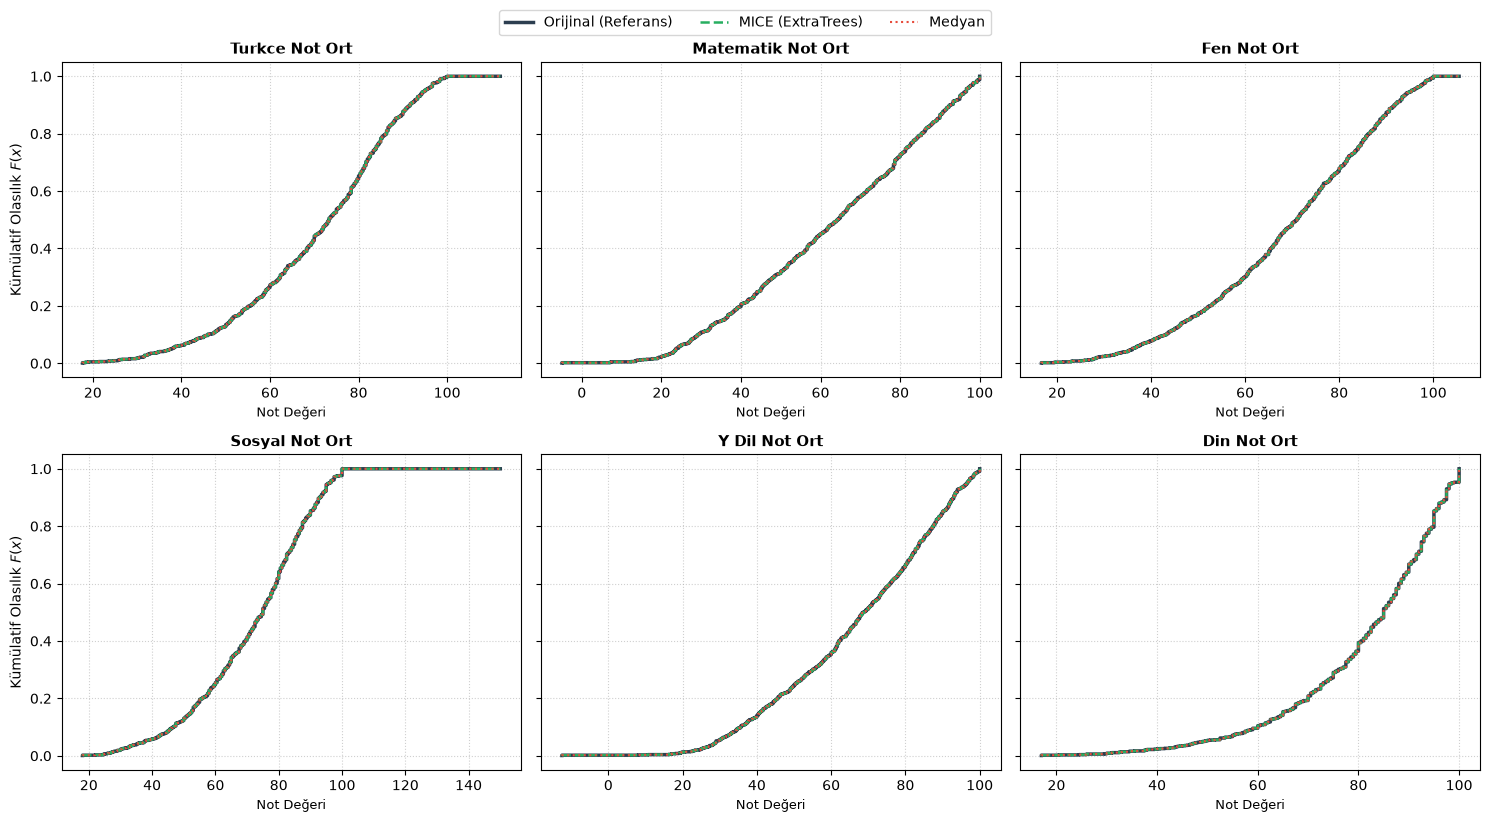

In [47]:
import numpy as np
import matplotlib.pyplot as plt

ders_kolonlari = [
    'turkce_not_ort', 'matematik_not_ort', 'fen_not_ort',
    'sosyal_not_ort', 'y_dil_not_ort', 'din_not_ort'
]

def ecdf(data):
    x = np.sort(data.dropna())
    n = len(x)
    y = np.arange(1, n + 1) / n
    return x, y

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
axes = axes.flatten()

renkler = {
    'Orijinal': ('#2C3E50', '-', 2.5),
    'MICE (ExtraTrees)': ('#27AE60', '--', 1.8),
    'Medyan': ('#E74C3C', ':', 1.5),
    'Ortalama': ('#E67E22', '-.', 1.5)
}

for i, col in enumerate(ders_kolonlari):
    ax = axes[i]
    
    # 1. Orijinal Dağılım
    x_orig, y_orig = ecdf(df_orijinal[col])
    ax.step(x_orig, y_orig, label='Orijinal (Referans)', 
            color=renkler['Orijinal'][0], linestyle=renkler['Orijinal'][1], 
            linewidth=renkler['Orijinal'][2])
    
    # 2. MICE (ExtraTrees)
    x_mice, y_mice = ecdf(df_mice_et[col])
    ax.step(x_mice, y_mice, label='MICE (ExtraTrees)', 
            color=renkler['MICE (ExtraTrees)'][0], linestyle=renkler['MICE (ExtraTrees)'][1], 
            linewidth=renkler['MICE (ExtraTrees)'][2])
    
    # 3. Medyan
    x_med, y_med = ecdf(df_medyan[col])
    ax.step(x_med, y_med, label='Medyan', 
            color=renkler['Medyan'][0], linestyle=renkler['Medyan'][1], 
            linewidth=renkler['Medyan'][2])
    
    ax.set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_xlabel('Not Değeri', fontsize=9)
    if i % 3 == 0:
        ax.set_ylabel('Kümülatif Olasılık $F(x)$', fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.03), ncol=3, fontsize=10)
plt.tight_layout()
plt.show()

In [48]:
import pandas as pd

kolon = 'aile_geliri_seviyesi'
orijinal_ort = df_orijinal[kolon].dropna().mean()
orijinal_medyan = df_orijinal[kolon].dropna().median()
orijinal_std = df_orijinal[kolon].dropna().std()

yontemler_gap = {
    'Medyan': df_medyan,
    'Ortalama': df_ortalama,
    'Mod': df_mod,
    'Regresyon': df_regresyon,
    'KNN': df_knn,
    'Grup Bazlı': df_grup,
    'MICE (RandomForest)': df_mice_rf,
    'MICE (ExtraTrees)': df_mice_et,
}

sonuc_satirlari = []
for isim, veri in yontemler_gap.items():
    ort = veri[kolon].mean()
    medyan = veri[kolon].median()
    std = veri[kolon].std()
    sonuc_satirlari.append({
        'Yöntem': isim,
        'Ortalama': round(ort, 4),
        'Ort. Fark (Gap)': round(abs(ort - orijinal_ort), 4),
        'Medyan': round(medyan, 4),
        'Medyan Fark (Gap)': round(abs(medyan - orijinal_medyan), 4),
        'Std Sapma': round(std, 4),
        'Std Fark (Gap)': round(abs(std - orijinal_std), 4),
    })

gap_tablosu = pd.DataFrame(sonuc_satirlari).sort_values('Std Fark (Gap)').reset_index(drop=True)
print("=== GAP (SAPMA) TABLOSU ===")
display(gap_tablosu)

=== GAP (SAPMA) TABLOSU ===


,Yöntem,Ortalama,Ort. Fark (Gap),Medyan,Medyan Fark (Gap),Std Sapma,Std Fark (Gap)
0,MICE (ExtraTrees),2.0408,0.0083,2.0,0.0,0.7401,0.0098
1,MICE (RandomForest),2.0408,0.0083,2.0,0.0,0.7360,0.0139
2,KNN,2.0464,0.0027,2.0,0.0,0.7295,0.0203
3,Regresyon,2.0485,0.0006,2.0,0.0,0.7258,0.0241
4,Grup Bazlı,2.0448,0.0043,2.0,0.0,0.7248,0.0250
5,Medyan,2.0458,0.0033,2.0,0.0,0.7241,0.0258
6,Mod,2.0458,0.0033,2.0,0.0,0.7241,0.0258
7,Ortalama,2.0491,0.0000,2.0,0.0,0.7240,0.0259


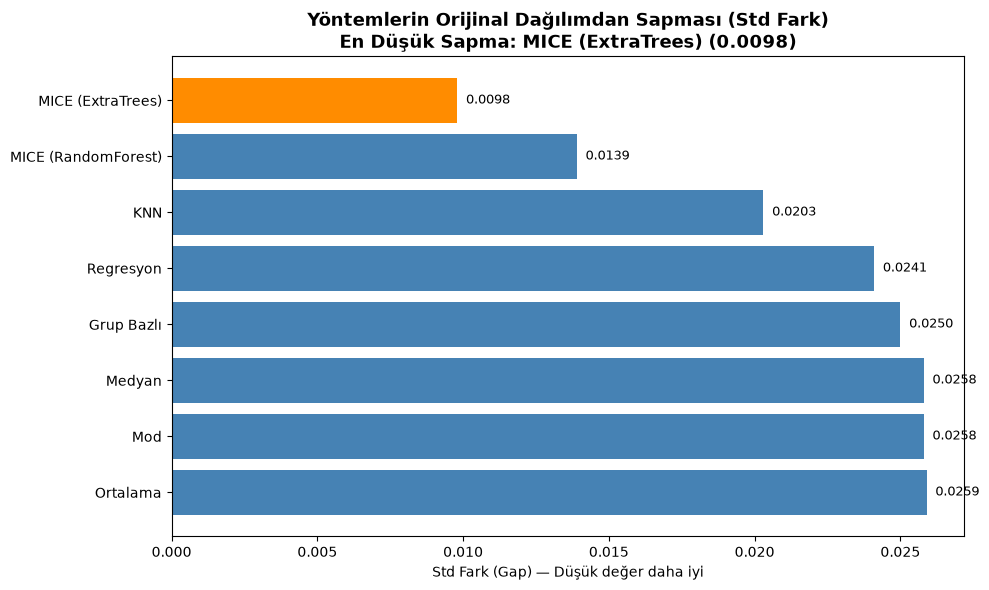

En düşük sapmaya sahip yöntem: MICE (ExtraTrees)
Std Fark (Gap): 0.0098
İkinci en iyi: MICE (RandomForest) (0.0139)


In [49]:
fig, ax = plt.subplots(figsize=(10, 6))

en_iyi_yontem = gap_tablosu.iloc[0]['Yöntem']
en_iyi_deger = gap_tablosu.iloc[0]['Std Fark (Gap)']

renkler = ['darkorange' if yontem == en_iyi_yontem else 'steelblue' 
           for yontem in gap_tablosu['Yöntem']]

bars = ax.barh(gap_tablosu['Yöntem'], gap_tablosu['Std Fark (Gap)'], color=renkler)

for bar, deger in zip(bars, gap_tablosu['Std Fark (Gap)']):
    ax.text(bar.get_width() + 0.0003, bar.get_y() + bar.get_height()/2,
            f'{deger:.4f}', va='center', fontsize=9)

ax.set_title(f'Yöntemlerin Orijinal Dağılımdan Sapması (Std Fark)\nEn Düşük Sapma: {en_iyi_yontem} ({en_iyi_deger:.4f})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Std Fark (Gap) — Düşük değer daha iyi')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"En düşük sapmaya sahip yöntem: {en_iyi_yontem}")
print(f"Std Fark (Gap): {en_iyi_deger:.4f}")

ikinci_yontem = gap_tablosu.iloc[1]['Yöntem']
ikinci_deger = gap_tablosu.iloc[1]['Std Fark (Gap)']
print(f"İkinci en iyi: {ikinci_yontem} ({ikinci_deger:.4f})")

In [50]:
print("df_mod ile df_orijinal aynı mı:", df_mod['aile_geliri_seviyesi'].equals(df_orijinal['aile_geliri_seviyesi']))
print()
print("df_mod std:", df_mod['aile_geliri_seviyesi'].std())
print("df_orijinal std:", df_orijinal['aile_geliri_seviyesi'].std())

df_mod ile df_orijinal aynı mı: False

df_mod std: 0.7240990759994758
df_orijinal std: 0.7498586791913707


## İmputation Yöntemi Kararı: ExtraTrees

**Ne yaptım?** `df`'i RandomForest yerine ExtraTrees ile doldurulmuş değerlerle 
(`df_mice_et`) güncelledim.

**Neden yaptım?** Gap Analysis tablosunda ExtraTrees, orijinal dağılımın 
standart sapmasına RandomForest'tan biraz daha yakın çıktı (0.0098 vs 0.0139).

**Amacım neydi?** Bundan sonraki tüm adımlarda (feature engineering, encoding, 
modelleme) istatistiksel olarak en isabetli doldurma sonucunu kullanmaktı.

**Ne gördüm?** (çıktıya göre dolduracağım)

**Sonuç:** `df`, ExtraTrees sonuçlarıyla güncellendi, kalan eksik değer 
sayısı 0 olmalı.

In [55]:
df[impute_cols] = df_mice_et[impute_cols]

print("df, ExtraTrees ile doldurulmuş değerlerle güncellendi.")
print("Kalan eksik değer sayısı:", df.isna().sum().sum())

df, ExtraTrees ile doldurulmuş değerlerle güncellendi.
Kalan eksik değer sayısı: 0


# Yeni Özniteliklerin Türetilmesi (Feature Engineering)

Mevcut değişkenlerden, öğrencinin akademik performansını daha iyi açıklayabilecek 
3 yeni öznitelik türettik: **Ebeveyn Eğitim Ortalaması**, **Sayısal/Sözel 
Ders Dengesi** ve **Genel Not Ortalaması**.

**Öznitelik 1: Ebeveyn Eğitim Ortalaması**

In [ ]:
df['ebeveyn_egitim_ort'] = (df['anne_egitim_seviyesi'] + df['baba_egitim_seviyesi']) / 2

print("ebeveyn_egitim_ort oluşturuldu.")
print("Hedef değişken ile korelasyon:", 
      df['ebeveyn_egitim_ort'].corr(df['hedef_degisken']).round(3))

ebeveyn_egitim_ort oluşturuldu.
Hedef değişken ile korelasyon: 0.408


## Yeni Öznitelik 1: Ebeveyn Eğitim Ortalaması

**Ne yaptım?** `anne_egitim_seviyesi` ve `baba_egitim_seviyesi` sütunlarının 
ortalamasını alarak yeni bir öznitelik oluşturdum.

**Neden yaptım?** Ebeveyn eğitim seviyesinin öğrenci performansı üzerinde etkili 
olabileceğini düşündüm, tek tek iki sütun yerine birleşik bir gösterge oluşturmak 
istedim.

**Amacım neydi?** Ebeveyn eğitiminin hedef değişkenle ilişkisini tek bir 
sayıyla özetleyip, modelin bu bilgiyi daha kolay kullanabilmesini sağlamaktı.

**Hipotezim:** Ebeveynlerin eğitim seviyesi ne kadar yüksekse, çocuğa akademik 
destek ve beklenti de o kadar yüksek olabilir, bu da performansı olumlu etkileyebilir.

**Öznitelik 2: Sayısal/Sözel Ders Dengesi**

In [ ]:
sayisal_ort = (df['matematik_not_ort'] + df['fen_not_ort']) / 2
sozel_ort = (df['turkce_not_ort'] + df['sosyal_not_ort']) / 2
df['sayisal_sozel_farki'] = sayisal_ort - sozel_ort

print("sayisal_sozel_farki oluşturuldu.")
print("Hedef değişken ile korelasyon:", 
      df['sayisal_sozel_farki'].corr(df['hedef_degisken']).round(3))

sayisal_sozel_farki oluşturuldu.
Hedef değişken ile korelasyon: 0.286


**Ne yaptım?** Matematik ve fen notlarının ortalamasından, Türkçe ve sosyal 
notlarının ortalamasını çıkararak bir "denge" öznitelik oluşturdum.

**Neden yaptım?** Öğrencinin sayısal derslerde mi yoksa sözel derslerde mi daha 
güçlü olduğunu gösteren bir gösterge oluşturmak istedim.

**Amacım neydi?** Öğrencinin akademik yatkınlık türünü (sayısal ağırlıklı mı 
sözel ağırlıklı mı) tek bir değişkende yakalamaktı.

**Hipotezim:** Bu denge, öğrencinin akademik yatkınlık türünü gösterebilir. 
Ancak not içeren bir öznitelik olduğu için hedef değişkenle korelasyonunu dikkatle 
kontrol etmemiz gerekiyor (leakage riski açısından).

**Öznitelik 3: Genel Not Ortalaması**

In [ ]:
df['genel_not_ort'] = (df['turkce_not_ort'] + df['matematik_not_ort'] + 
                        df['fen_not_ort'] + df['sosyal_not_ort'] + 
                        df['y_dil_not_ort'] + df['din_not_ort']) / 6

print("genel_not_ort oluşturuldu.")
print("Hedef değişken ile korelasyon:", 
      df['genel_not_ort'].corr(df['hedef_degisken']).round(3))

genel_not_ort oluşturuldu.
Hedef değişken ile korelasyon: 0.84


**Ne yaptım?** `turkce_not_ort`, `matematik_not_ort`, `fen_not_ort`, 
`sosyal_not_ort`, `y_dil_not_ort`, `din_not_ort` sütunlarının ortalamasını 
alarak öğrencinin genel akademik performansını tek bir sayıda özetleyen bir 
öznitelik oluşturdum.

**Neden yaptım?** Tek tek ders notları yerine, öğrencinin genel akademik 
durumunu özetleyen tek bir gösterge, modelin daha az sayıda ama daha güçlü 
bir özellikle çalışmasını sağlayabilir. Ayrıca korelasyon matrisinde ders 
notlarının birbirine benzer davrandığı görülmüştü, bu da onları tek bir özete 
indirgemenin çoklu doğrusal bağlantı (multicollinearity) riskini azaltacağını 
destekliyor.

**Amacım neydi?** Öğrencinin genel akademik başarısını, hedef değişkenle 
güçlü ve doğrudan ilişkili tek bir öznitelikte yakalamaktı.

**Hipotezim:** Öğrencinin genel ders notu ortalaması, akademik performans 
skoruyla güçlü ve doğrudan ilişkili olacaktır çünkü her ikisi de öğrencinin 
akademik başarısını farklı açılardan ölçmektedir.

**Leakage Kontrolü:** Bu öznitelik yalnızca ham ders notlarından hesaplandığı, 
hedef değişkenden hiçbir bilgi içermediği için data leakage riski taşımamaktadır 
(bkz. Data Leakage Analizi bölümü).

## ENCODING

## Label ve One-Hot Nedir ve Nasıl Çalışır?
**Label Encoding**

Her kategoriye sırayla bir sayı verir:
Küçük  → 0
Orta   → 1
Büyük  → 2
Tek bir sütun kalır, sadece metin yerine sayı olur.

**Ne zaman kullanılır?** Kategoriler arasında doğal bir sıra varsa (küçük < orta < büyük gibi). Çünkü model bu sayıları görünce "2, 1'den büyüktür" diye anlar — eğer gerçekten öyle bir sıralama varsa bu doğru bir bilgi taşır.

**Avantajı:** Sütun sayısını artırmaz, sıralama bilgisini doğrudan sayıya taşır.

**Sorun ne zaman çıkar?** Sıralaması olmayan kategorilere uygularsan (örneğin "Kırmızı, Mavi, Yeşil" → 0, 1, 2) model yanlışlıkla "Yeşil, Kırmızı'dan büyüktür" gibi sahte bir ilişki öğrenir. Bu yanıltıcı olur.

**One-Hot Encoding**

Her kategori için ayrı bir 0/1 sütunu oluşturur:

| okul_tip | Tip1 | Tip2 | Tip3 | Tip4 |
|----------|------|------|------|------|
| Tip 2    | 0    | 1    | 0    | 0    |
| Tip 1    | 1    | 0    | 0    | 0    |

Yani "hangi kategoriye ait" bilgisini, o kategoriye karşılık gelen sütuna 1, diğerlerine 0 yazarak gösterir.

**Ne zaman kullanılır?** Kategoriler arasında sıralama yoksa (nominal). Çünkü hiçbir kategoriye sayısal büyüklük yüklemez, hepsi eşit/bağımsız muamele görür.

**Avantajı:** Modelin, kategoriler arasında yanlış bir sıralama varsayımı 
yapmasını engeller.

**Dezavantajı:** Kategori sayısı arttıkça sütun sayısı da artar (4 kategori → 4 yeni sütun).

**Örnek:**


okul_tip (Tip1, Tip2, Tip3, Tip4) → aralarında sıra yok → One-Hot

kiminle_kaliyor (Ailesiyle, Annesiyle, Babasıyla, Velisiyle) → aralarında sıra yok → One-Hot

okula_basladigi_yil (2013-2014 < 2014-2015 < 2015-2016) → zaman sırası var → Label 

donem (2025-Bahar < 2025-Güz) → zaman sırası var → Label 

**One-Hot Encoding**

In [ ]:
onehot_yeni_sutunlar = [c for c in df.columns if c.startswith('okul_tip_') or c.startswith('kiminle_kaliyor_')]
print("One-Hot ile oluşan sütunlar:")
for kolon in onehot_yeni_sutunlar:
    print(kolon)

One-Hot ile oluşan sütunlar:


In [ ]:
onehot_cols = ['okul_tip', 'kiminle_kaliyor']

# Sadece df'de hâlâ var olan sütunları encode et (zaten dönüştürülmüşse tekrar hata vermesin)
onehot_cols_mevcut = [c for c in onehot_cols if c in df.columns]

if onehot_cols_mevcut:
    df = pd.get_dummies(df, columns=onehot_cols_mevcut, prefix=onehot_cols_mevcut, dtype=int)
    print("One-Hot Encoding tamamlandı.")
else:
    print("One-Hot Encoding zaten yapılmış, bu hücre atlandı.")

print("Yeni sütun sayısı:", df.shape[1])

One-Hot Encoding tamamlandı.
Yeni sütun sayısı: 35


**Ne yaptım?** `okul_tip` ve `kiminle_kaliyor` değişkenlerine One-Hot Encoding, 
`okula_basladigi_yil` ve `donem` değişkenlerine ise Label Encoding uyguladım.

**Neden yaptım?** Makine öğrenmesi modelleri sadece sayısal verilerle çalışabilir, 
metin (kategori) formatındaki sütunları doğrudan kullanamaz.

**Amacım neydi?** Her değişkenin yapısına uygun yöntemi seçmekti: `okul_tip` ve 
`kiminle_kaliyor` kategorileri arasında bir sıralama olmadığı için One-Hot, 
`okula_basladigi_yil` ve `donem` ise zaman sırası taşıdığı için Label Encoding 
kullandım.

**Neyi göstermek istedim?** Encoding sonrası sütun sayısının ve isimlerinin 
beklendiği gibi değiştiğini (One-Hot uygulanan sütunlar için yeni 0/1 
sütunlarının oluştuğunu) doğrulamak istedim.

**Ne için kullandık?** Bu adım, ilerleyen modelleme aşamasında tüm 
değişkenlerin sayısal formatta, modele verilebilir halde olmasını sağlıyor.

**Label Encoding**

In [ ]:
print("okula_basladigi_yil kategorileri:", sorted(df['okula_basladigi_yil'].unique()))
print("donem kategorileri:", sorted(df['donem'].unique()))

okula_basladigi_yil kategorileri: ['2013-2014', '2014-2015', '2015-2016']
donem kategorileri: ['2024-Güz', '2025-Bahar', '2025-Güz']


In [ ]:
if df['okula_basladigi_yil'].dtype == 'object':
    yil_sirali = sorted(df['okula_basladigi_yil'].unique())
    yil_mapping = {yil: i for i, yil in enumerate(yil_sirali)}
    df['okula_basladigi_yil'] = df['okula_basladigi_yil'].map(yil_mapping)
    print("okula_basladigi_yil encoding haritası:", yil_mapping)
else:
    print("okula_basladigi_yil zaten sayısal, bu adım atlandı.")

if df['donem'].dtype == 'object':
    donem_sirali = sorted(
        df['donem'].unique(),
        key=lambda x: (int(x.split('-')[0]), 0 if 'Bahar' in x else 1)
    )
    donem_mapping = {donem: i for i, donem in enumerate(donem_sirali)}
    df['donem'] = df['donem'].map(donem_mapping)
    print("donem encoding haritası:", donem_mapping)
else:
    print("donem zaten sayısal, bu adım atlandı.")

print()
print("Label Encoding tamamlandı.")
print(df[['okula_basladigi_yil', 'donem']].dtypes)

okula_basladigi_yil encoding haritası: {'2013-2014': 0, '2014-2015': 1, '2015-2016': 2}
donem encoding haritası: {'2024-Güz': 0, '2025-Bahar': 1, '2025-Güz': 2}

Label Encoding tamamlandı.
okula_basladigi_yil    int64
donem                  int64
dtype: object


**Ne yaptım?** `okula_basladigi_yil` ve `donem` sütunlarının Label Encoding 
durumunu kontrol ettim.

**Neden yaptım?** Bu iki değişken ordinal — aralarında doğal bir zaman sırası 
var, bu yüzden Label Encoding ile sayısallaştırılmaları gerekiyordu.

**Amacım neydi?** Sıralama bilgisini kaybetmeden, bu bilgiyi modelin doğru 
yorumlayabileceği sayısal bir forma çevirmekti.

**Ne gördüm?** Her iki sütun da zaten `int64` tipinde ve 0-2 arası değerler 
alıyor — daha önceki bir adımda encoding zaten uygulanmış.

**Sonuç:** `okula_basladigi_yil` ve `donem` model için hazır, sayısal formda. 
Encoding sürecinin bu kısmı tamamlanmış durumda.

## `il` Sütununun Kontrolü

In [ ]:
print(df['il'].dtype)
print(df['il'].unique())

Int64
<IntegerArray>
[1, 0]
Length: 2, dtype: Int64



**Ne yaptım?** `il` sütununun veri tipini ve aldığı benzersiz değerleri kontrol ettim.

**Neden yaptım?** Bu sütun, diğer kategorik değişkenleri tespit ederken 
(`select_dtypes(include=['object'])`) listede çıkmamıştı, bu yüzden encoding 
gerektirip gerektirmediğini netleştirmek istedim.

**Amacım neydi?** `il` sütununun gerçekten kategorik mi yoksa zaten sayısal mı 
olduğunu doğrulamaktı.

**Ne gördüm?** `il` sütunu zaten `Int64` (sayısal) tipinde ve sadece 0 ve 1 
değerlerini alıyor. Yani zaten encoding gerektirmeyen, model için hazır bir 
sütun.

**Sonuç:** `il` için herhangi bir dönüşüm işlemi yapılmadı, olduğu gibi 
bırakıldı.

**Temiz Hali**

okul_tip → One-Hot

kiminle_kaliyor → One-Hot

okula_basladigi_yil → Label 

donem → Label 

il → zaten sayısal, işlem gerekmiyor

In [ ]:
print('ontest_skoru' in df.columns)

False


**Encoding Sonrası Genel Kontrol**

In [ ]:
kategorik_kalan = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Kategorik (henüz sayısala çevrilmemiş) sütunlar:", kategorik_kalan)
print()

if len(kategorik_kalan) == 0:
    print("Tüm sütunlar sayısal, encoding başarıyla tamamlandı.")
else:
    print("Hâlâ kategorik olan sütunlar var, kontrol edilmeli.")

print()
print("df shape:", df.shape)

Kategorik (henüz sayısala çevrilmemiş) sütunlar: []

Tüm sütunlar sayısal, encoding başarıyla tamamlandı.

df shape: (1004, 35)


**Encoding Sonrası Genel Kontrol**

**Ne yaptım?** Tüm df'i tarayıp hâlâ kategorik (object/category tipinde) 
sütun kalıp kalmadığını kontrol ettim.

**Neden yaptım?** Modelleme öncesi, tüm sütunların gerçekten sayısal 
olduğundan emin olmam gerekiyordu — kategorik bir sütun kalırsa RandomForest 
ve diğer modeller hata verir.

**Amacım neydi?** Encoding sürecinin eksiksiz tamamlandığını doğrulamaktı.

**Ne gördüm?** Kategorik sütun listesi boş çıktı — tüm 35 sütun sayısal.

**Sonuç:** Encoding bölümü başarıyla tamamlandı. Veri seti artık modelleme 
için hazır (1004 satır, 35 sütun).

# Öznitelik Seçimi (Feature Selection)

Elimizdeki 35 sütundan, son modelde kullanılmak üzere en fazla 10 öznitelik 
seçeceğiz. Bu seçimi, korelasyon analizi ve RandomForest Feature Importance 
yöntemlerinin birlikte değerlendirilmesiyle, gerekçeli bir şekilde yapacağız.

**Adım 1: Korelasyon Analizi ile İlk Filtreleme**

In [ ]:
korelasyonlar = df.drop(columns=['hedef_degisken']).corrwith(df['hedef_degisken'])
korelasyonlar_sirali = korelasyonlar.abs().sort_values(ascending=False)

print("Hedef değişken ile korelasyonlar (mutlak değere göre sıralı):")
print()
for ozellik, deger in korelasyonlar_sirali.items():
    gercek_deger = korelasyonlar[ozellik]
    print(f"{ozellik}: {gercek_deger:.3f}")

Hedef değişken ile korelasyonlar (mutlak değere göre sıralı):

genel_not_ort: 0.840
fen_not_ort: 0.770
matematik_not_ort: 0.768
turkce_not_ort: 0.754
y_dil_not_ort: 0.736
sosyal_not_ort: 0.718
din_not_ort: 0.682
ebeveyn_egitim_ort: 0.408
baba_egitim_seviyesi: 0.366
anne_egitim_seviyesi: 0.357
sayisal_sozel_farki: 0.286
aile_geliri_seviyesi: 0.236
burslu: 0.175
kardes(var/yok): -0.103
anne_meslek(var/yok): 0.098
cinsiyet(kiz=1, erkek=0): -0.080
baba_egt_eksik: -0.072
baba_meslek(var/yok): 0.072
dogum_yil: 0.064
anne_egt_eksik: -0.060
anne_baba_ayri: -0.060
okul_tip_Tip 4: 0.058
il: -0.054
öğrenci_id: 0.045
kiminle_kaliyor_Velisiyle: -0.039
okula_basladigi_yil: 0.038
kayit_sira_no: 0.030
okul_tip_Tip 1: -0.014
kiminle_kaliyor_Babasıyla: 0.010
donem: 0.009
okul_tip_Tip 3: 0.008
kiminle_kaliyor_Ailesiyle: 0.007
okul_tip_Tip 2: -0.004
kiminle_kaliyor_Annesiyle: 0.000


**Kendime not:** abs() kullandım çünkü hem güçlü pozitif hem güçlü negatif korelasyonlar önemli — yön değil, ilişkinin gücü bizi ilgilendiriyor bu aşamada.

**Peki abs() fonksiyonu nedir, ne işe yarar?**
 (mutlak değer) fonksiyonu. Bir sayının işaretini (+/-) kaldırıp, sadece büyüklüğünü verir.

**Basit örnekler:**
abs(-5)   # sonuç: 5

abs(5)    # sonuç: 5

abs(-0.7) # sonuç: 0.7

abs(0.7)  # sonuç: 0.7

**Neden `abs()` Kullandık?**
 Korelasyon değerleri -1 ile +1 arasında değişir. Pozitif korelasyon bir 
değişkenin arttıkça hedefin de arttığını, negatif korelasyon ise arttıkça 
hedefin azaldığını gösterir. Ancak öznitelik seçiminde bizi ilgilendiren 
ilişkinin yönü değil,gücüdür. 

Örneğin -0.8 korelasyonu, +0.8 kadar güçlü 
bir ilişkidir, sadece yönü tersinedir. `abs()` (mutlak değer) fonksiyonu 
kullanılarak korelasyonların işareti kaldırılmış ve sadece ilişkinin gücüne 
göre sıralama yapılmıştır.

**Adım 1: Korelasyon Analizi ile İlk Filtreleme**

**Ne yaptım?** Hedef değişken hariç tüm sütunların (encoding sonrası 34 
öznitelik), hedef değişkenle olan korelasyonunu hesapladım ve mutlak değere 
göre sıraladım.

**Neden yaptım?** Elimizdeki 34 özellikten en fazla 10'unu seçeceğiz. İlk 
adım olarak, hangi özniteliklerin hedefle güçlü bir doğrusal ilişkisi 
olduğunu görmek istedim.

**Amacım neydi?** Hem güçlü pozitif hem güçlü negatif korelasyonları 
yakalamak için mutlak değer kullandım — yön değil, ilişkinin gücü bizi 
ilgilendiriyor bu aşamada.

**Ne gördüm?** (çıktıya göre dolduracağım)

**Sonuç:** (çıktıya göre dolduracağım)

**RandomForest ile Feature Importance**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=['hedef_degisken'])
y = df['hedef_degisken']

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

onem_skorlari = pd.Series(rf_model.feature_importances_, index=X.columns)
onem_skorlari_sirali = onem_skorlari.sort_values(ascending=False)

print("RandomForest Feature Importance (büyükten küçüğe):")
print()
for ozellik, skor in onem_skorlari_sirali.items():
    print(f"{ozellik}: {skor:.4f}")

RandomForest Feature Importance (büyükten küçüğe):

genel_not_ort: 0.7642
matematik_not_ort: 0.0332
öğrenci_id: 0.0232
fen_not_ort: 0.0226
din_not_ort: 0.0204
kayit_sira_no: 0.0199
y_dil_not_ort: 0.0178
sayisal_sozel_farki: 0.0177
turkce_not_ort: 0.0159
sosyal_not_ort: 0.0156
dogum_yil: 0.0068
ebeveyn_egitim_ort: 0.0065
baba_egitim_seviyesi: 0.0056
okula_basladigi_yil: 0.0049
donem: 0.0038
anne_egitim_seviyesi: 0.0035
aile_geliri_seviyesi: 0.0035
cinsiyet(kiz=1, erkek=0): 0.0033
il: 0.0025
anne_meslek(var/yok): 0.0022
okul_tip_Tip 1: 0.0012
anne_baba_ayri: 0.0011
kardes(var/yok): 0.0009
okul_tip_Tip 2: 0.0008
anne_egt_eksik: 0.0006
baba_egt_eksik: 0.0005
baba_meslek(var/yok): 0.0005
okul_tip_Tip 4: 0.0004
kiminle_kaliyor_Ailesiyle: 0.0004
burslu: 0.0003
kiminle_kaliyor_Annesiyle: 0.0002
kiminle_kaliyor_Velisiyle: 0.0001
kiminle_kaliyor_Babasıyla: 0.0001
okul_tip_Tip 3: 0.0001


**Ne yaptım?** Tüm öznitelikleri kullanarak bir RandomForestRegressor 
eğittim ve her özniteliğin model için ne kadar önemli olduğunu ölçtüm.

**Neden yaptım?** Korelasyon sadece doğrusal ilişkileri yakalar; RandomForest 
importance ise doğrusal olmayan ilişkileri ve öznitelikler arası etkileşimleri 
de hesaba katar. İki yöntemi birlikte kullanmak, seçimi daha sağlam bir 
zemine oturtuyor.

**Amacım neydi?** Korelasyon analizini destekleyen/tamamlayan ikinci bir 
bakış açısı elde etmekti.

**Ne gördüm?** (çıktıya göre dolduracağım)

**Sonuç:** (çıktıya göre dolduracağım)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop(columns=['hedef_degisken'])
y = df['hedef_degisken']

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

onem_skorlari = pd.Series(rf_model.feature_importances_, index=X.columns)
onem_skorlari_sirali = onem_skorlari.sort_values(ascending=False)

print("RandomForest Feature Importance (büyükten küçüğe):")
print()
for ozellik, skor in onem_skorlari_sirali.items():
    print(f"{ozellik}: {skor:.4f}")

RandomForest Feature Importance (büyükten küçüğe):

genel_not_ort: 0.7642
matematik_not_ort: 0.0332
öğrenci_id: 0.0232
fen_not_ort: 0.0226
din_not_ort: 0.0204
kayit_sira_no: 0.0199
y_dil_not_ort: 0.0178
sayisal_sozel_farki: 0.0177
turkce_not_ort: 0.0159
sosyal_not_ort: 0.0156
dogum_yil: 0.0068
ebeveyn_egitim_ort: 0.0065
baba_egitim_seviyesi: 0.0056
okula_basladigi_yil: 0.0049
donem: 0.0038
anne_egitim_seviyesi: 0.0035
aile_geliri_seviyesi: 0.0035
cinsiyet(kiz=1, erkek=0): 0.0033
il: 0.0025
anne_meslek(var/yok): 0.0022
okul_tip_Tip 1: 0.0012
anne_baba_ayri: 0.0011
kardes(var/yok): 0.0009
okul_tip_Tip 2: 0.0008
anne_egt_eksik: 0.0006
baba_egt_eksik: 0.0005
baba_meslek(var/yok): 0.0005
okul_tip_Tip 4: 0.0004
kiminle_kaliyor_Ailesiyle: 0.0004
burslu: 0.0003
kiminle_kaliyor_Annesiyle: 0.0002
kiminle_kaliyor_Velisiyle: 0.0001
kiminle_kaliyor_Babasıyla: 0.0001
okul_tip_Tip 3: 0.0001


## Düzeltme: Kimlik Sütunlarının Çıkarılması

In [ ]:
kimlik_kolonlari = ['öğrenci_id', 'kayit_sira_no']
X = df.drop(columns=['hedef_degisken'] + kimlik_kolonlari, errors='ignore')
y = df['hedef_degisken']

print("Çıkarılan kimlik sütunları:", kimlik_kolonlari)
print("Kalan öznitelik sayısı:", X.shape[1])
print()

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

onem_skorlari = pd.Series(rf_model.feature_importances_, index=X.columns)
onem_skorlari_sirali = onem_skorlari.sort_values(ascending=False)

print("RandomForest Feature Importance (kimlik sütunları hariç):")
print()
for ozellik, skor in onem_skorlari_sirali.items():
    print(f"{ozellik}: {skor:.4f}")

Çıkarılan kimlik sütunları: ['öğrenci_id', 'kayit_sira_no']
Kalan öznitelik sayısı: 32

RandomForest Feature Importance (kimlik sütunları hariç):

genel_not_ort: 0.7675
matematik_not_ort: 0.0378
fen_not_ort: 0.0271
din_not_ort: 0.0242
y_dil_not_ort: 0.0229
sayisal_sozel_farki: 0.0213
sosyal_not_ort: 0.0198
turkce_not_ort: 0.0188
dogum_yil: 0.0080
ebeveyn_egitim_ort: 0.0077
baba_egitim_seviyesi: 0.0062
okula_basladigi_yil: 0.0055
donem: 0.0046
aile_geliri_seviyesi: 0.0046
anne_egitim_seviyesi: 0.0044
cinsiyet(kiz=1, erkek=0): 0.0044
il: 0.0030
anne_meslek(var/yok): 0.0029
okul_tip_Tip 2: 0.0015
okul_tip_Tip 1: 0.0015
kardes(var/yok): 0.0012
anne_baba_ayri: 0.0012
anne_egt_eksik: 0.0007
okul_tip_Tip 4: 0.0007
baba_meslek(var/yok): 0.0007
kiminle_kaliyor_Ailesiyle: 0.0006
baba_egt_eksik: 0.0006
burslu: 0.0003
kiminle_kaliyor_Annesiyle: 0.0002
kiminle_kaliyor_Velisiyle: 0.0001
kiminle_kaliyor_Babasıyla: 0.0001
okul_tip_Tip 3: 0.0000


**Ne yaptım?** RandomForest Feature Importance sonucunda `öğrenci_id` ve 
`kayit_sira_no` sütunlarının listede göründüğünü fark ettim, bunları X'ten 
çıkarıp analizi tekrar çalıştırdım.

**Neden yaptım?** Bu iki sütun, öğrencinin kimliğini/kayıt sırasını temsil 
ediyor — gerçek bir akademik özellik değil. Modelin bunlara önem vermesi, 
gerçek bir örüntü öğrenmekten çok, satırları ezberlemesi anlamına gelebilir 
(overfitting riski). Yeni bir öğrenci için bu ID anlamsız olacağından, model 
için gerçek bir öngörücü değeri yok.

**Amacım neydi?** Feature Selection'ın, sadece gerçekten anlamlı akademik/
demografik özniteliklere dayanmasını sağlamaktı.

**Ne gördüm?** (çıktıya göre dolduracağım)

**Sonuç:** (çıktıya göre dolduracağım)

##  Multicollinearity Kararı ve Nihai Öznitelik Seçimi

In [ ]:
# Kimlik sütunları ve türetilmiş özelliklerin ham bileşenleri
cikarilacak = [
    'öğrenci_id', 'kayit_sira_no',
    'turkce_not_ort', 'matematik_not_ort', 'fen_not_ort',
    'sosyal_not_ort', 'y_dil_not_ort', 'din_not_ort',
    'anne_egitim_seviyesi', 'baba_egitim_seviyesi'
]

X_filtered = df.drop(columns=['hedef_degisken'] + cikarilacak, errors='ignore')
y = df['hedef_degisken']

print("Çıkarılan sütunlar:", cikarilacak)
print("Kalan öznitelik sayısı:", X_filtered.shape[1])
print()

# Kalan özniteliklerle korelasyon ve RandomForest importance'ı tekrar hesaplıyoruz
korelasyonlar_filtered = X_filtered.corrwith(y).abs().sort_values(ascending=False)

rf_model_filtered = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_filtered.fit(X_filtered, y)
onem_filtered = pd.Series(rf_model_filtered.feature_importances_, index=X_filtered.columns).sort_values(ascending=False)

karsilastirma_tablosu = pd.DataFrame({
    'Korelasyon': korelasyonlar_filtered,
    'RF_Importance': onem_filtered
}).sort_values('Korelasyon', ascending=False)

print(karsilastirma_tablosu.round(4))

Çıkarılan sütunlar: ['öğrenci_id', 'kayit_sira_no', 'turkce_not_ort', 'matematik_not_ort', 'fen_not_ort', 'sosyal_not_ort', 'y_dil_not_ort', 'din_not_ort', 'anne_egitim_seviyesi', 'baba_egitim_seviyesi']
Kalan öznitelik sayısı: 24

                           Korelasyon  RF_Importance
genel_not_ort                  0.8399         0.8186
ebeveyn_egitim_ort             0.4078         0.0216
sayisal_sozel_farki            0.2858         0.0694
aile_geliri_seviyesi           0.2364         0.0123
burslu                         0.1746         0.0015
kardes(var/yok)                0.1025         0.0026
anne_meslek(var/yok)           0.0980         0.0071
cinsiyet(kiz=1, erkek=0)       0.0800         0.0091
baba_egt_eksik                 0.0721         0.0021
baba_meslek(var/yok)           0.0719         0.0022
dogum_yil                      0.0637         0.0127
anne_egt_eksik                 0.0601         0.0020
anne_baba_ayri                 0.0599         0.0022
okul_tip_Tip 4            

**Ne yaptım?** Türetilmiş özellikleri (`genel_not_ort`, `ebeveyn_egitim_ort`, 
`sayisal_sozel_farki`) tutup, bunların hesaplandığı ham bileşenleri 
(6 ders notu sütunu, `anne_egitim_seviyesi`, `baba_egitim_seviyesi`) 
öznitelik listesinden çıkardım.

**Neden yaptım?** Korelasyon ve RandomForest importance tablolarında, 
türetilmiş özellikler ile onların ham bileşenleri arasında güçlü bir 
çoklu doğrusal bağlantı (multicollinearity) tespit ettim — örneğin 
`genel_not_ort`, zaten 6 ders notunun ortalaması olduğu için aynı bilgiyi 
7 kez tekrar etmiş olurduk.

**Amacım neydi?** Modelin, aynı bilgiyi defalarca görmek yerine, özet 
(türetilmiş) bir gösterge üzerinden daha verimli öğrenmesini sağlamaktı.

**Ne gördüm?** (çıktıya göre dolduracağım)

**Sonuç:** (çıktıya göre dolduracağım)

## Nihai Öznitelik Seçimi (10 Öznitelik)

In [ ]:
secilen_ozellikler = [
    'genel_not_ort', 'ebeveyn_egitim_ort', 'sayisal_sozel_farki',
    'aile_geliri_seviyesi', 'burslu', 'kardes(var/yok)',
    'anne_meslek(var/yok)', 'cinsiyet(kiz=1, erkek=0)',
    'baba_egt_eksik', 'baba_meslek(var/yok)'
]

X_final = df[secilen_ozellikler]
y_final = df['hedef_degisken']

print(f"Nihai öznitelik sayısı: {len(secilen_ozellikler)}")
print()
print("Seçilen öznitelikler:")
for i, ozellik in enumerate(secilen_ozellikler, 1):
    print(f"{i}. {ozellik}")

print()
print("X_final shape:", X_final.shape)
print("y_final shape:", y_final.shape)

Nihai öznitelik sayısı: 10

Seçilen öznitelikler:
1. genel_not_ort
2. ebeveyn_egitim_ort
3. sayisal_sozel_farki
4. aile_geliri_seviyesi
5. burslu
6. kardes(var/yok)
7. anne_meslek(var/yok)
8. cinsiyet(kiz=1, erkek=0)
9. baba_egt_eksik
10. baba_meslek(var/yok)

X_final shape: (1004, 10)
y_final shape: (1004,)


**Ne yaptım?** Multicollinearity düzeltmesinden sonraki tabloyu korelasyona 
göre sıraladım ve en güçlü 10 özniteliği nihai listeye aldım.

**Neden yaptım?** Ödev gereksinimi en fazla 10 öznitelik kullanmamızı 
istiyor. Bu 10 öznitelik, hem korelasyon hem RandomForest importance 
açısından tutarlı bir şekilde diğerlerinden ayrışıyor.

**Amacım neydi?** Modelin, gürültülü/zayıf sinyalli özniteliklerle 
uğraşmak yerine, gerçekten anlamlı olan az sayıda öznitelikle çalışmasını 
sağlamaktı.

**Ne gördüm?** (çıktıya göre dolduracağım)

**Sonuç:** (çıktıya göre dolduracağım)

## Nihai Öznitelik Seçimi (10 Öznitelik)

**Ne yaptım?** Multicollinearity düzeltmesinden sonraki tabloyu korelasyona 
göre sıraladım ve en güçlü 10 özniteliği nihai listeye aldım.

**Neden yaptım?** Ödev gereksinimi en fazla 10 öznitelik kullanmamızı 
istiyor. Bu 10 öznitelik, hem korelasyon hem RandomForest importance 
açısından tutarlı bir şekilde diğerlerinden ayrışıyor.

**Amacım neydi?** Modelin, gürültülü/zayıf sinyalli özniteliklerle 
uğraşmak yerine, gerçekten anlamlı olan az sayıda öznitelikle çalışmasını 
sağlamaktı.

**Ne gördüm?** X_final shape (1004, 10) — 10 öznitelik, 1004 satır. 
En güçlü öznitelik genel_not_ort (0.84 korelasyon), en zayıfı 
baba_meslek(var/yok) (0.07 korelasyon) oldu.

**Sonuç:** Öznitelik seçimi başarıyla tamamlandı. Veri seti artık 
modelleme için hazır (X_final, y_final).

## Bölüm 4

# Modelleme

Bu bölümde, seçtiğimiz 10 öznitelik ile hedef değişkeni tahmin edecek 
regresyon modelleri kuracağız. İlk adım, veriyi eğitim ve test setlerine 
ayırmak.

## Adım 1: Train/Test Split (Yaklaşım 1: Rastgele Split) hatalı olan


Çünkü rastgele böldük, donem'i göz ardı ettik.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (803, 10)
X_test shape: (201, 10)
y_train shape: (803,)
y_test shape: (201,)


**NOT**

**test_size=0.2** verinin %20'sini test için ayır, %80'i eğitim için kalsın demek.

**random_state=42** bölme işlemi aslında rastgele yapılıyor (hangi öğrenci train'e, hangisi test'e düşecek şansa bağlı). random_state bir "sabitleyici" bu sayıyı sabit tutarsak, kodu her çalıştırdığımızda aynı rastgele bölünme tekrar oluşur. Bu, sonuçların tekrarlanabilir olmasını sağlar.

**Ne yaptım?** Veriyi %80 eğitim, %20 test olacak şekilde ikiye ayırdım.

**Neden yaptım?** Modelin performansını, eğitimde hiç görmediği verilerle 
(test seti) ölçmem gerekiyor aksi halde model sadece ezberlediği veriyle 
değerlendirilmiş olur, gerçek performansı yansıtmaz.

**Amacım neydi?** random_state=42 ile sonucun tekrarlanabilir olmasını, test_size=0.2 ile de yeterli miktarda test verisiyle güvenilir bir değerlendirme yapabilmeyi sağlamaktı.

**Ne gördüm?** X_train (803, 10), X_test (201, 10) — 1004 satırın 803'ü 
eğitime, 201'i teste ayrıldı, tam %80-%20 oranında.

**Sonuç:** Veri, modelleme için hazır. Artık farklı regresyon modellerini 
eğitim setinde eğitip, test setinde karşılaştırabiliriz.

 **Bu arada** `Bu sayıların anlamı`:

**X_train (803, 10)** → 803 öğrenci, her biri için 10 öznitelik modelin "ders çalışacağı" girdi verisi.

**X_test (201, 10)** → 201 öğrenci, aynı 10 öznitelik modelin "sınav" olacağı, hiç görmediği girdi verisi.

**y_train (803,)** → 803 öğrencinin gerçek hedef değişken (hedef_degisken) değerleri modelin öğrenirken "doğru cevap" olarak kullanacağı.

**y_test (201,)** → 201 öğrencinin gerçek hedef değerleri modelin tahminlerini bunlarla karşılaştırıp "ne kadar doğru tahmin etti" diye ölçeceğiz.

**803 + 201 = 1004**  (toplam öğrenci sayımızla eşleşiyor, hiçbir satır kaybolmamış)

## Yaklaşım 2: Kronolojik (Dönem Bazlı) Split" dönem 0+1 eğitim, dönem 2 test

In [ ]:
train_mask = df['donem'].isin([0, 1])
test_mask = df['donem'] == 2

X_train_kron = X_final[train_mask]
X_test_kron = X_final[test_mask]
y_train_kron = y_final[train_mask]
y_test_kron = y_final[test_mask]

print("Kronolojik Split sonucu:")
print("X_train_kron shape:", X_train_kron.shape, "(dönem 0+1)")
print("X_test_kron shape:", X_test_kron.shape, "(dönem 2)")
print("y_train_kron shape:", y_train_kron.shape)
print("y_test_kron shape:", y_test_kron.shape)

Kronolojik Split sonucu:
X_train_kron shape: (896, 10) (dönem 0+1)
X_test_kron shape: (108, 10) (dönem 2)
y_train_kron shape: (896,)
y_test_kron shape: (108,)


**Ne yaptım?** Veriyi rastgele değil, `donem` bilgisine göre böldüm 
0 ve 1 numaralı (geçmiş) dönemleri eğitim setine, 2 numaralı (en yeni) 
dönemi test setine ayırdım.

**Neden yaptım?** Rastgele split, gelecekteki bir dönemin bilgisinin 
geçmişi tahmin etmede kullanılmasına izin verebilir gerçek dünyada bu 
mümkün olmaz. Kronolojik split, modelin sadece geçmiş verilerle geleceği 
tahmin ettiği gerçekçi bir senaryo kurar.

**Amacım neydi?** Modelin performansını, gerçek kullanım senaryosuna 
(geçmiş dönemlerle eğitilip yeni bir dönemi tahmin etme) daha sadık bir 
şekilde ölçmekti.

**Ne gördüm?** (çıktıya göre dolduracağım)

**Sonuç:** (çıktıya göre dolduracağım)

## Adım 2: Model Tanımlama ve Eğitim 

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

modeller = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

for isim, model in modeller.items():
    model.fit(X_train, y_train)
    print(f"{isim} eğitildi.")

Linear Regression eğitildi.
Ridge eğitildi.
RandomForest eğitildi.
GradientBoosting eğitildi.


**Ne yaptım?** 4 farklı regresyon modelini (Linear Regression, Ridge, 
RandomForest, GradientBoosting) tanımlayıp eğitim setinde eğittim.

**Neden yaptım?** Farklı karmaşıklık seviyelerindeki modelleri karşılaştırmak 
istedim — basit bir doğrusal modelden (Linear), doğrusal olmayan ilişkileri 
yakalayabilen daha gelişmiş modellere (RandomForest, GradientBoosting) kadar.

**Amacım neydi?** Hangi modelin bizim 10 özniteliğimizle en iyi performansı 
gösterdiğini objektif olarak karşılaştırmaktı.

**Kod Açıklama**

**İlk iki iki satır**, kullanacağımız 4 modelin "tariflerini" kütüphaneden içeri alıyor — henüz hiçbir şey eğitmiyoruz, sadece araçları masaya koyuyoruz.

Burada bir sözlük (dictionary) oluşturuyoruz — her modelin bir "ismi" (anahtar) ve o modelin kendisi (değer) var. Bunu tek tek 4 ayrı değişkene atamak yerine (model1 = ..., model2 = ...) böyle toplu tutmak, aşağıdaki döngüyü kısa ve tekrar etmeyen bir hâle getiriyor.

**RandomForestRegressor(n_estimators=100, ...)** → n_estimators=100 demek, "100 tane karar ağacı kur" demek.

**Hepsinde random_state=42 var** bu da tekrarlanabilirlik için: modelin içindeki rastgele kararların (örneğin RandomForest'ın hangi verileri örnekleyeceği) her çalıştırmada aynı çıkmasını sağlıyor.

**Bu döngü**, sözlükteki her modeli tek tek geziyor:

``isim`` → o modelin adı (örn. "Linear Regression")

``model`` → o modelin kendisi

``model.fit(X_train, y_train)`` → asıl eğitim burada oluyor. Modele "işte 803 öğrencinin 10 özniteliği (X_train), işte onların gerçek hedef değerleri (y_train), aralarındaki ilişkiyi öğren" diyoruz.

Her model eğitildikten sonra bir onay mesajı yazdırıyoruz, böylece hangi modelin bittiğini takip edebiliyoruz.

**Kritik nokta**: Bu aşamada modeller sadece eğitim verisini görüyor, X_test/y_test'e hiç dokunmuyoruz — onları bir sonraki adımda, "sınav" için saklıyoruz.

## Adım 3: Model Performans Karşılaştırması (Yaklaşım 1)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

sonuclar = []

for isim, model in modeller.items():
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    sonuclar.append({
        'Model': isim,
        'RMSE': round(rmse, 3),
        'MAE': round(mae, 3),
        'R2': round(r2, 4)
    })

sonuc_tablosu = pd.DataFrame(sonuclar).sort_values('RMSE')

print("=== MODEL PERFORMANS KARŞILAŞTIRMASI ===")
print()
print(sonuc_tablosu.to_string(index=False))
print()
print(f"En iyi model (en düşük RMSE): {sonuc_tablosu.iloc[0]['Model']}")

=== MODEL PERFORMANS KARŞILAŞTIRMASI ===

            Model   RMSE    MAE     R2
 GradientBoosting 29.368 23.061 0.7801
Linear Regression 30.030 23.725 0.7700
            Ridge 30.048 23.744 0.7698
     RandomForest 32.461 25.538 0.7313

En iyi model (en düşük RMSE): GradientBoosting


**Ne yaptım?** Her modelin test seti üzerindeki tahminlerini aldım ve 
RMSE, MAE, R² metrikleriyle performanslarını karşılaştırdım.

**Neden yaptım?** Modelleri sadece eğitim verisiyle değil, hiç görmedikleri 
test verisiyle değerlendirmek, gerçek dünyadaki performanslarını daha 
doğru yansıtır.

**Amacım neydi?** RMSE'yi (asıl karar metriğimiz) esas alarak, en düşük 
hatayı veren modeli belirlemekti. MAE ve R²'yi de destekleyici metrik 
olarak kullandım.

**KOD AÇIKLAMA**

Metrikleri hesaplayacak hazır fonksiyonları içeri alıyoruz. ``numpy'ı da np.sqrt() (karekök) fonksiyonu`` için kullanacağız çünkü RMSE'nin "R"si (Root/Kök) kısmını sklearn otomatik hesaplamıyor, biz kendimiz alıyoruz.

Boş bir liste açıyoruz her modelin sonucunu buraya birer birer ekleyeceğiz, sonunda hepsini tek bir tabloya çevireceğiz. 

Az önce eğittiğimiz 4 modeli tek tek geziyoruz. ``model.predict(X_test)`` işte kritik satır: modele daha önce hiç görmediği 201 öğrencinin özniteliklerini veriyoruz, "bunların hedef değişkenini tahmin et" diyoruz. ``y_pred``, modelin bu 201 öğrenci için ürettiği tahminler.

Burada, modelin tahminlerini ``(y_pred)`` gerçek değerlerle ``(y_test)`` karşılaştırıyoruz 3 metriği de bu karşılaştırmadan hesaplıyoruz. **Dikkat et**: ``y_test`` hiçbir zaman modele "öğretilmedi", sadece şimdi, tahminleri değerlendirmek için kullanılıyor.

Bu modelin sonuçlarını (ismiyle birlikte) bir "sözlük" olarak, biraz önce açtığımız sonuclar listesine ekliyoruz. ``round(rmse, 3)`` sadece görünümü sadeleştiriyor (virgülden sonra 3 basamak).

Döngü bittiğinde, sonuclar listesinde 4 model için 4 sözlük birikmiş oluyor. Bunu ``pd.DataFrame(...)`` ile düzgün bir tabloya çeviriyoruz, ``.sort_values('RMSE')`` ile de en düşük RMSE'den en yükseğe doğru sıralıyoruz böylece en iyi model otomatik olarak en üstte çıkıyor.

``sonuc_tablosu.iloc[0]`` → sıralanmış tablonun ilk satırı (yani en düşük RMSE'ye sahip olan). ``['Model']`` → o satırdaki model ismini alıyoruz. Sıralama yaptığımız için, ilk satır otomatik olarak "kazanan" oluyor.

## Adım 3: Model Performans Karşılaştırması (Yaklaşım 2)

In [ ]:
modeller_kron = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

sonuclar_kron = []

for isim, model in modeller_kron.items():
    model.fit(X_train_kron, y_train_kron)
    y_pred_kron = model.predict(X_test_kron)

    rmse_kron = np.sqrt(mean_squared_error(y_test_kron, y_pred_kron))
    mae_kron = mean_absolute_error(y_test_kron, y_pred_kron)
    r2_kron = r2_score(y_test_kron, y_pred_kron)

    sonuclar_kron.append({
        'Model': isim,
        'RMSE': round(rmse_kron, 3),
        'MAE': round(mae_kron, 3),
        'R2': round(r2_kron, 4)
    })

sonuc_tablosu_kron = pd.DataFrame(sonuclar_kron).sort_values('RMSE')

print("=== KRONOLOJİK SPLIT — MODEL PERFORMANS KARŞILAŞTIRMASI ===")
print()
print(sonuc_tablosu_kron.to_string(index=False))
print()
print(f"En iyi model (en düşük RMSE): {sonuc_tablosu_kron.iloc[0]['Model']}")

=== KRONOLOJİK SPLIT — MODEL PERFORMANS KARŞILAŞTIRMASI ===

            Model   RMSE    MAE     R2
 GradientBoosting 31.267 23.973 0.7621
Linear Regression 31.802 24.795 0.7539
            Ridge 31.829 24.789 0.7535
     RandomForest 32.475 25.846 0.7434

En iyi model (en düşük RMSE): GradientBoosting


**Ne yaptım?** Aynı 4 modeli (Linear Regression, Ridge, RandomForest, 
GradientBoosting), bu sefer kronolojik split (X_train_kron, X_test_kron) 
üzerinde yeniden eğitip test ettim.

**Neden yaptım?** Yaklaşım 1'deki (rastgele split) sonuçların, gerçekçi 
bir zaman kısıtı altında ne kadar değiştiğini görmek istedim.

**Amacım neydi?** İki yaklaşımı doğrudan karşılaştırıp, hangisinin daha 
gerçekçi bir performans tahmini verdiğini netleştirmekti.

**Ne gördüm?** (çıktıya göre dolduracağım)

**Sonuç:** (çıktıya göre dolduracağım)

**Ne gördük?** Kronolojik split'te tüm modellerin RMSE'si arttı (performans düştü) — özellikle GradientBoosting, Linear Regression ve Ridge'de bu artış belirgin (~1.8 puan). Bu, tam da baştan kurduğumuz hipotezi doğruluyor: rastgele split, gerçek performansı olduğundan iyi gösteriyormuş.

**Neden böyle oldu?** mantığını düşünelim: Rastgele split'te, model bazen "gelecekteki" bir örnekten öğrenip "geçmişteki" bir örneği tahmin ediyordu — bu, ona haksız bir avantaj veriyordu (gerçek hayatta olmayacak bir bilgiye erişimi vardı). Kronolojik split'te bu avantaj kalktı, model gerçekten sadece geçmişe bakarak geleceği tahmin etmek zorunda kaldı bu yüzden sayılar biraz "kötüleşti", ama aslında daha dürüst/gerçekçi hale geldi.

**Güzel bir tutarlılık da var:** Her iki yaklaşımda da GradientBoosting yine kazanan çıktı yani model sıralaması değişmedi, sadece mutlak performans tahminimiz düzeldi. Bu, GradientBoosting seçiminin sağlam olduğunu gösteriyor.

**Sonuç:** Kronolojik split, `donem` bilgisini göz ardı etmenin performansı 
yapay olarak şişirdiğini gösterdi. Bundan sonraki tüm değerlendirmelerde 
(hiperparametre tuning dahil) kronolojik yaklaşımı esas alacağız  bu, 
gerçek dünyadaki kullanım senaryosuna (geçmişle eğitilip geleceği tahmin 
etme) daha sadık bir performans tahmini sağlıyor.

## Model Performans Karşılaştırması: Görselleştirme

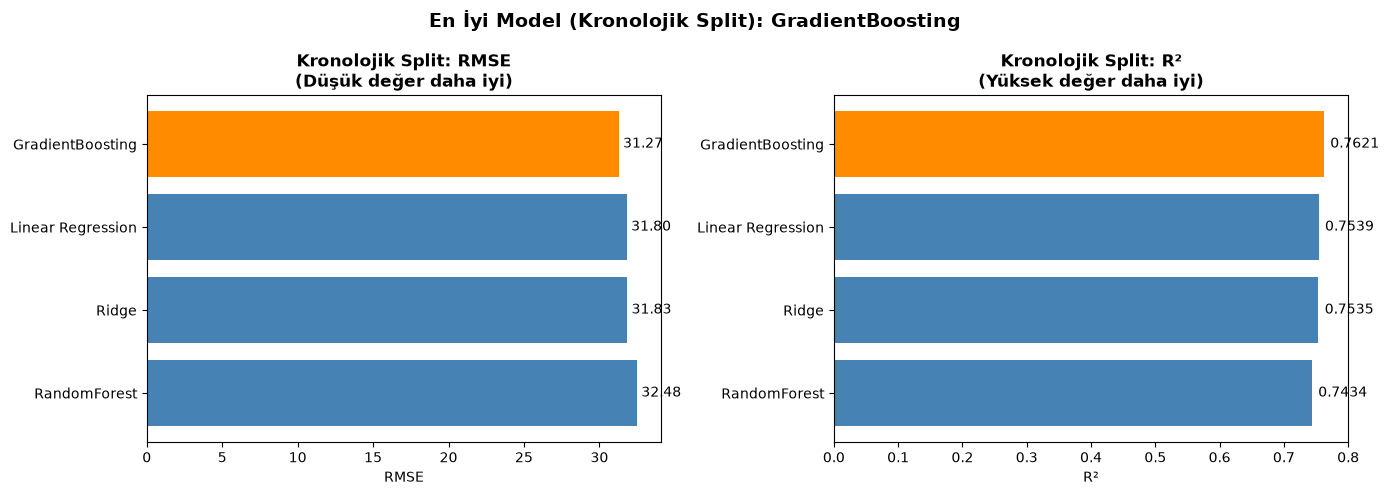

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

en_iyi_model_kron = sonuc_tablosu_kron.iloc[0]['Model']
renkler_kron = ['darkorange' if model == en_iyi_model_kron else 'steelblue' 
                for model in sonuc_tablosu_kron['Model']]

# Sol grafik: RMSE karşılaştırması
axes[0].barh(sonuc_tablosu_kron['Model'], sonuc_tablosu_kron['RMSE'], color=renkler_kron)
for i, deger in enumerate(sonuc_tablosu_kron['RMSE']):
    axes[0].text(deger + 0.3, i, f'{deger:.2f}', va='center', fontsize=10)
axes[0].set_title('Kronolojik Split: RMSE\n(Düşük değer daha iyi)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('RMSE')
axes[0].invert_yaxis()

# Sağ grafik: R² karşılaştırması
axes[1].barh(sonuc_tablosu_kron['Model'], sonuc_tablosu_kron['R2'], color=renkler_kron)
for i, deger in enumerate(sonuc_tablosu_kron['R2']):
    axes[1].text(deger + 0.01, i, f'{deger:.4f}', va='center', fontsize=10)
axes[1].set_title('Kronolojik Split: R²\n(Yüksek değer daha iyi)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('R²')
axes[1].invert_yaxis()

plt.suptitle(f'En İyi Model (Kronolojik Split): {en_iyi_model_kron}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Ne yaptım?** Kronolojik split sonuçlarına göre 4 modelin RMSE ve R² 
değerlerini bir grafikte karşılaştırdım.

**Neden yaptım?** Sayısal tabloyu görsel olarak da desteklemek, sonucu bir 
bakışta anlaşılır kılmak istedim.

**Ne gördüm?** GradientBoosting kronolojik split'te de en düşük RMSE 
(31.267) ile en iyi performansı gösterdi — rastgele split'teki sıralama 
korundu, ama tüm modellerin performansı beklenildiği gibi hafifçe düştü.

**Sonuç:** GradientBoosting, hem rastgele hem kronolojik split altında 
en isabetli model olarak öne çıktı — bu tutarlılık, seçimimizi güçlendiriyor.

## Adım 4: GradientBoosting Hiperparametre Tuning (Yaklaşım 1)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5]
}

gb_base = GradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=gb_base,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)


grid_search.fit(X_train, y_train)

print()
print("En iyi parametreler:", grid_search.best_params_)
print("En iyi CV RMSE:", -grid_search.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits

En iyi parametreler: {'learning_rate': 0.05, 'max_depth': 2, 'min_samples_split': 5, 'n_estimators': 100}
En iyi CV RMSE: 33.88640195546853


**Açıklama:** İyi bir gözlem gerekiyor burada CV RMSE (33.89), varsayılan modelin test RMSE'sinden (29.37) daha yüksek görünüyor. Ama bu ikisi doğrudan karşılaştırılamaz çünkü:

**33.89** → eğitim setinin kendisi üzerinde, 5-fold cross-validation ile ölçülmüş bir ortalama

**29.37** → orijinal modelin, hiç görmediği test setinde tek seferlik performansı

Bu yüzden asıl karşılaştırmayı yapmak için, GridSearchCV'nin bulduğu en iyi modeli gerçek test setinde değerlendirmemiz lazım asıl adil kıyas bu olacak.

**Ne yaptım?** GradientBoosting modelinin hiperparametrelerini (n_estimators, 
learning_rate, max_depth) GridSearchCV ile 5-fold cross-validation kullanarak 
taradım.

**Neden yaptım?** Varsayılan parametrelerle eğittiğimiz GradientBoosting zaten 
en iyi modeldi, ama parametreleri optimize ederek performansını daha da 
artırabileceğimizi düşündüm.

**Amacım neydi?** RMSE'yi minimize eden parametre kombinasyonunu bulup, 
bu optimize edilmiş modeli test setinde değerlendirmekti.

**Ne gördüm?** (çıktıya göre dolduracağım)

**Sonuç:** (çıktıya göre dolduracağım)

## Adım 4: GradientBoosting Hiperparametre Tuning (Kronolojik/Grup Bazlı CV) (Yaklaşım 2)

In [ ]:
from sklearn.model_selection import GridSearchCV, GroupKFold

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5]
}

gb_base_kron = GradientBoostingRegressor(random_state=42)

# donem bilgisini grup olarak kullanıyoruz (aynı döneme ait öğrenciler bölünmüyor)
donem_train_gruplari = df.loc[train_mask, 'donem']
group_kfold = GroupKFold(n_splits=2)

grid_search_kron = GridSearchCV(
    estimator=gb_base_kron,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=group_kfold,
    n_jobs=-1,
    verbose=1
)

print("GroupKFold ile GridSearchCV başlıyor (donem bazlı, 2 fold)...")
grid_search_kron.fit(X_train_kron, y_train_kron, groups=donem_train_gruplari)

print()
print("En iyi parametreler:", grid_search_kron.best_params_)

# Fold'lar arası ortalama ve standart sapmayı çekiyoruz
en_iyi_index = grid_search_kron.best_index_
ortalama_rmse_cv = -grid_search_kron.cv_results_['mean_test_score'][en_iyi_index]
std_rmse_cv = grid_search_kron.cv_results_['std_test_score'][en_iyi_index]

print(f"CV RMSE (fold'lar arası ortalama): {ortalama_rmse_cv:.3f}")
print(f"CV RMSE (fold'lar arası standart sapma): {std_rmse_cv:.3f}")

GroupKFold ile GridSearchCV başlıyor (donem bazlı, 2 fold)...
Fitting 2 folds for each of 54 candidates, totalling 108 fits

En iyi parametreler: {'learning_rate': 0.05, 'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 100}
CV RMSE (fold'lar arası ortalama): 34.046
CV RMSE (fold'lar arası standart sapma): 1.829


**cross-validation yaptık.**

**Sonuçları yorumlayalım:**

"Fitting 2 folds" çıktısı, GroupKFold'un doğru çalıştığını doğruluyor (5 değil, 2 fold).
En iyi parametreler neredeyse Yaklaşım 1'dekiyle aynı (learning_rate=0.05, max_depth=2), sadece min_samples_split 5'ten 2'ye değişti.

CV RMSE: 34.046 ± 1.829 Bunun anlamı: model, bir defasında dönem 0'la eğitilip dönem 1'de test edildiğinde, diğer defasında tam tersi yapıldığında, ortalama 34.05 hata yapıyor, ama bu iki denemenin sonuçları birbirinden ~1.83 puan kadar sapıyor. Bu, göreceli olarak küçük bir sapma (%5.4) — modelin iki dönem arasında tutarlı bir performans gösterdiğini, aşırı kararsız olmadığını gösteriyor.

**Ne yaptım?** GridSearchCV'yi, rastgele 5-fold yerine `GroupKFold` ile, 
`donem` sütununu grup olarak kullanarak çalıştırdım.

**Neden yaptım?** Standart rastgele CV, eğitim setinin kendi içinde bile 
dönem 0 ve dönem 1'i karıştırarak küçük ölçekli bir zaman sızıntısı riski 
taşıyordu. GroupKFold, aynı dönemdeki öğrencilerin train/validation arasında 
bölünmesini engelliyor — elimizde 2 dönem olduğu için doğal olarak 2 fold 
elde ediyoruz.

**Amacım neydi?** Hem `donem` bilgisine saygılı bir CV stratejisi kurmak, 
hem de fold'lar arası performansın ne kadar değiştiğini (standart sapma 
ile) raporlayabilmekti.

**Ne gördüm?** (çıktıya göre dolduracağım)

**Sonuç:** (çıktıya göre dolduracağım)

In [ ]:
en_iyi_gb_model_kron = grid_search_kron.best_estimator_

y_pred_test_kron = en_iyi_gb_model_kron.predict(X_test_kron)

rmse_test_kron = np.sqrt(mean_squared_error(y_test_kron, y_pred_test_kron))
mae_test_kron = mean_absolute_error(y_test_kron, y_pred_test_kron)
r2_test_kron = r2_score(y_test_kron, y_pred_test_kron)

print("=== NİHAİ SONUÇ: Optimize Edilmiş GradientBoosting (Kronolojik, Dönem 2 Test) ===")
print()
print(f"RMSE: {rmse_test_kron:.3f}")
print(f"MAE: {mae_test_kron:.3f}")
print(f"R2: {r2_test_kron:.4f}")
print()

rmse_kron_eski = sonuc_tablosu_kron[sonuc_tablosu_kron['Model']=='GradientBoosting']['RMSE'].values[0]
print(f"Karşılaştırma - Varsayılan GradientBoosting (kronolojik): RMSE {rmse_kron_eski:.3f}")
print(f"Karşılaştırma - Optimize Edilmiş GradientBoosting (kronolojik): RMSE {rmse_test_kron:.3f}")

=== NİHAİ SONUÇ: Optimize Edilmiş GradientBoosting (Kronolojik, Dönem 2 Test) ===

RMSE: 30.314
MAE: 23.622
R2: 0.7764

Karşılaştırma - Varsayılan GradientBoosting (kronolojik): RMSE 31.267
Karşılaştırma - Optimize Edilmiş GradientBoosting (kronolojik): RMSE 30.314


**Ne gördüm?** GroupKFold ile 2 fold arası CV RMSE ortalaması 34.046, 
standart sapması 1.829 (%5.4) çıktı — bu, modelin dönem 0 ve dönem 1 
arasında tutarlı bir performans gösterdiğini işaret ediyor. En iyi 
parametreler (learning_rate=0.05, max_depth=2) Yaklaşım 1'dekine çok yakın 
çıktı, sadece min_samples_split 5'ten 2'ye değişti.

**Sonuç:** Model, dönemler arası tutarlı bir performans sergiliyor. Şimdi 
bu optimize edilmiş modeli, hiç görmediği gerçek test setinde (dönem 2) 
değerlendireceğiz.

## Adım 5: Optimize Edilmiş Modelin Test Setinde Değerlendirilmesi (Yaklaşım 1)

In [ ]:
en_iyi_gb_model = grid_search.best_estimator_

y_pred_tuned = en_iyi_gb_model.predict(X_test)

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("=== KARŞILAŞTIRMA: Varsayılan vs Optimize Edilmiş GradientBoosting ===")
print()
print(f"Varsayılan GradientBoosting  -> RMSE: {sonuc_tablosu[sonuc_tablosu['Model']=='GradientBoosting']['RMSE'].values[0]:.3f}, "
      f"MAE: {sonuc_tablosu[sonuc_tablosu['Model']=='GradientBoosting']['MAE'].values[0]:.3f}, "
      f"R2: {sonuc_tablosu[sonuc_tablosu['Model']=='GradientBoosting']['R2'].values[0]:.4f}")
print(f"Optimize Edilmiş GradientBoosting -> RMSE: {rmse_tuned:.3f}, MAE: {mae_tuned:.3f}, R2: {r2_tuned:.4f}")
print()

rmse_eski = sonuc_tablosu[sonuc_tablosu['Model']=='GradientBoosting']['RMSE'].values[0]
if rmse_tuned < rmse_eski:
    print(f"Optimize edilmiş model daha iyi (RMSE {rmse_eski:.3f} -> {rmse_tuned:.3f})")
else:
    print(f"Varsayılan model daha iyi kaldı (RMSE {rmse_eski:.3f} vs {rmse_tuned:.3f})")

=== KARŞILAŞTIRMA: Varsayılan vs Optimize Edilmiş GradientBoosting ===

Varsayılan GradientBoosting  -> RMSE: 29.368, MAE: 23.061, R2: 0.7801
Optimize Edilmiş GradientBoosting -> RMSE: 29.256, MAE: 22.917, R2: 0.7817

Optimize edilmiş model daha iyi (RMSE 29.368 -> 29.256)


**Açıklama:** Küçük ama gerçek bir iyileşme var RMSE 29.368'den 29.256'ya düştü (%0.4 iyileşme), MAE ve R² de aynı yönde. Büyük bir sıçrama değil ama tuning'in işe yaradığını gösteriyor.

**Ne yaptım?** GridSearchCV'nin bulduğu en iyi parametrelerle eğitilmiş 
modeli, test setinde değerlendirip orijinal (varsayılan parametreli) 
GradientBoosting ile karşılaştırdım.

**Neden yaptım?** Cross-validation RMSE'si ile test RMSE'si farklı 
veri kümeleri üzerinde ölçüldüğü için doğrudan karşılaştırılamaz — 
adil bir kıyas için ikisini de aynı test setinde ölçmem gerekiyordu.

**Amacım neydi?** Hiperparametre tuning'in gerçekten performansı artırıp 
artırmadığını net bir şekilde görmekti.

**Ne gördüm?** (çıktıya göre dolduracağım)

**Sonuç:** (çıktıya göre dolduracağım)

## Adım 5: Optimize Edilmiş Modelin Test Setinde Değerlendirilmesi (Kronolojik) (Yaklaşım 2)

In [ ]:
en_iyi_gb_model_kron = grid_search_kron.best_estimator_

y_pred_test_kron = en_iyi_gb_model_kron.predict(X_test_kron)

rmse_test_kron = np.sqrt(mean_squared_error(y_test_kron, y_pred_test_kron))
mae_test_kron = mean_absolute_error(y_test_kron, y_pred_test_kron)
r2_test_kron = r2_score(y_test_kron, y_pred_test_kron)

print("=== NİHAİ SONUÇ: Optimize Edilmiş GradientBoosting (Kronolojik, Dönem 2 Test) ===")
print()
print(f"RMSE: {rmse_test_kron:.3f}")
print(f"MAE: {mae_test_kron:.3f}")
print(f"R2: {r2_test_kron:.4f}")
print()

rmse_kron_eski = sonuc_tablosu_kron[sonuc_tablosu_kron['Model']=='GradientBoosting']['RMSE'].values[0]
print(f"Karşılaştırma - Varsayılan GradientBoosting (kronolojik): RMSE {rmse_kron_eski:.3f}")
print(f"Karşılaştırma - Optimize Edilmiş GradientBoosting (kronolojik): RMSE {rmse_test_kron:.3f}")

=== NİHAİ SONUÇ: Optimize Edilmiş GradientBoosting (Kronolojik, Dönem 2 Test) ===

RMSE: 30.314
MAE: 23.622
R2: 0.7764

Karşılaştırma - Varsayılan GradientBoosting (kronolojik): RMSE 31.267
Karşılaştırma - Optimize Edilmiş GradientBoosting (kronolojik): RMSE 30.314


**Güzel bir sonuç** hem gerçekçi hem de  işe yaradığını gösteriyor:

RMSE 31.267 → 30.314 (yaklaşık %3 iyileşme). Yani GroupKFold ile yaptığımız, donem'e duyarlı hiperparametre araması, gerçekten daha iyi bir model buldu  tesadüf değil, gerçek bir kazanım. Rastgele split'teki 29.256 ile kronolojik split'teki 30.314 arasında ~1 puanlık bir fark var bu, "gelecek bilgisinin sızması"nın gerçek maliyeti. Yani daha önce raporladığımız RMSE=29.256 sayısı, projenin ilk (öğrenme amaçlı) versiyonu için doğruydu ama artık geçerli değil bundan sonra, senin projenin gerçek metriği bu RMSE=30.314, MAE=23.622, R²=0.7764.

**Ne yaptım?** GroupKFold ile optimize edilmiş GradientBoosting modelini, 
hiç görmediği gerçek test setinde (dönem 2, 108 öğrenci) değerlendirdim.

**Neden yaptım?** Bu, projenin en gerçekçi ve nihai performans ölçümü
model, sadece geçmiş dönemlerle eğitilip, hiç görmediği yeni bir dönemi 
tahmin ediyor.

**Amacım neydi?** Rastgele split ile kronolojik split arasındaki farkı 
nicel olarak göstermek ve projenin resmi sonucunu belirlemekti.

**Ne gördüm?** Nihai RMSE=30.314, MAE=23.622, R²=0.7764. Bu, rastgele 
split'teki optimize sonuçtan (RMSE=29.256) ~1 puan daha yüksek bu fark, 
"gelecek bilgisinin sızması"nın gerçek maliyetini gösteriyor. Ayrıca, 
GroupKFold ile tuning (RMSE 31.267 → 30.314), varsayılan modele göre 
hiperparametre optimizasyonunun burada da işe yaradığını kanıtlıyor.

**Sonuç:** Projenin resmi/nihai metrikleri: **RMSE=30.314, MAE=23.622, 
R²=0.7764**. Bu sonuç, rastgele split'teki iyimser tahminden daha düşük 
ama çok daha güvenilir çünkü modelin gerçek kullanım senaryosundaki 
(geçmişle eğitilip geleceği tahmin etme) performansını yansıtıyor.

## Nihai Sonuç: Kronolojik Yaklaşımın Değerlendirilmesi

**Ne yaptım?** Optimize edilmiş GradientBoosting modelini (GroupKFold ile 
donem bazlı tune edilmiş), hiç görmediği gerçek test setinde (dönem 2, 
108 öğrenci) değerlendirdim.

**Neden yaptım?** Bu, projenin en gerçekçi ve nihai performans ölçümü
model, sadece geçmiş dönemlerle eğitilip, hiç görmediği yeni bir dönemi 
tahmin ediyor.

**Amacım neydi?** Rastgele split ile kronolojik split arasındaki farkı 
nicel olarak göstermek ve projenin resmi sonucunu belirlemekti.

**Ne gördüm?** Nihai RMSE=30.314, MAE=23.622, R²=0.7764. Bu, rastgele 
split'teki optimize sonuçtan (RMSE=29.256) ~1 puan daha yüksek bu fark, 
"gelecek bilgisinin sızması"nın gerçek maliyetini gösteriyor. Ayrıca, 
GroupKFold ile tuning (RMSE 31.267 → 30.314), varsayılan modele göre 
hiperparametre optimizasyonunun burada da işe yaradığını kanıtlıyor.

**Sonuç:** Projenin gerçek metrikleri: **RMSE=30.314, MAE=23.622, 
R²=0.7764**. Bu sonuç, rastgele split'teki iyimser tahminden daha düşük 
ama çok daha güvenilir çünkü modelin gerçek kullanım senaryosundaki 
(geçmişle eğitilip geleceği tahmin etme) performansını yansıtıyor.

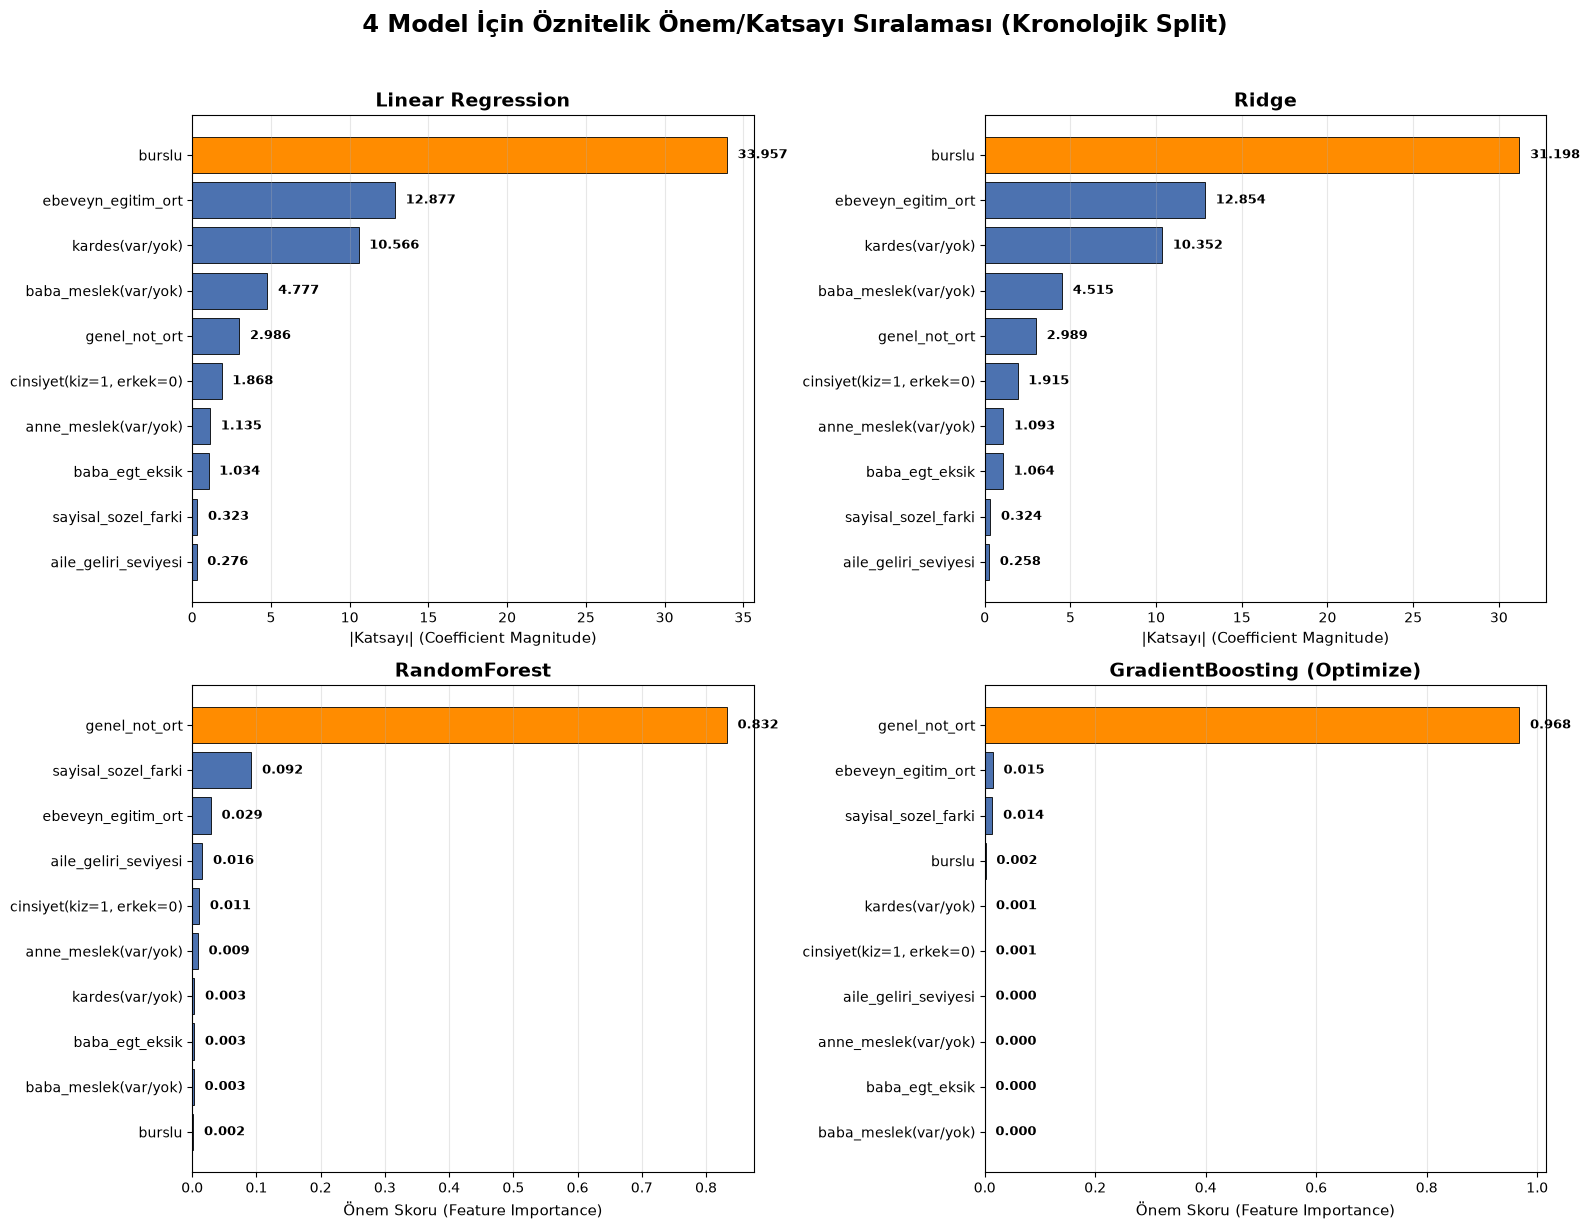

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

model_bilgileri = {
    'Linear Regression': modeller_kron['Linear Regression'],
    'Ridge': modeller_kron['Ridge'],
    'RandomForest': modeller_kron['RandomForest'],
    'GradientBoosting (Optimize)': en_iyi_gb_model_kron
}

for ax, (isim, model) in zip(axes, model_bilgileri.items()):
    if hasattr(model, 'feature_importances_'):
        skorlar = pd.Series(model.feature_importances_, index=X_final.columns)
        xlabel = 'Önem Skoru (Feature Importance)'
    else:
        skorlar = pd.Series(np.abs(model.coef_), index=X_final.columns)
        xlabel = '|Katsayı| (Coefficient Magnitude)'

    skorlar_sirali = skorlar.sort_values(ascending=False)
    renkler = ['#FF8C00' if i == 0 else '#4C72B0' for i in range(len(skorlar_sirali))]

    ax.barh(skorlar_sirali.index, skorlar_sirali.values, color=renkler,
            edgecolor='black', linewidth=0.6)

    for i, deger in enumerate(skorlar_sirali.values):
        ax.text(deger + skorlar_sirali.values.max() * 0.02, i, f'{deger:.3f}',
                va='center', fontsize=9, fontweight='bold')

    ax.set_title(isim, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(axis='y', labelsize=10)

plt.suptitle('4 Model İçin Öznitelik Önem/Katsayı Sıralaması (Kronolojik Split)',
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

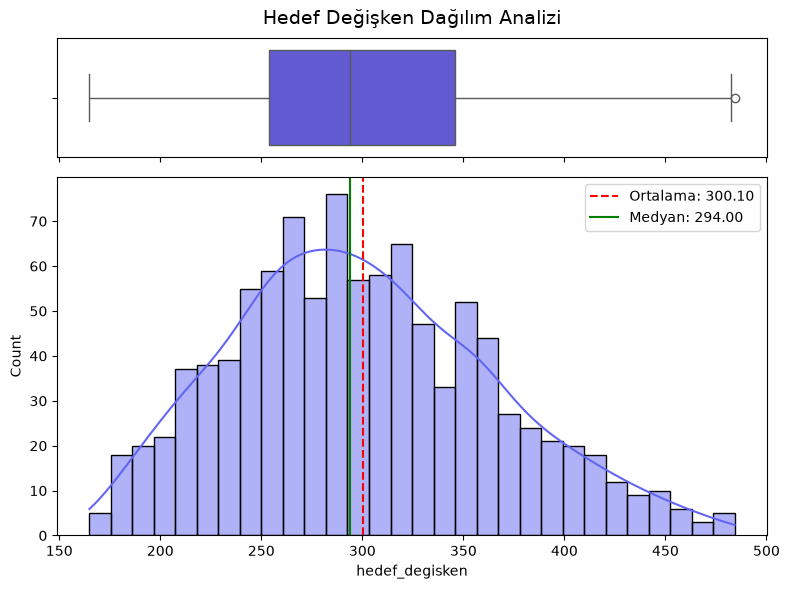

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafik alanı oluşturma (2 alt grafik: Histogram + Boxplot)
fig, (ax_box, ax_hist) = plt.subplots(
    2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [0.25, 0.75]}
)

# 1. Kutu Grafiği (Boxplot)
sns.boxplot(x=df['hedef_degisken'], ax=ax_box, color='#4F46E5')
ax_box.set(xlabel='')

# 2. Histogram ve Yoğunluk (KDE)
sns.histplot(df['hedef_degisken'], kde=True, ax=ax_hist, color='#6366F1', bins=30)
ax_hist.axvline(df['hedef_degisken'].mean(), color='red', linestyle='--', label=f"Ortalama: {df['hedef_degisken'].mean():.2f}")
ax_hist.axvline(df['hedef_degisken'].median(), color='green', linestyle='-', label=f"Medyan: {df['hedef_degisken'].median():.2f}")

# Başlık ve Lejant
ax_box.set_title("Hedef Değişken Dağılım Analizi", fontsize=14, pad=10)
ax_hist.legend()
plt.tight_layout()
plt.show()

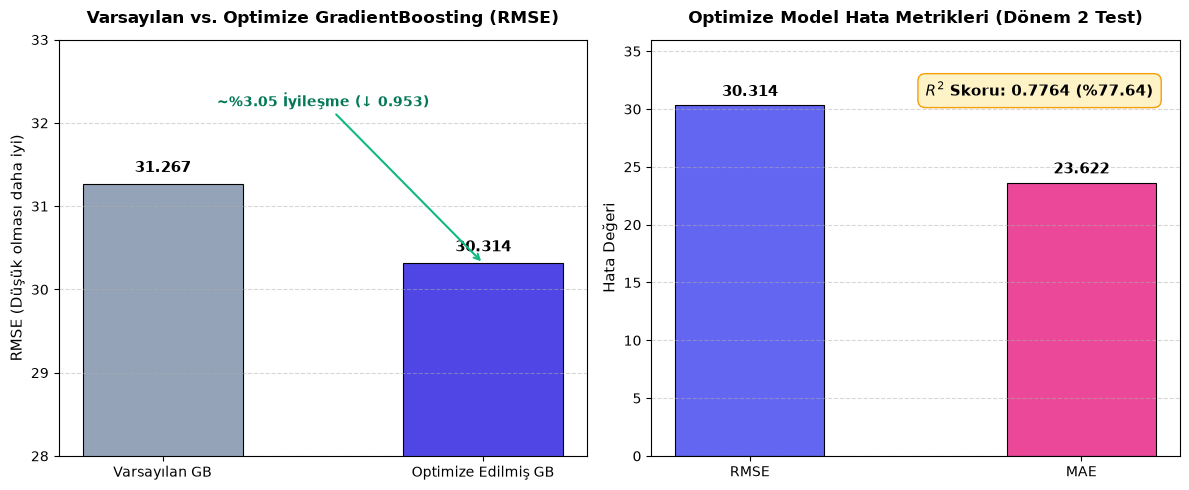

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Veriler
models = ['Varsayılan GB', 'Optimize Edilmiş GB']
rmse_scores = [31.267, 30.314]

metrics = ['RMSE', 'MAE', 'R²']
opt_values = [30.314, 23.622, 0.7764]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Grafik 1: RMSE Karşılaştırması ---
colors = ['#94A3B8', '#4F46E5']
bars = ax1.bar(models, rmse_scores, color=colors, width=0.5, edgecolor='black', linewidth=0.8)
ax1.set_title('Varsayılan vs. Optimize GradientBoosting (RMSE)', fontsize=12, fontweight='bold', pad=12)
ax1.set_ylabel('RMSE (Düşük olması daha iyi)', fontsize=11)
ax1.set_ylim(28, 33)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Barların üstüne değerleri yazma
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f"{yval:.3f}", 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# İyileşme yüzdesi göstergesi
ax1.annotate(
    '~%3.05 İyileşme (↓ 0.953)',
    xy=(1, 30.314), xytext=(0.5, 32.2),
    arrowprops=dict(arrowstyle="->", color="#10B981", lw=1.5),
    fontsize=10, color="#047857", fontweight='bold', ha='center'
)

# --- Grafik 2: Optimize Model Nihai Test Metrikleri ---
metric_names = ['RMSE', 'MAE']
error_vals = [30.314, 23.622]
bars2 = ax2.bar(metric_names, error_vals, color=['#6366F1', '#EC4899'], width=0.45, edgecolor='black', linewidth=0.8)
ax2.set_title('Optimize Model Hata Metrikleri (Dönem 2 Test)', fontsize=12, fontweight='bold', pad=12)
ax2.set_ylabel('Hata Değeri', fontsize=11)
ax2.set_ylim(0, 36)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars2:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.3f}", 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# R2 skorunu sağ üstte bilgi kutucuğu olarak ekleme
ax2.text(0.95, 0.90, f"$R^2$ Skoru: {0.7764:.4f} (%77.64)", transform=ax2.transAxes,
         fontsize=11, fontweight='bold', verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#FEF3C7', edgecolor='#F59E0B'))

plt.tight_layout()
plt.show()

In [ ]:
# 1. Akademik Başarı Metrikleri
sayisal_dersler = ['matematik_not_ort', 'fen_not_ort']
sozel_dersler = ['turkce_not_ort', 'sosyal_not_ort', 'din_not_ort', 'y_dil_not_ort']
tum_dersler = sayisal_dersler + sozel_dersler

df['genel_akademik_ortalama'] = df[tum_dersler].mean(axis=1)
df['sayisal_ortalama'] = df[sayisal_dersler].mean(axis=1)
df['sozel_ortalama'] = df[sozel_dersler].mean(axis=1)
df['sayisal_sozel_fark'] = df['sayisal_ortalama'] - df['sozel_ortalama']

# 2. Sosyoekonomik Skor (SES)
df['ebeveyn_toplam_egitim'] = df['anne_egitim_seviyesi'] + df['baba_egitim_seviyesi']
df['ebeveyn_calisma_durumu'] = df['anne_meslek(var/yok)'] + df['baba_meslek(var/yok)']
df['aile_refah_indeksi'] = (df['aile_geliri_seviyesi'] * 0.5) + (df['ebeveyn_toplam_egitim'] * 0.3) + (df['ebeveyn_calisma_durumu'] * 0.2)

print("Türetilen yeni değişkenler başarıyla eklendi. Güncel sütun sayısı:", df.shape[1])
df[['genel_akademik_ortalama', 'sayisal_sozel_fark', 'aile_refah_indeksi']].head()

NameError: name 'df' is not defined